In [1]:
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
from utils import * #only needed for xgboost
import itertools
import matplotlib.pyplot as plt

In [2]:
train_size = 0.99
train_seed = 2
test_size = 0.93
target_column = 'Volume'
use_latvia = True

In [3]:
predictor_columns = ['zmax', 'zmean', 'zsd',
    'zskew', 'zkurt', 'zentropy', 'pzabovezmean', 'pzabove2', 'zq5', 'zq10',
    'zq15', 'zq20', 'zq25', 'zq30', 'zq35', 'zq40', 'zq45', 'zq50', 'zq55',
    'zq60', 'zq65', 'zq70', 'zq75', 'zq80', 'zq85', 'zq90', 'zq95',
    'zpcum1', 'zpcum2', 'zpcum3', 'zpcum4', 'zpcum5', 'zpcum6', 'zpcum7',
    'zpcum8', 'zpcum9', 'itot', 'imax', 'imean', 'isd', 'iskew', 'ikurt',
    'ipground', 'ipcumzq10', 'ipcumzq30', 'ipcumzq50', 'ipcumzq70',
    'ipcumzq90', 'p1th', 'p2th', 'p3th', 'p4th', 'p5th',
    'l_1', 'l_2', 't_3', 't_4',
    ]

#random_size = np.random.randint(57, 59)
#predictor_columns = np.random.choice(predictor_columns, size = random_size)
predictor_columns

['zmax',
 'zmean',
 'zsd',
 'zskew',
 'zkurt',
 'zentropy',
 'pzabovezmean',
 'pzabove2',
 'zq5',
 'zq10',
 'zq15',
 'zq20',
 'zq25',
 'zq30',
 'zq35',
 'zq40',
 'zq45',
 'zq50',
 'zq55',
 'zq60',
 'zq65',
 'zq70',
 'zq75',
 'zq80',
 'zq85',
 'zq90',
 'zq95',
 'zpcum1',
 'zpcum2',
 'zpcum3',
 'zpcum4',
 'zpcum5',
 'zpcum6',
 'zpcum7',
 'zpcum8',
 'zpcum9',
 'itot',
 'imax',
 'imean',
 'isd',
 'iskew',
 'ikurt',
 'ipground',
 'ipcumzq10',
 'ipcumzq30',
 'ipcumzq50',
 'ipcumzq70',
 'ipcumzq90',
 'p1th',
 'p2th',
 'p3th',
 'p4th',
 'p5th',
 'l_1',
 'l_2',
 't_3',
 't_4']

In [4]:
#data from Svedala
data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',
                            index_col=[0])

#rename 'Hgv' to 'H_AVERAGE'
#data_sweden = data_sweden.rename(columns={RESPONSE: "D_AVERAGE"})

#for training and testing on Sweden only
data_train_sweden_1 = data_sweden[data_sweden['area_code'] == 4]
data_train_sweden_2 = data_sweden[data_sweden['area_code'] == 2]
data_train_sweden_3 = data_sweden[data_sweden['area_code'] == 3]
data_train_sweden_4 = data_sweden[data_sweden['area_code'] == 1]

#data_train_sweden_234 = data_train_sweden_4
data_train_sweden_234 = pd.concat(
    [data_train_sweden_2, data_train_sweden_3])
data_train_sweden_234 = pd.concat(
    [data_train_sweden_234, data_train_sweden_4])
data_train_sweden, data_test_sweden_1 = train_test_split(
    data_train_sweden_1, test_size=test_size,
    random_state=10)  #random_state is fixed

data_train_sweden_1, data_test = train_test_split(
    data_train_sweden,
    test_size=1 - train_size,
    random_state=train_seed
)



if use_latvia == True:

    #evaluate and rain on latvia instead (keep naming for simplicity)
    data_latvia = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Latvian_Image_data\merged_data_cleaned.csv')
    data_latvia = data_latvia.rename(columns = {'H_AVERAGE': 'Hgv', 'D_AVERAGE': 'Dgv', 'VOLUME': 'Volume'})
    data_train_sweden, data_test_sweden_1 = train_test_split(
        data_latvia, test_size=test_size,
        random_state=10)  #random_state is fixed

    data_train_sweden_1, data_test = train_test_split(
        data_train_sweden,
        test_size=1 - train_size,
        random_state=train_seed
    )  #random state is not fixed, data_test unused

#"General" base dataset (to use for transfer)
ahat_train = np.array(data_train_sweden_234[predictor_columns])
bhat_train = np.array(data_train_sweden_234[target_column])

#Specific train and test set
a_train = np.array(data_train_sweden_1[predictor_columns])
b_train = np.array(data_train_sweden_1[target_column])

x_test = np.array(data_test_sweden_1[predictor_columns])
y_test = np.array(data_test_sweden_1[target_column])

x_val, x_test = train_test_split(x_test, test_size = 0.5, random_state = 1)
y_val, y_test = train_test_split(y_test, test_size = 0.5, random_state = 1)

print(len(a_train), len(x_val), len(x_test))

131 890 890


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\2033596860.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


In [5]:
def train_xgboost(data_train, labels_train, data_val, labels_val, boosting_rounds, params):
    dtrain = xgb.DMatrix(data_train, label=labels_train)
    dval = xgb.DMatrix(data_val, label=labels_val)

    evallist = [(dtrain, 'train'), (dval, 'eval')]
    evals_result = {}

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=boosting_rounds,
        evals=evallist,
        early_stopping_rounds=5,
        evals_result=evals_result,
        verbose_eval=False  # You can still turn this on if you want
    )

    # Plot training and validation metrics
    metric_name = list(evals_result['train'].keys())[0]  # e.g., 'logloss' or 'error'
    train_metric = evals_result['train'][metric_name]
    val_metric = evals_result['eval'][metric_name]

    plt.figure(figsize=(10, 6))
    plt.plot(train_metric, label='Train')
    plt.plot(val_metric, label='Validation')
    plt.xlabel('Boosting Round')
    plt.ylabel(metric_name.capitalize())
    plt.title(f'XGBoost {metric_name.capitalize()} Over Boosting Rounds')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return bst


def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\2047101444.py:30: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


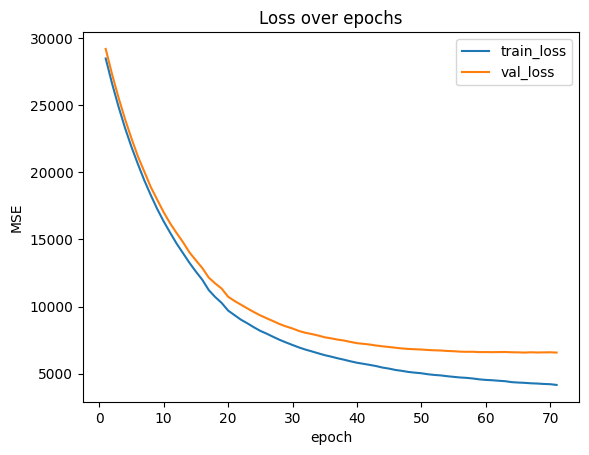

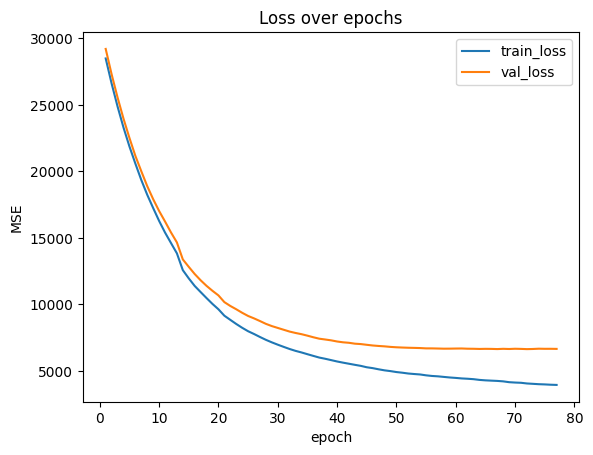

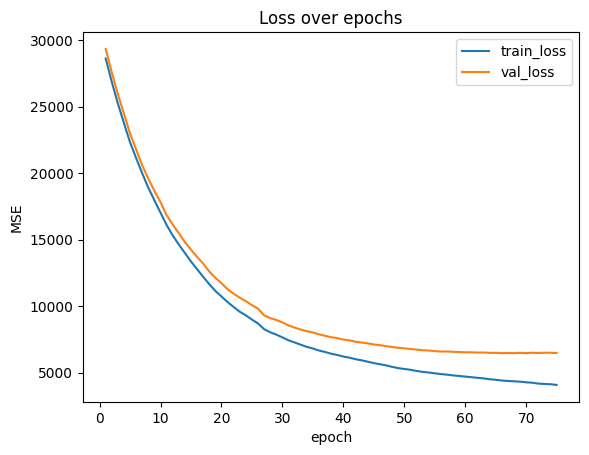

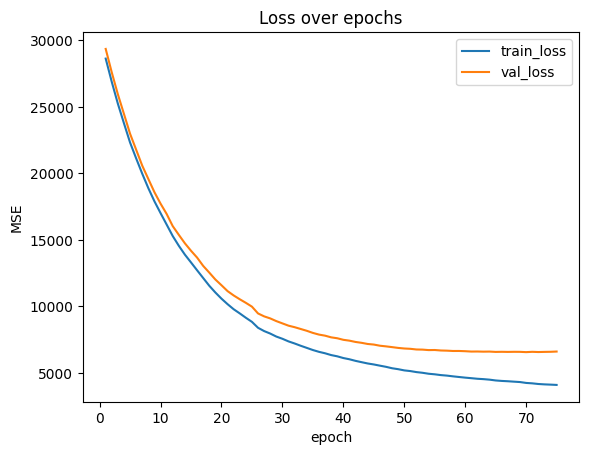

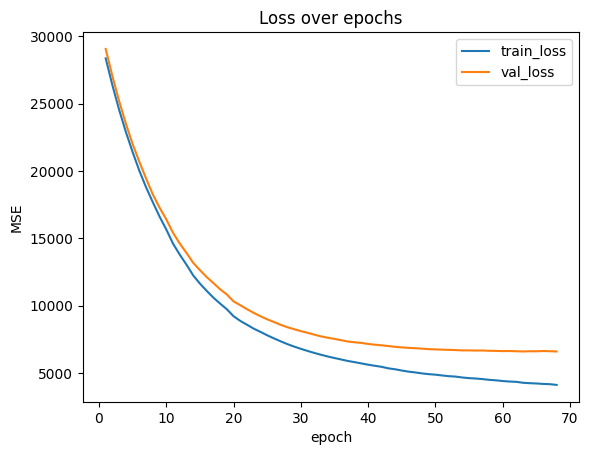

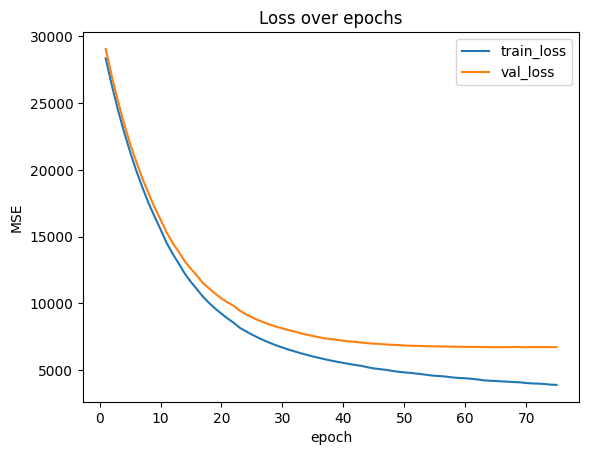

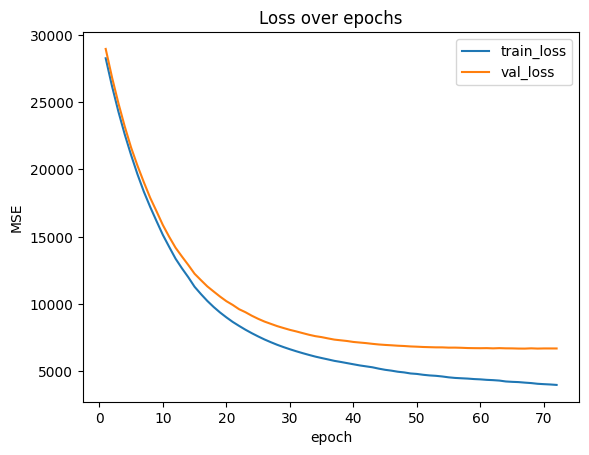

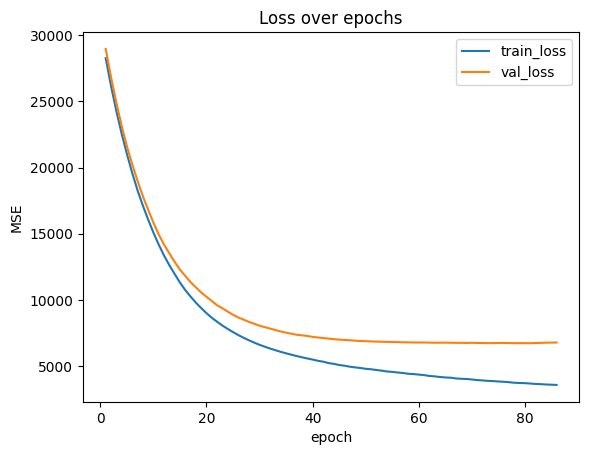

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\2047101444.py:30: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


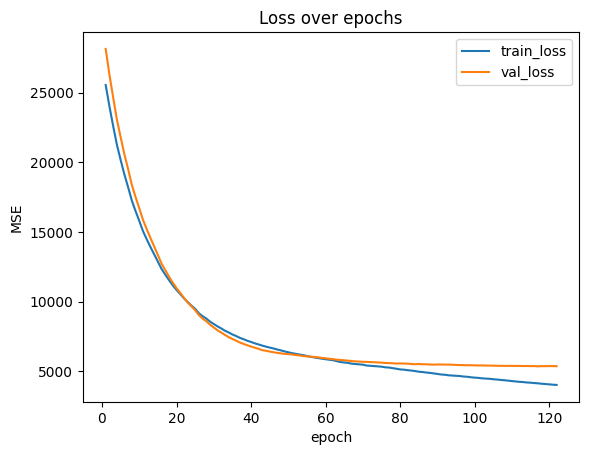

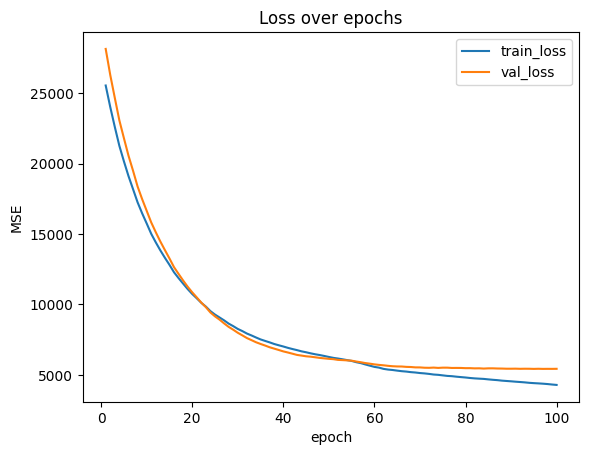

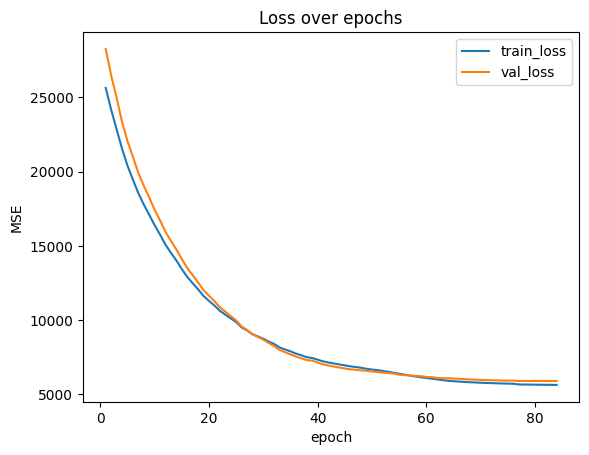

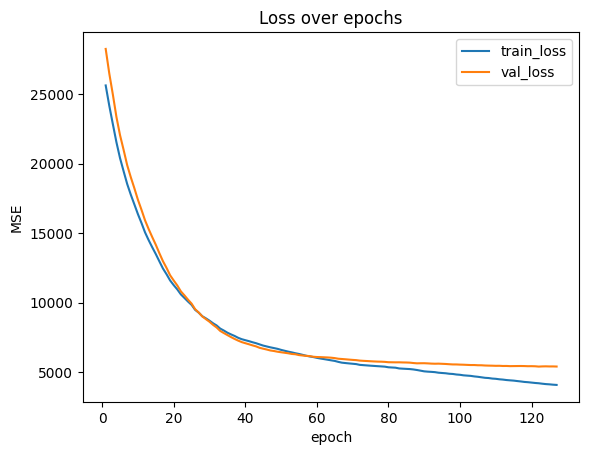

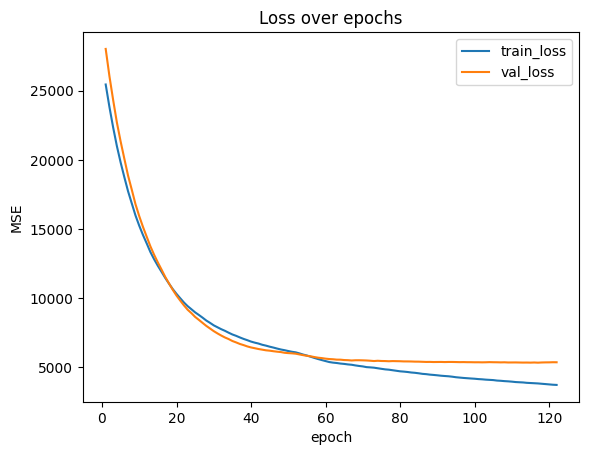

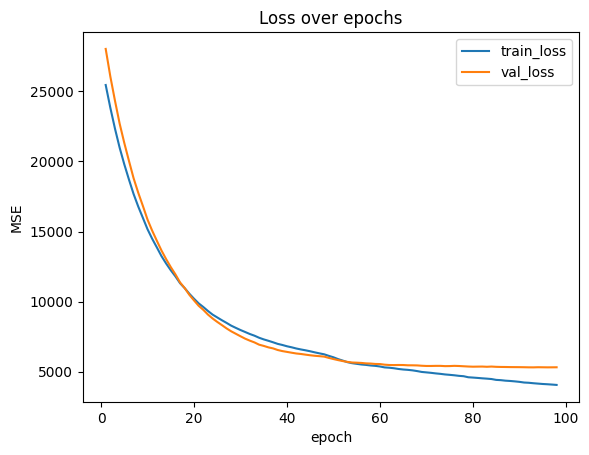

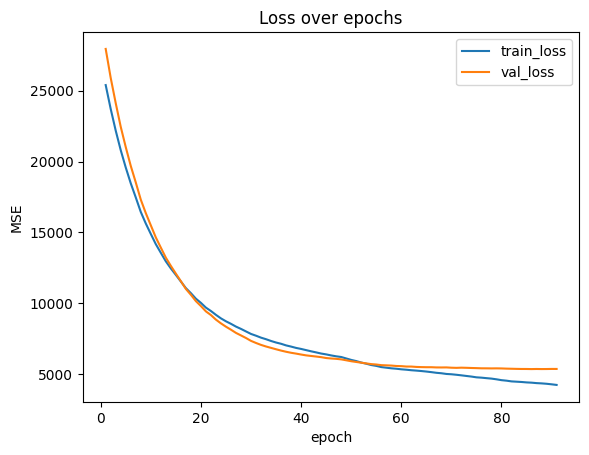

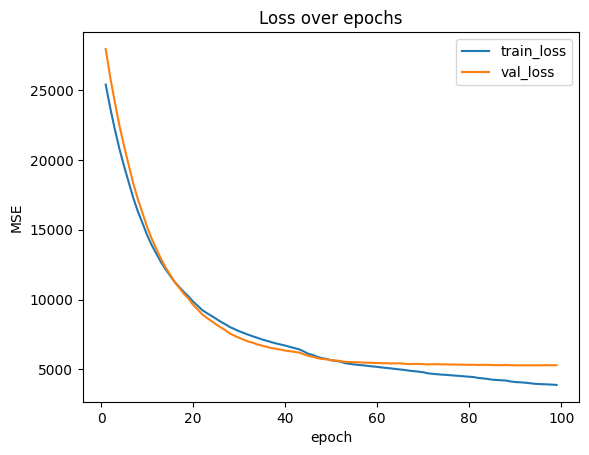

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\2047101444.py:30: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


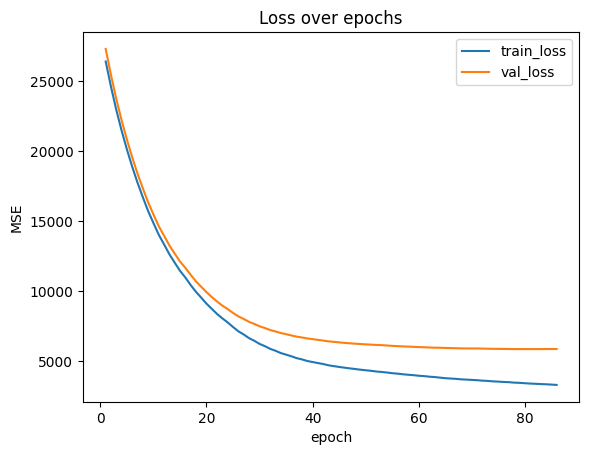

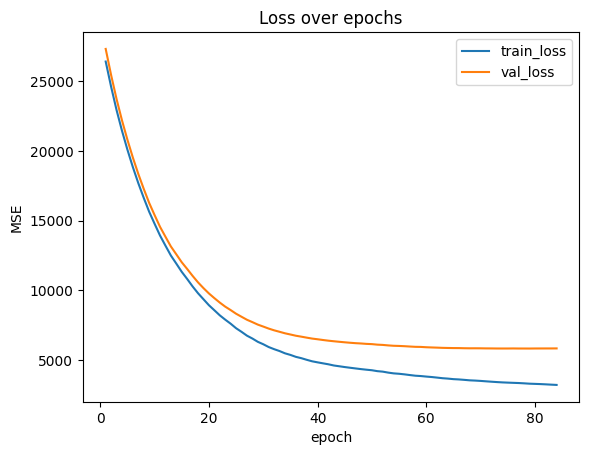

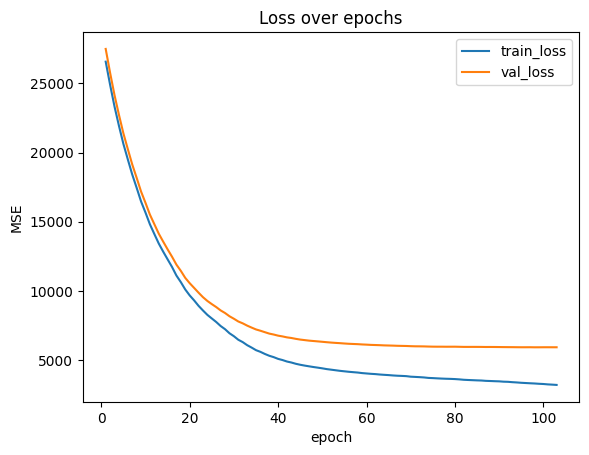

KeyboardInterrupt: 

In [8]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_real = pd.DataFrame(columns = ['seed', 'rmse',
                                   'mae', 'source_tree_size', 'target_tree_size', 'v', 'alpha', 'linear_decay', 'epochs', 'method'])

disturbance_level=1
seed_list = [1,2,3,4,5]
epoch_list = [1000]
v_list = [0.05]
source_tree_size_list = [2]
target_tree_size_list = [2]
alpha_list = [0.5, 0.2, 0.8, 1.0]
linear_decay_list = [True, False]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    epoch_list,
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    alpha_list,
    linear_decay_list
))

# --- Step 3: Sample random combinations ---
#sampled_configs = random.sample(param_grid, n_samples)

for seed in seed_list:

    #data from Svedala
    data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',
                                index_col=[0])

    #rename 'Hgv' to 'H_AVERAGE'
    #data_sweden = data_sweden.rename(columns={RESPONSE: "D_AVERAGE"})

    #for training and testing on Sweden only
    data_train_sweden_1 = data_sweden[data_sweden['area_code'] == 4]
    data_train_sweden_2 = data_sweden[data_sweden['area_code'] == 2]
    data_train_sweden_3 = data_sweden[data_sweden['area_code'] == 3]
    data_train_sweden_4 = data_sweden[data_sweden['area_code'] == 1]

    #data_train_sweden_234 = data_train_sweden_4
    data_train_sweden_234 = pd.concat(
        [data_train_sweden_2, data_train_sweden_3])
    data_train_sweden_234 = pd.concat(
        [data_train_sweden_234, data_train_sweden_4])
    data_train_sweden, data_test_sweden_1 = train_test_split(
        data_train_sweden_1, test_size=test_size,
        random_state=seed)  #random_state is fixed

    data_train_sweden_1, data_test = train_test_split(
        data_train_sweden,
        test_size=1 - train_size,
        random_state=seed
    )



    if use_latvia == True:

        #evaluate and rain on latvia instead (keep naming for simplicity)
        data_latvia = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Latvian_Image_data\merged_data_cleaned.csv')
        data_latvia = data_latvia.rename(columns = {'H_AVERAGE': 'Hgv', 'D_AVERAGE': 'Dgv', 'VOLUME': 'Volume'})
        data_train_sweden, data_test_sweden_1 = train_test_split(
            data_latvia, test_size=test_size,
            random_state=seed)  #random_state is fixed

        data_train_sweden_1, data_test = train_test_split(
            data_train_sweden,
            test_size=1 - train_size,
            random_state=seed
        )  #random state is not fixed, data_test unused

    #"General" base dataset (to use for transfer)
    X_source_train = np.array(data_train_sweden_234[predictor_columns])
    y_source_train = np.array(data_train_sweden_234[target_column])

    #Specific train and test set
    X_target_train = np.array(data_train_sweden_1[predictor_columns])
    y_target_train = np.array(data_train_sweden_1[target_column])

    X_target_test = np.array(data_test_sweden_1[predictor_columns])
    y_target_test = np.array(data_test_sweden_1[target_column])

    X_target_val, X_target_test = train_test_split(X_target_test, test_size = 0.5, random_state = seed)
    y_target_val, y_target_test = train_test_split(y_target_test, test_size = 0.5, random_state = seed)
    print(len(X_target_train), len(X_target_val), len(X_target_test))
    for config in param_grid:
        epochs, v, source_tree_size, target_tree_size, alpha, linear_decay = config


        #Test for all methods!!!!

        method = f'LSTransferTreeBoost'
        fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=source_tree_size, 
                                    target_tree_size=target_tree_size, alpha=alpha, linear_decay=linear_decay)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = True)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

        ablation_transfer_real.loc[len(ablation_transfer_real)] = [seed, rmse,
                mae, source_tree_size, target_tree_size, v, alpha, linear_decay, epochs, method]
        ablation_transfer_real.to_csv(f'ablation_transfer_real.csv')


      
                        
    



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\1052736820.py:22: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


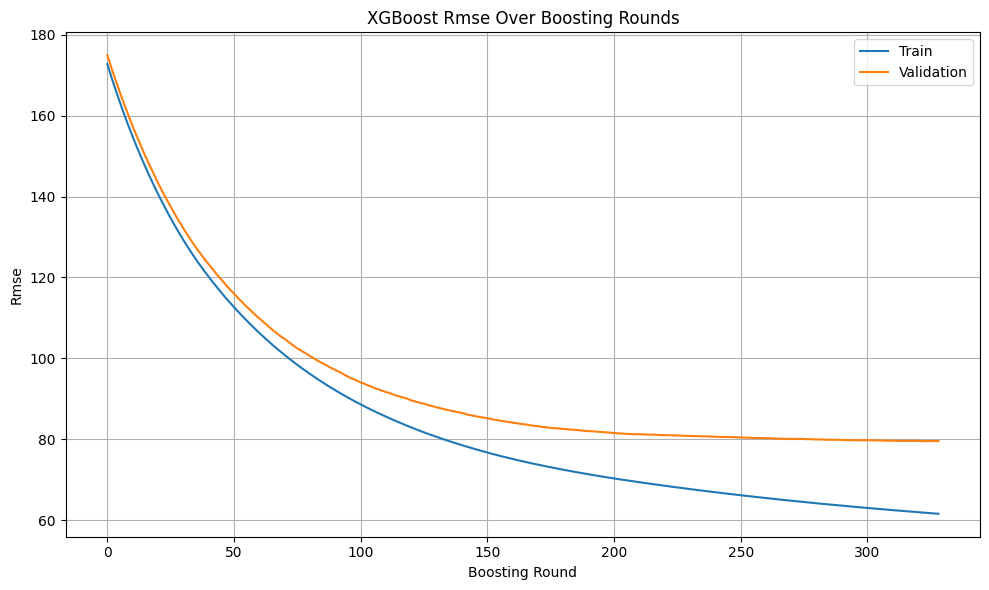

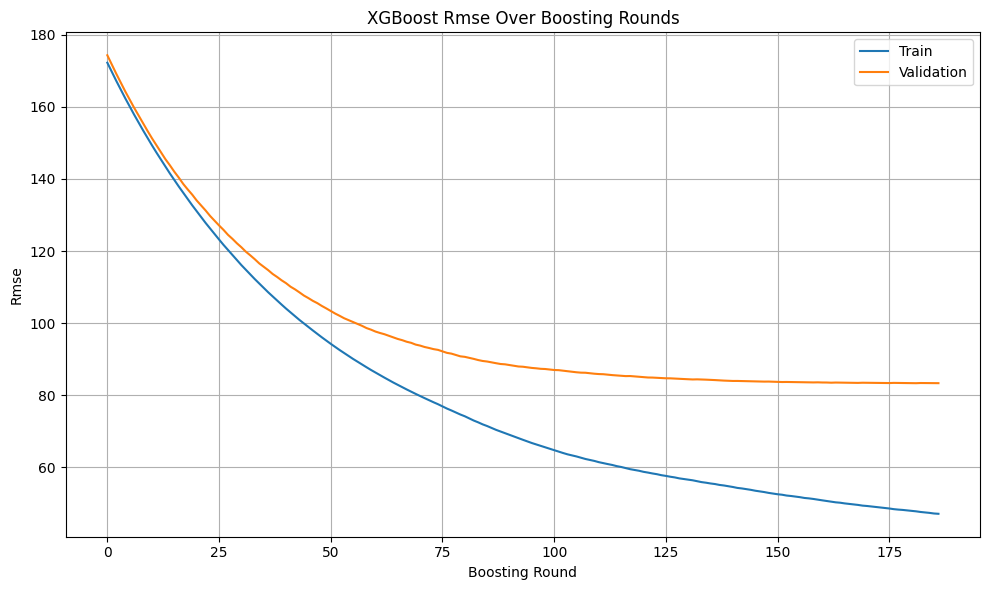

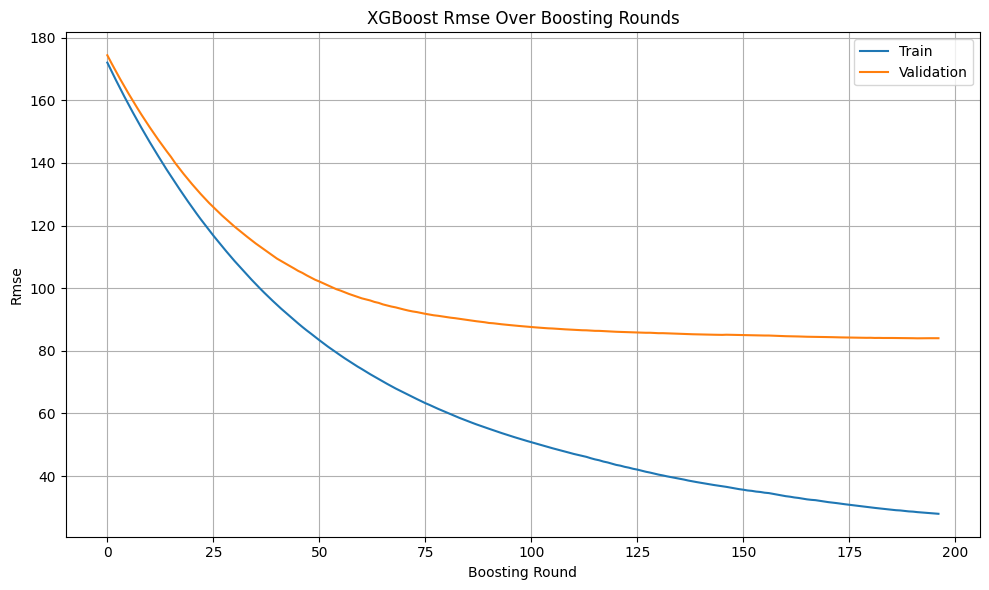

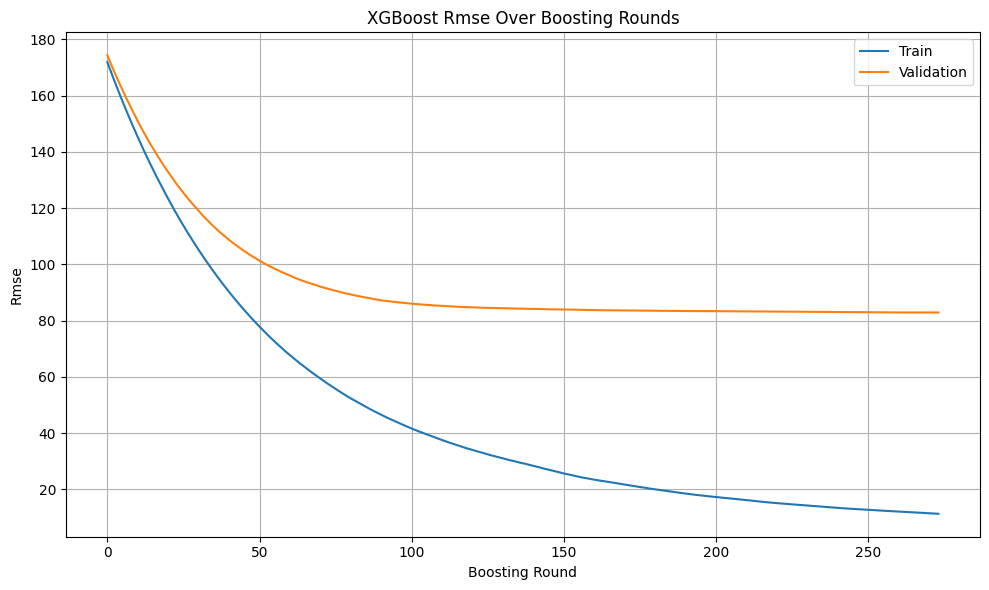

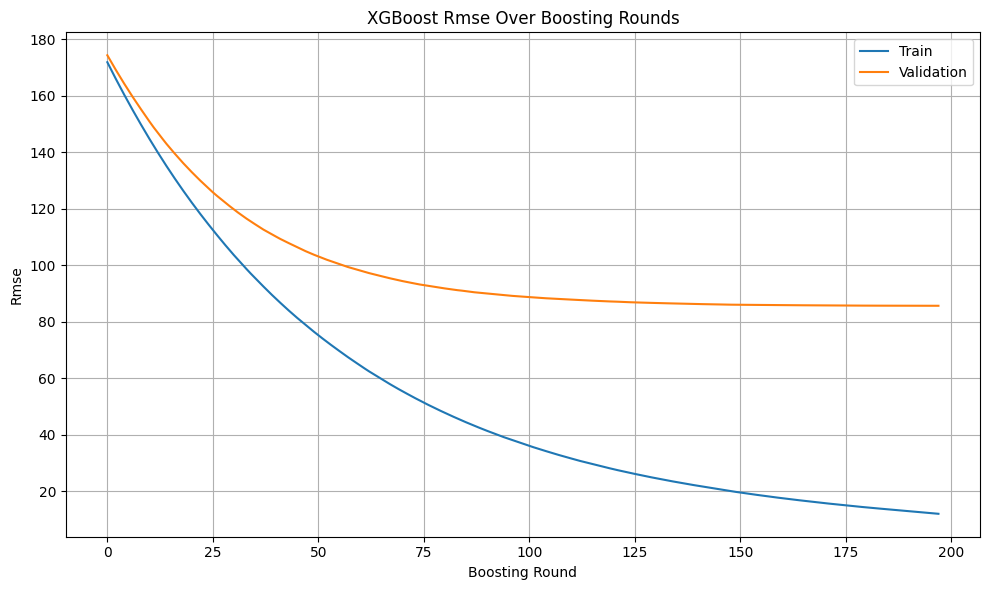

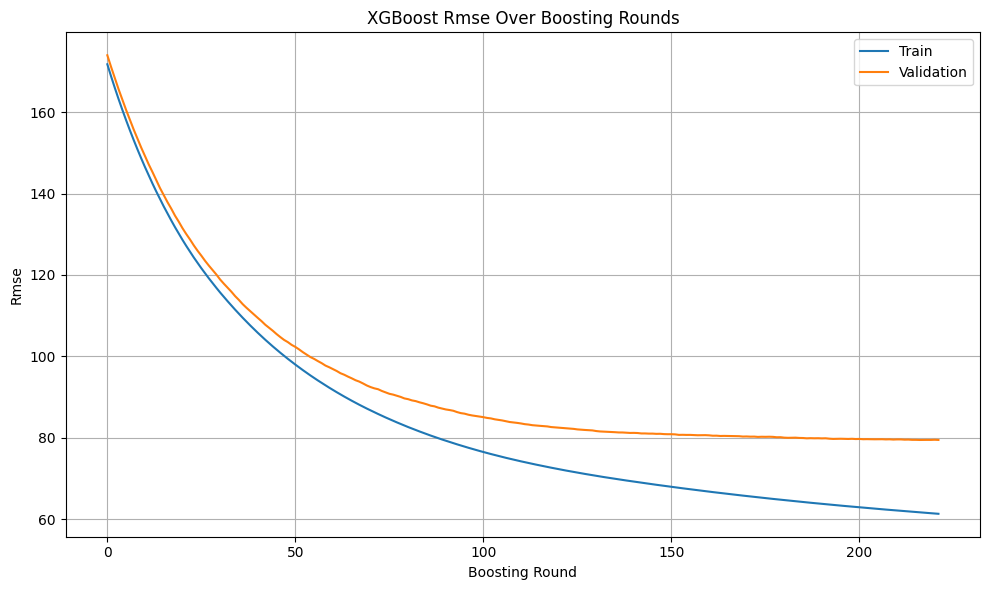

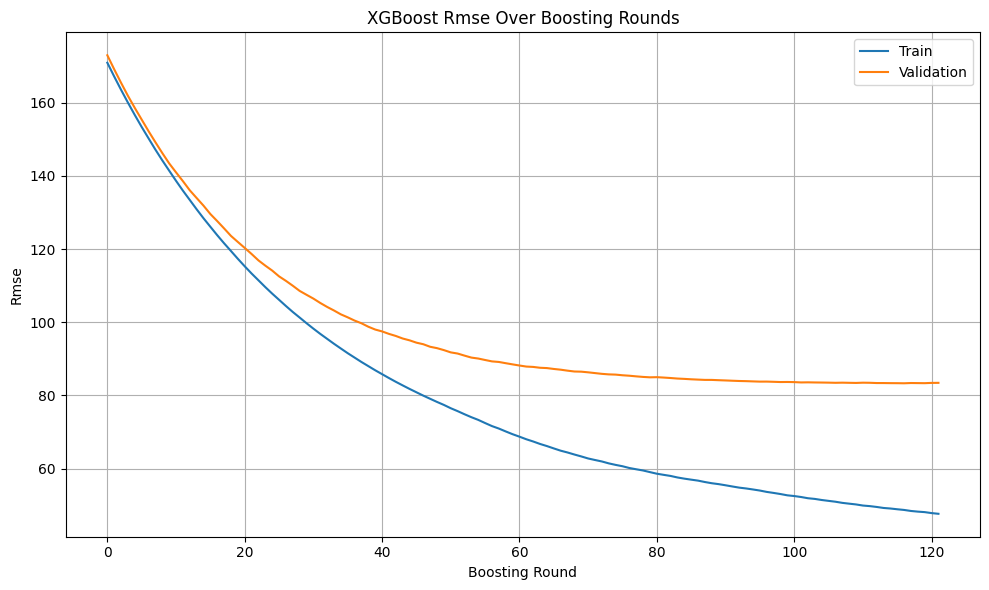

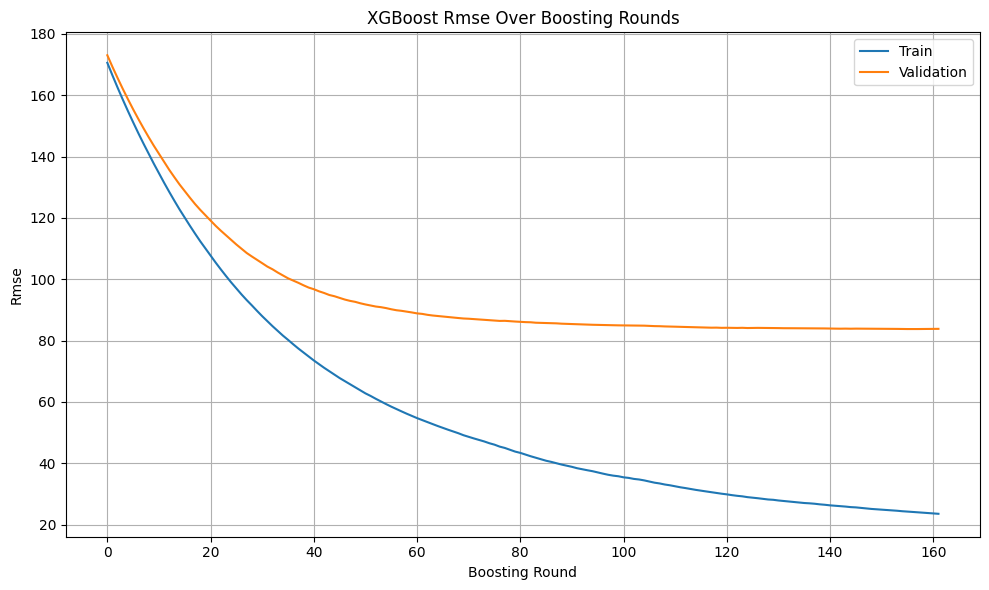

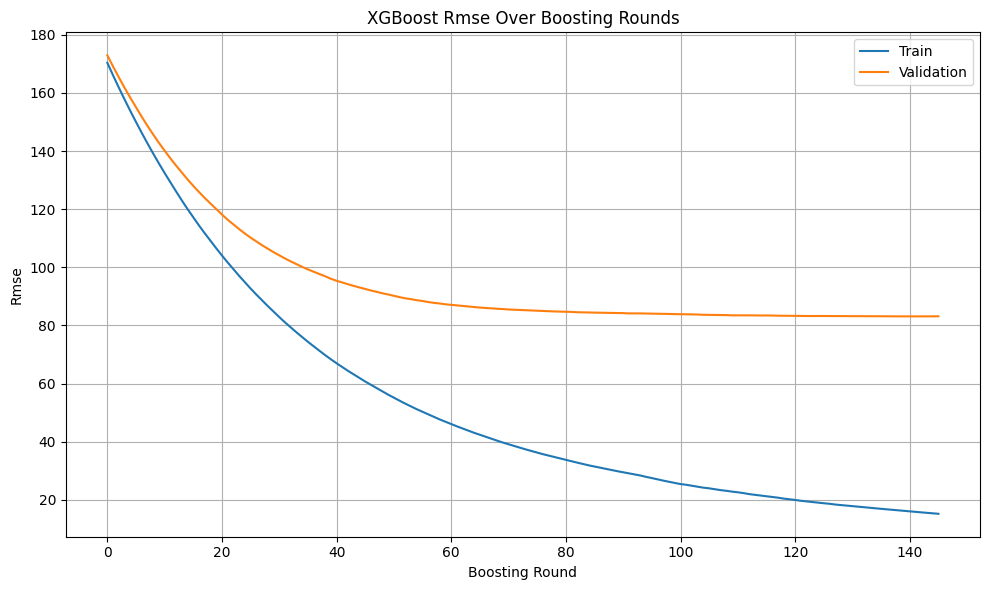

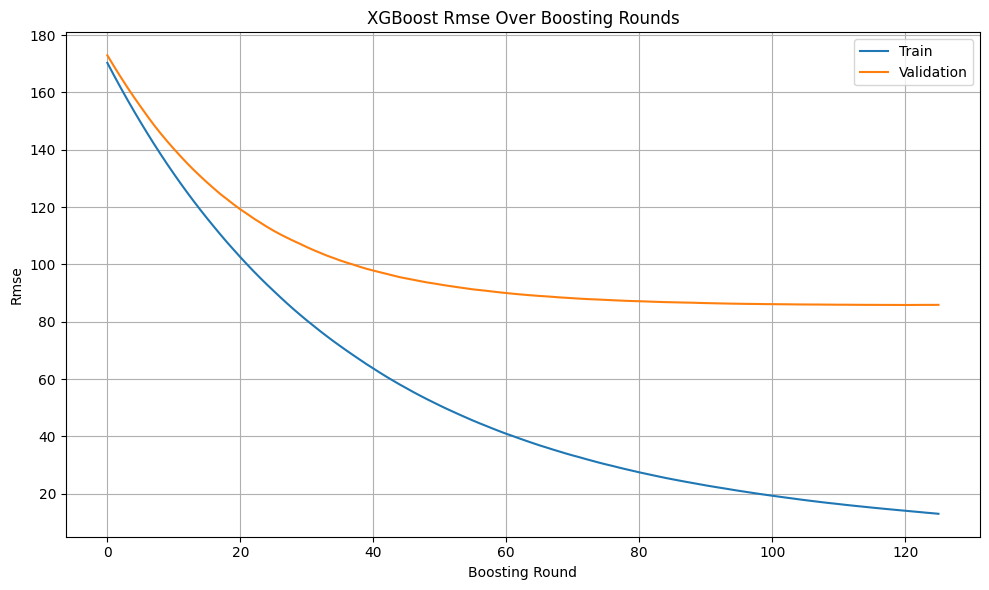

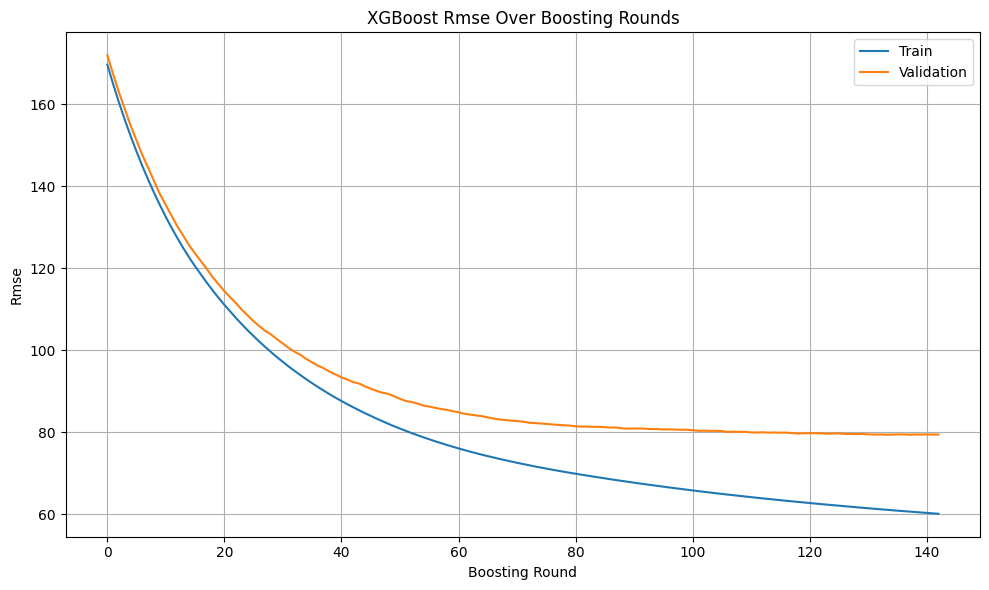

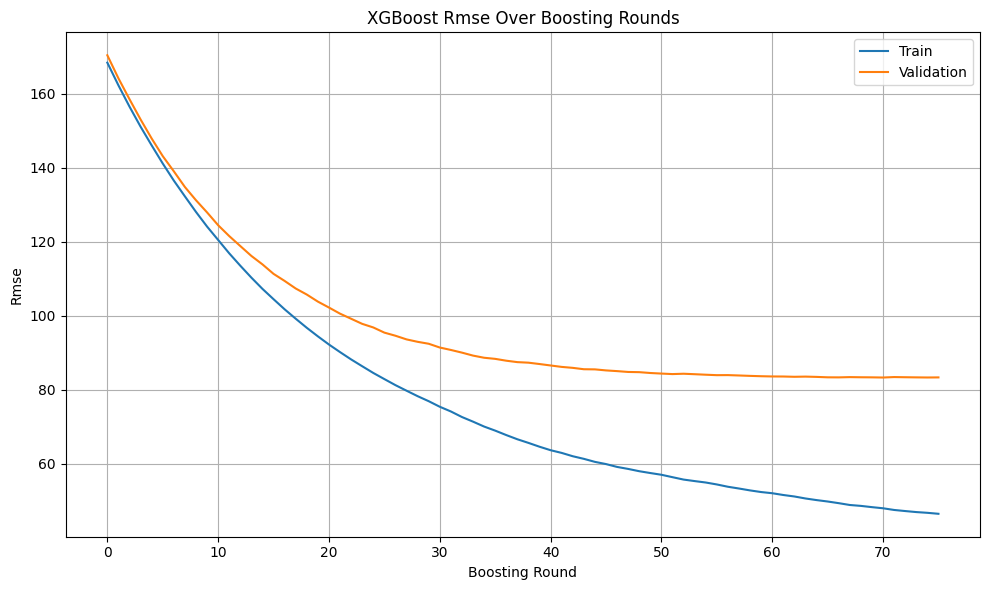

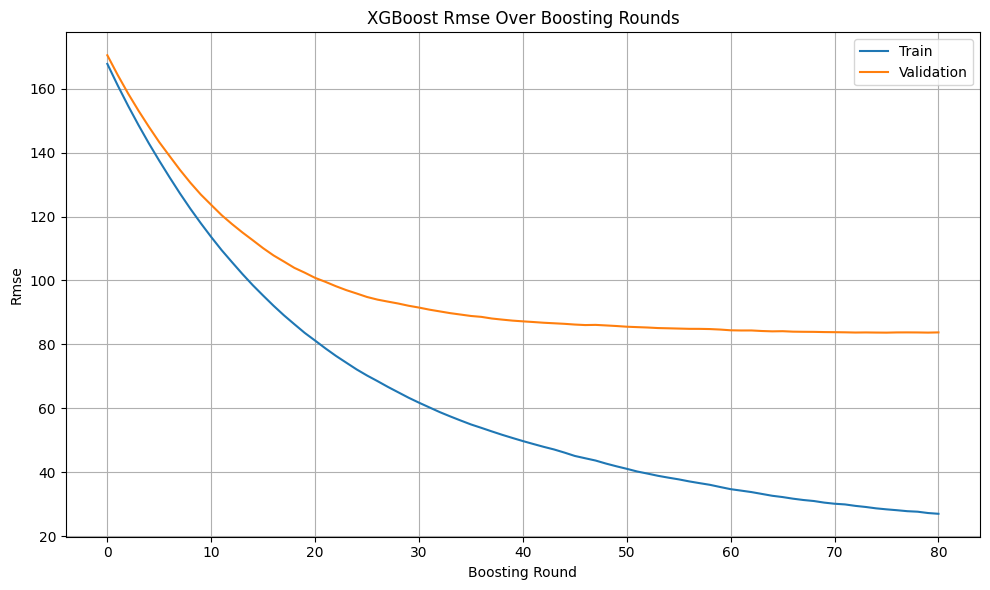

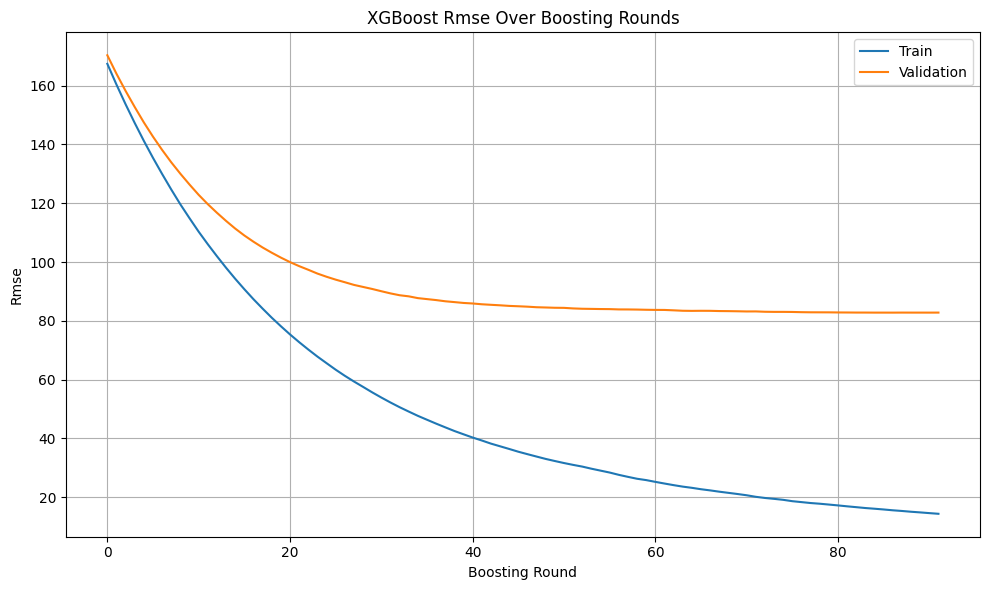

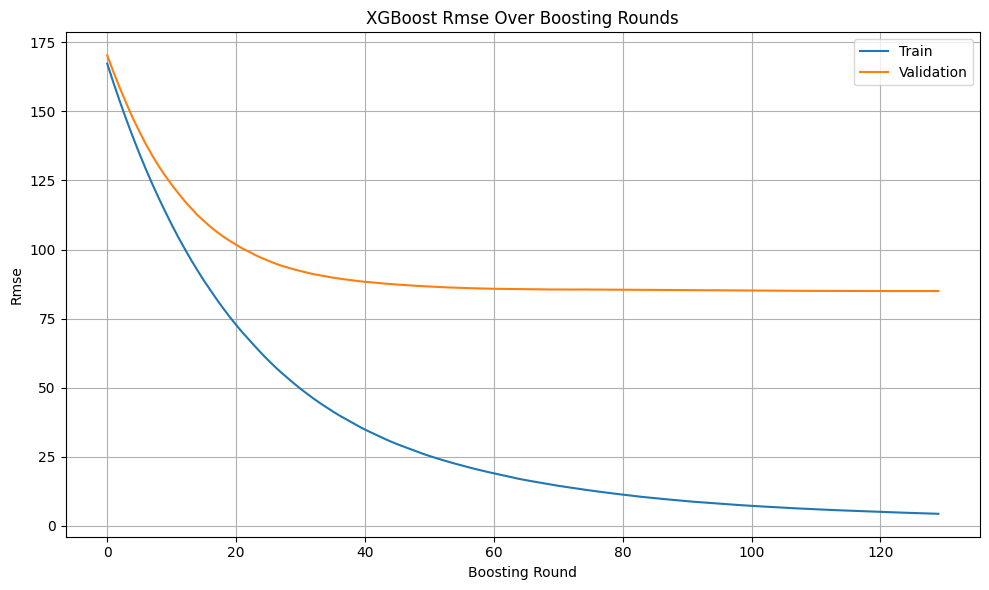

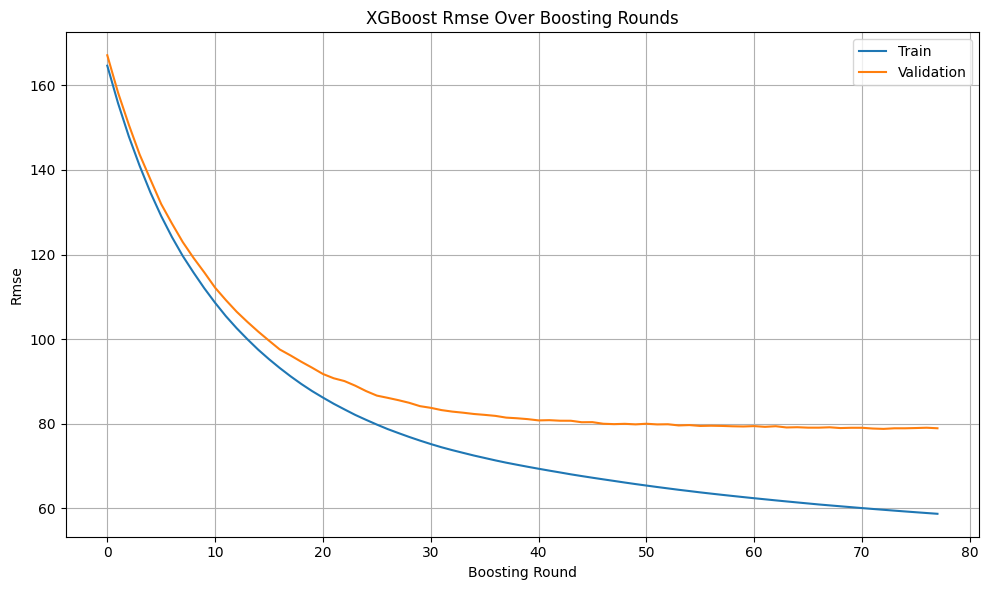

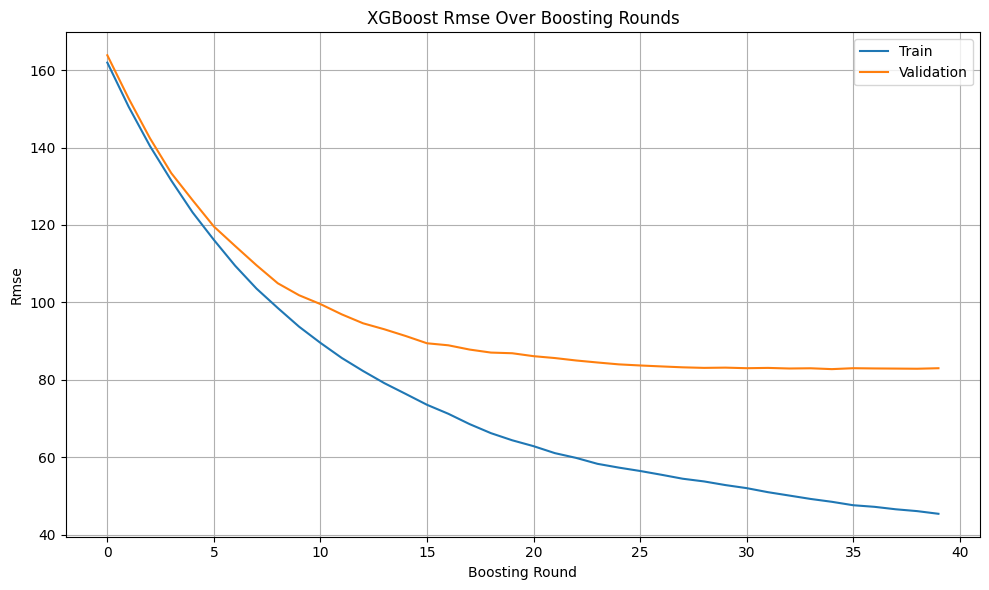

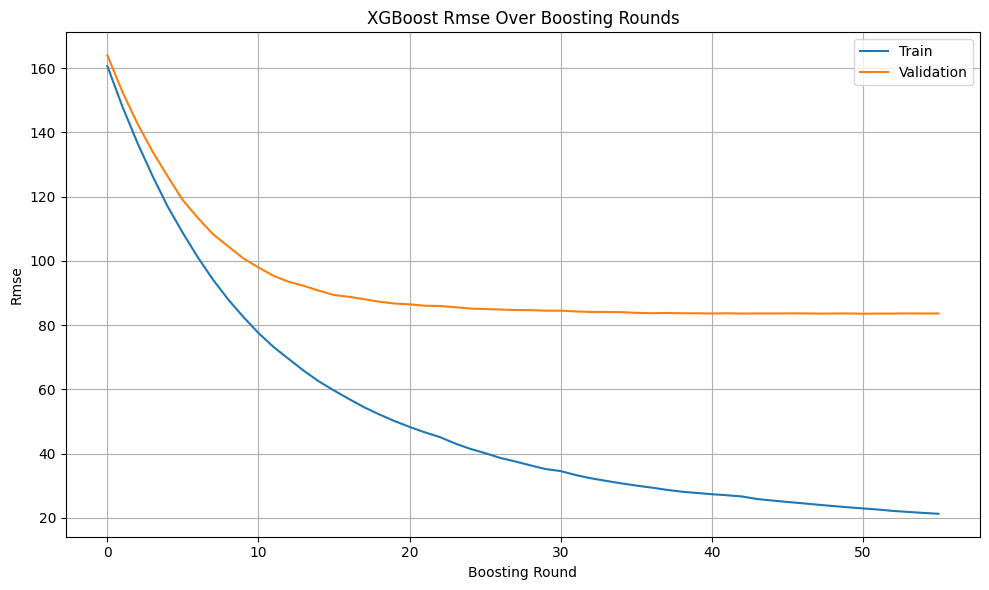

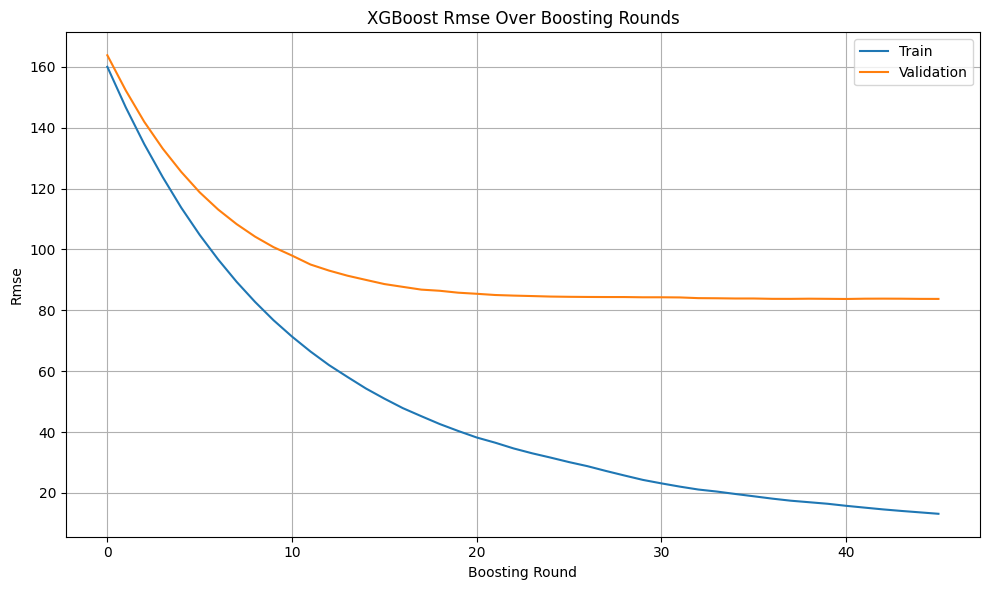

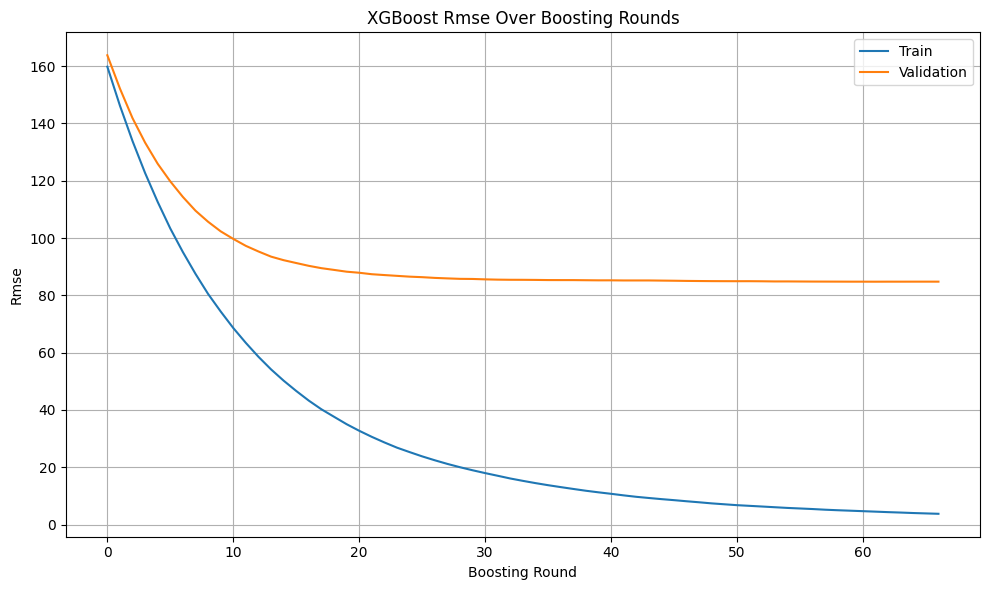

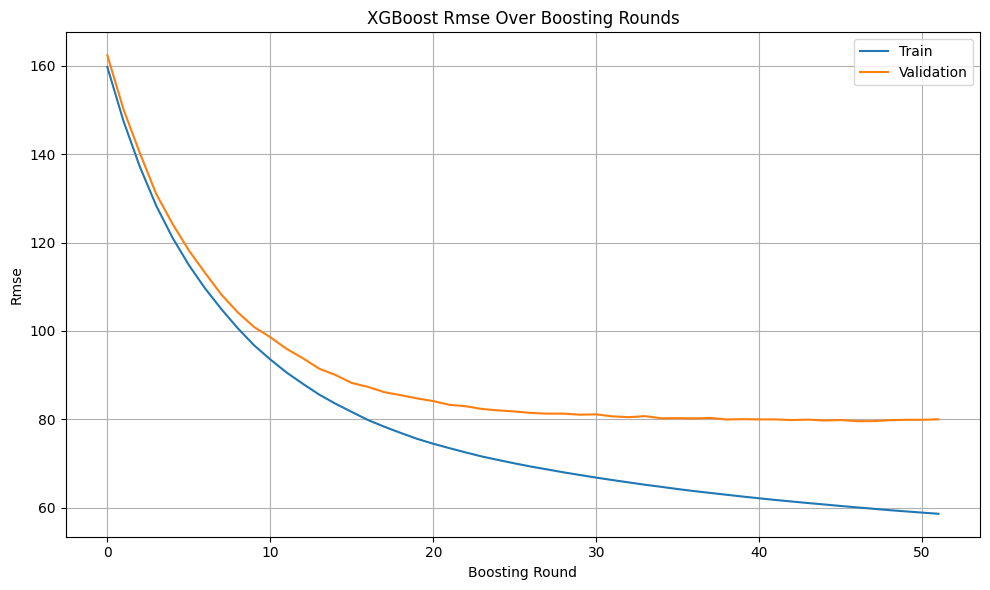

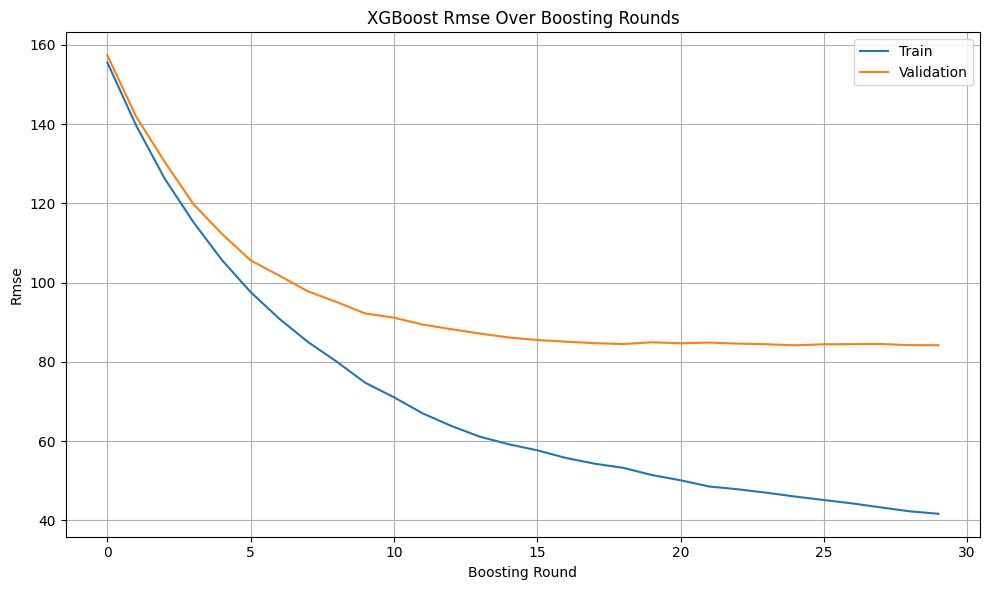

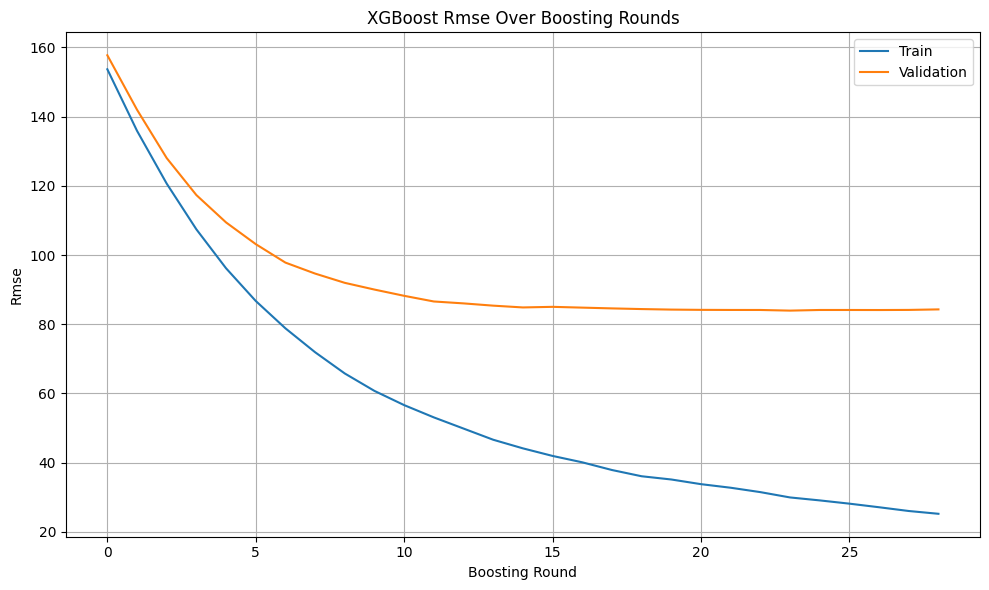

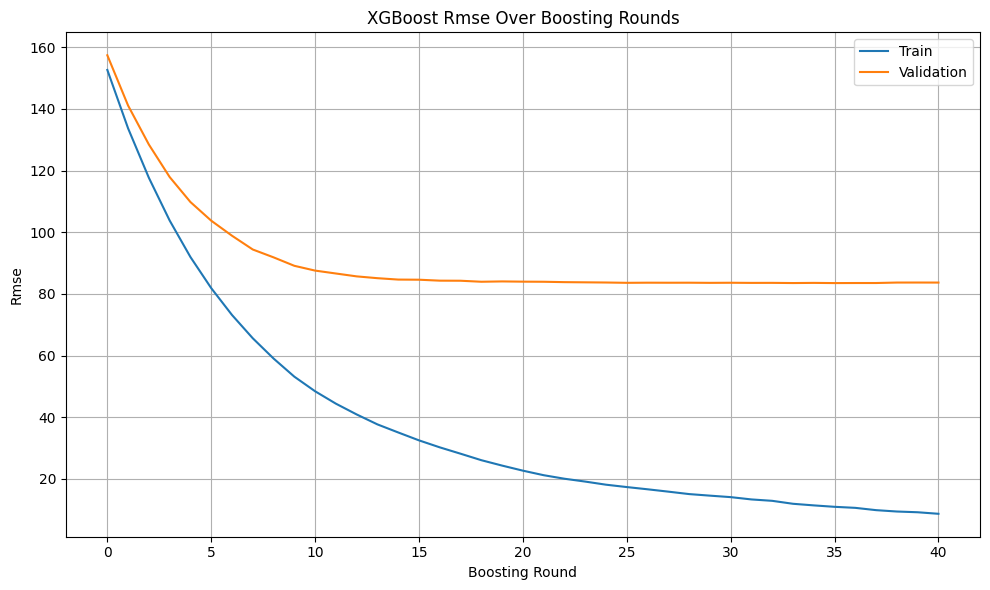

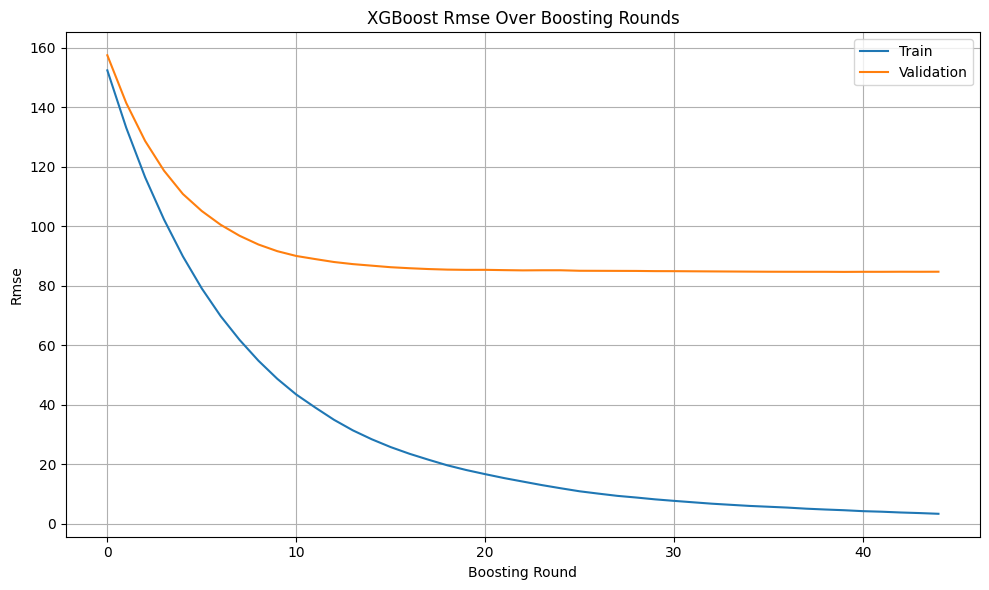

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\1052736820.py:22: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


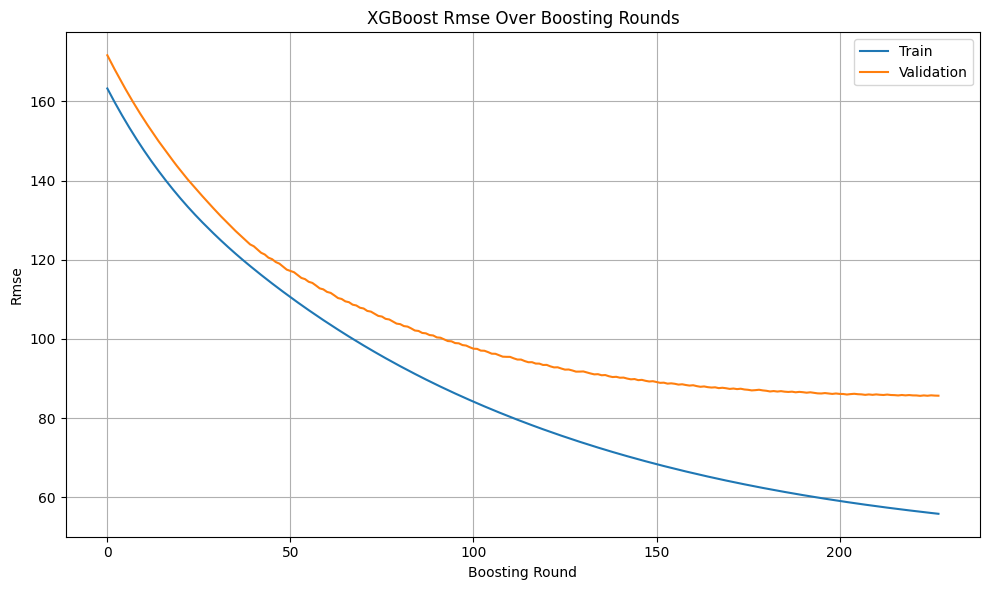

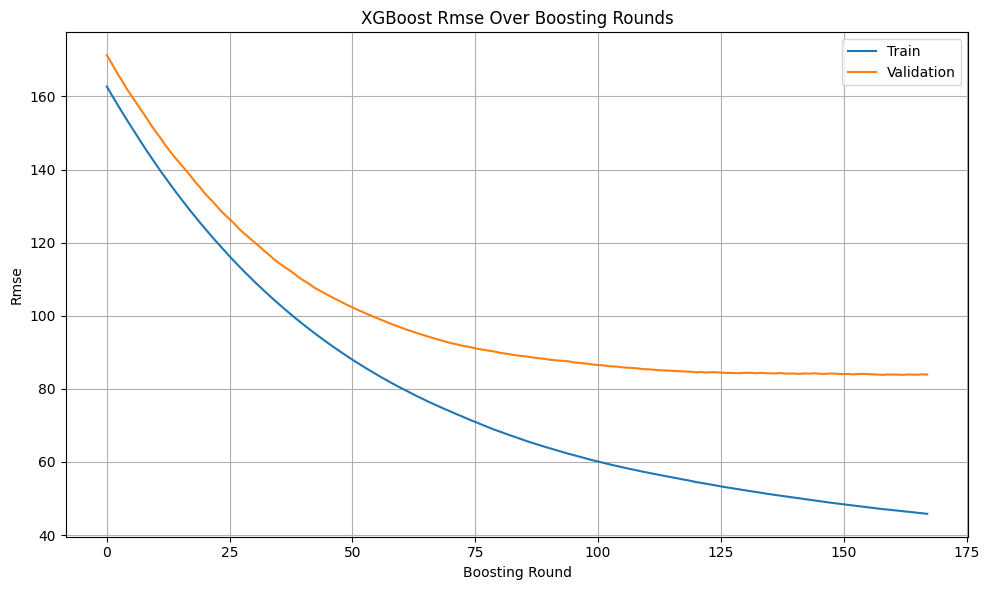

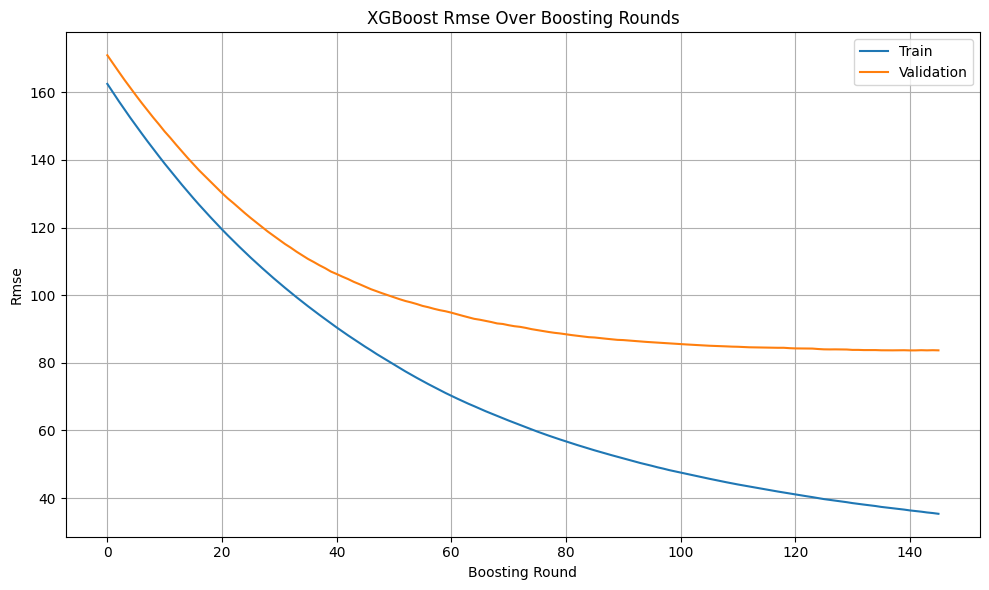

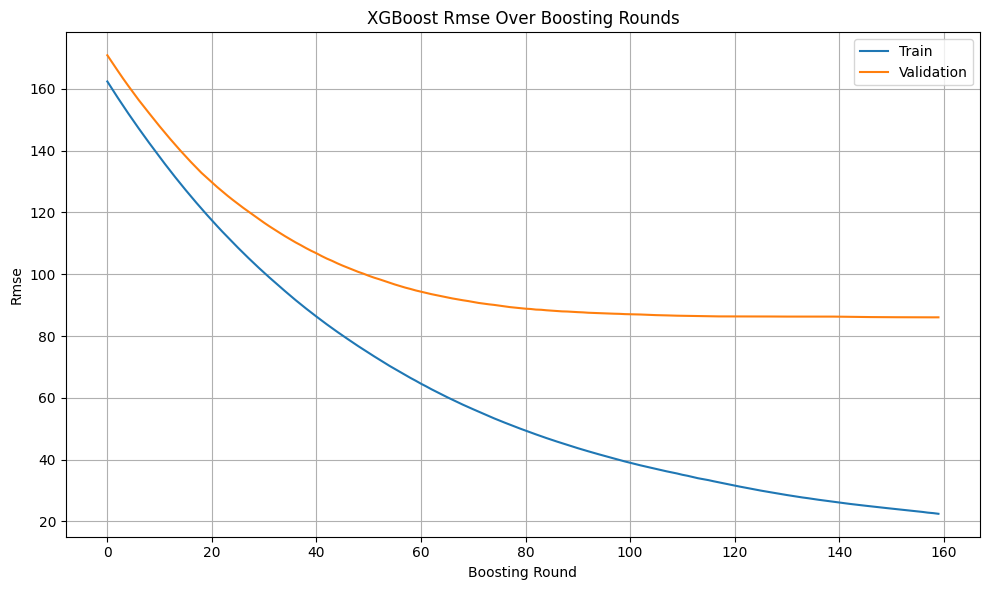

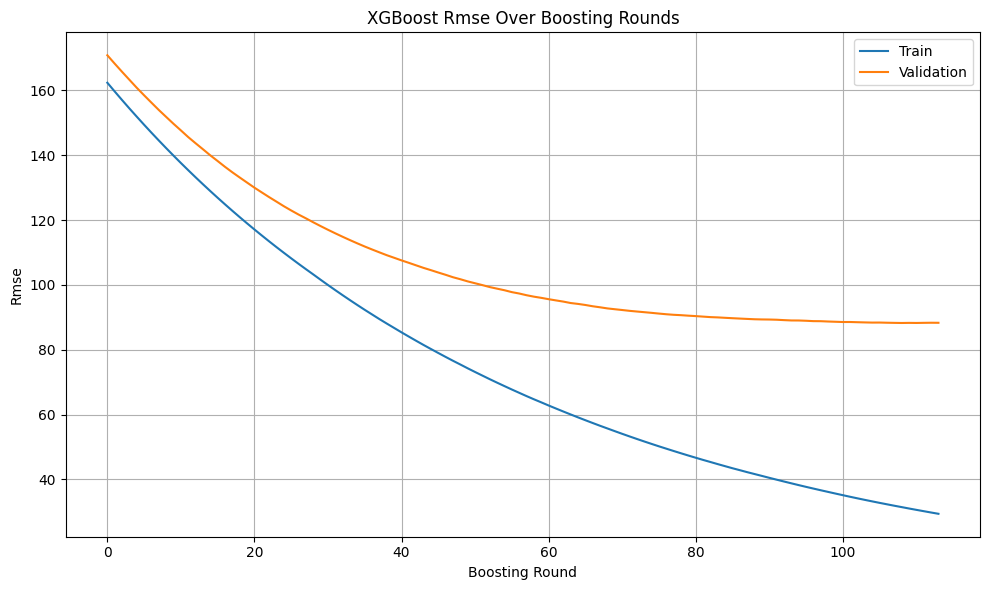

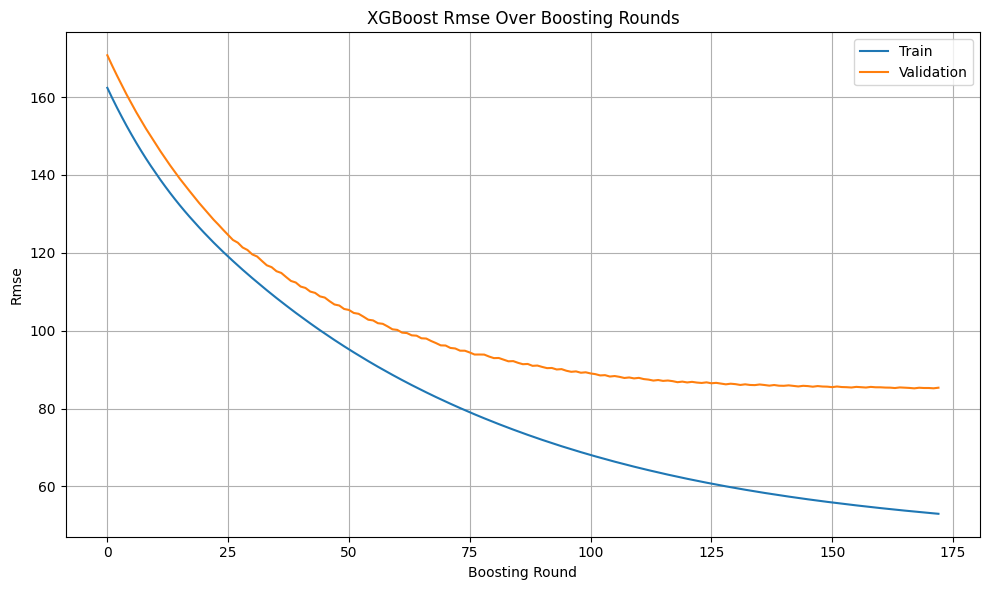

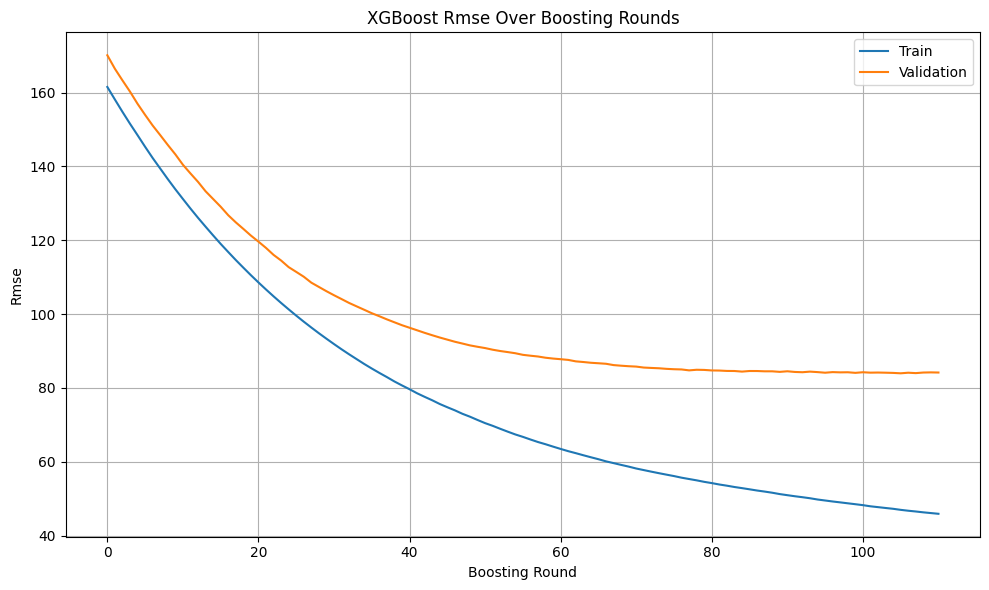

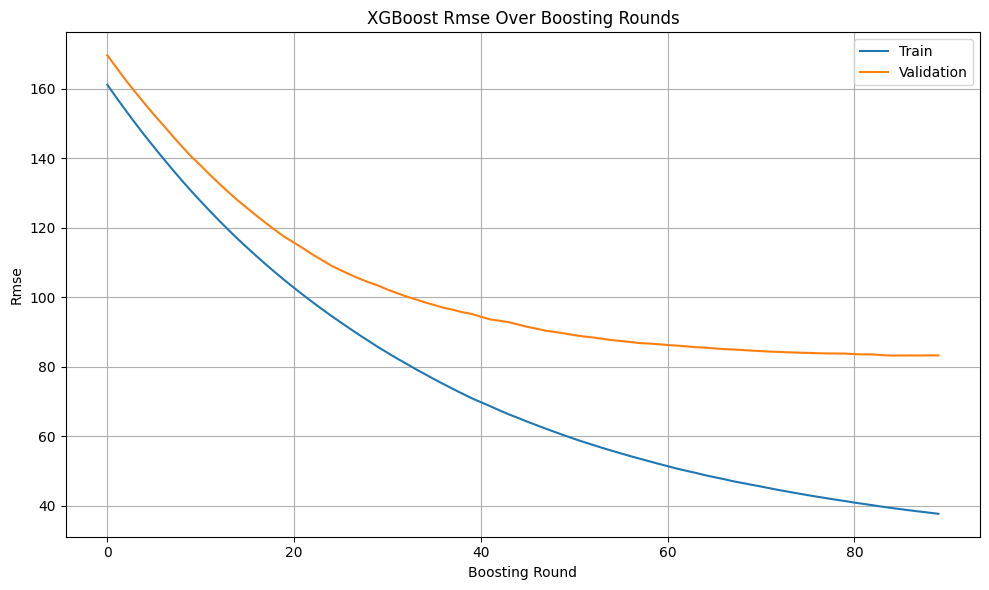

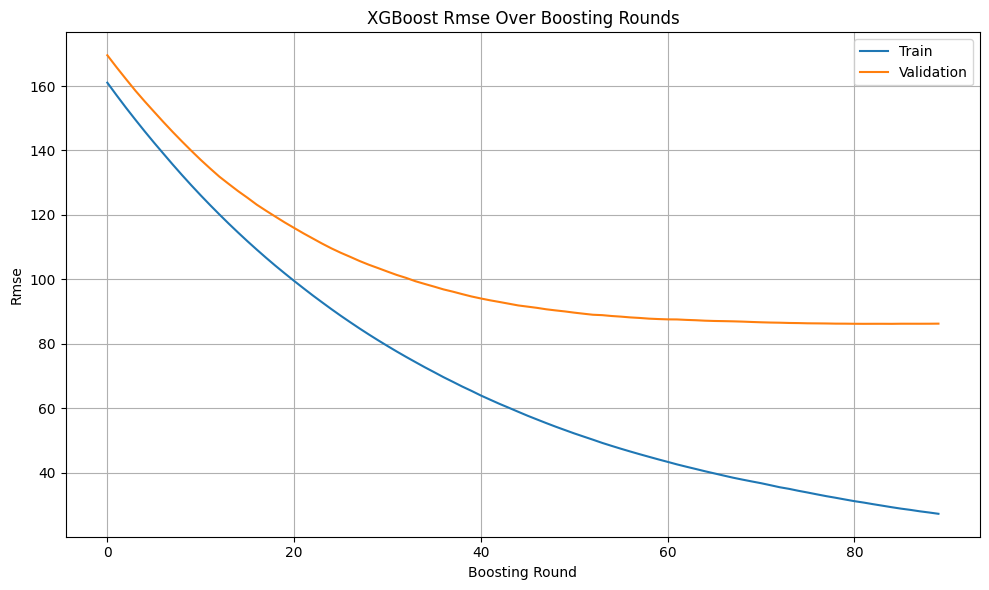

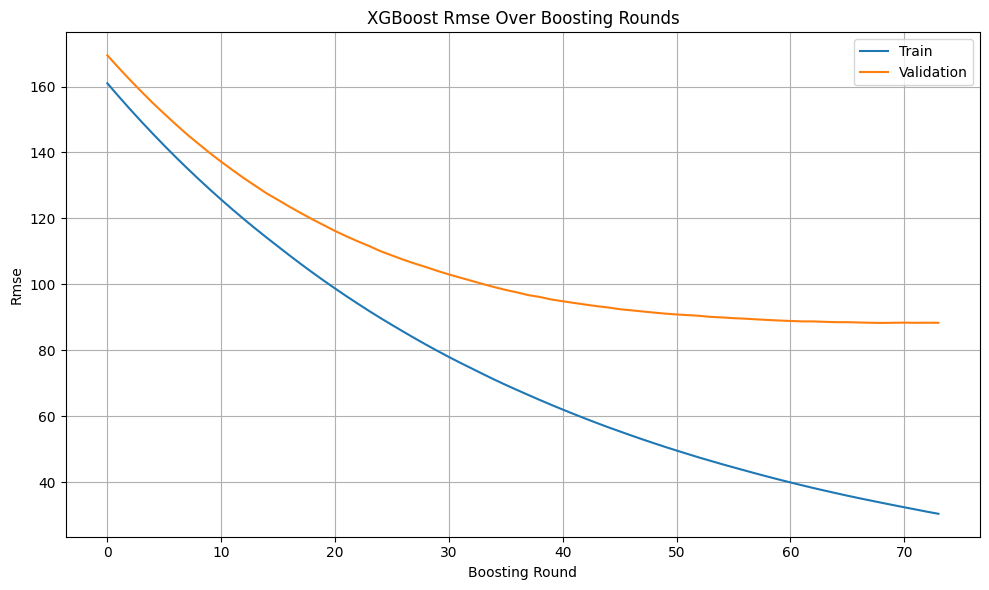

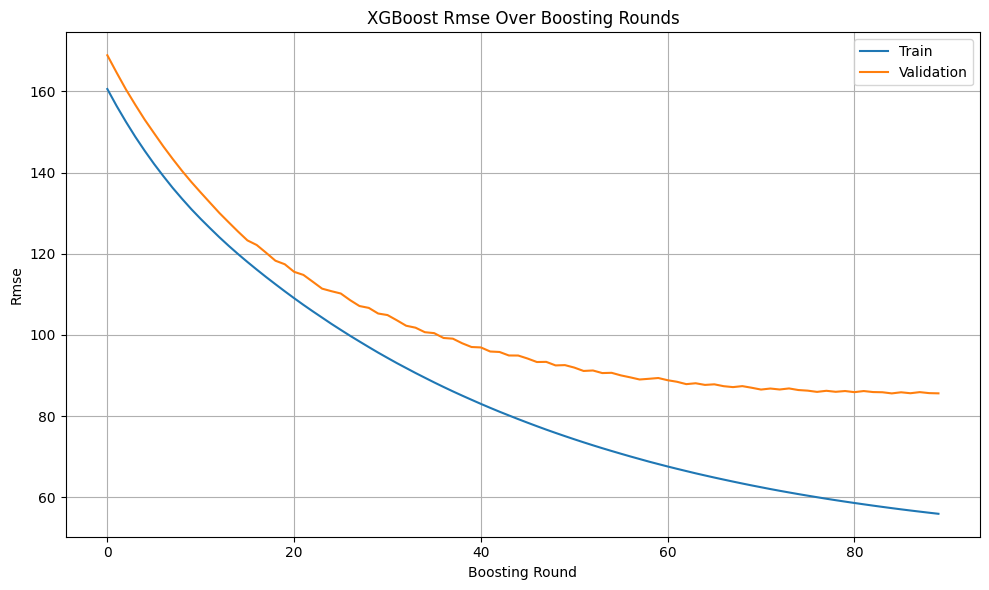

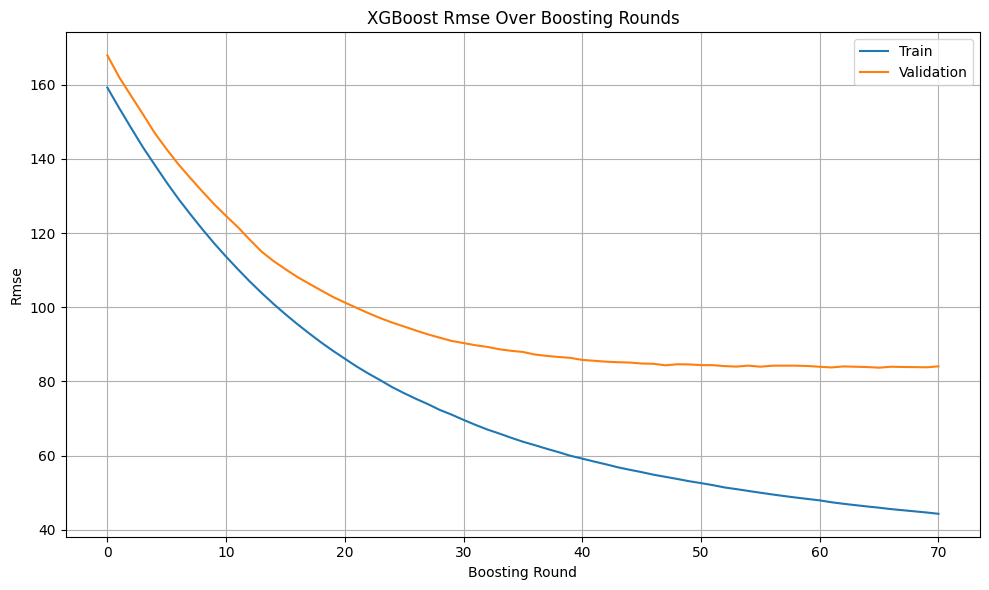

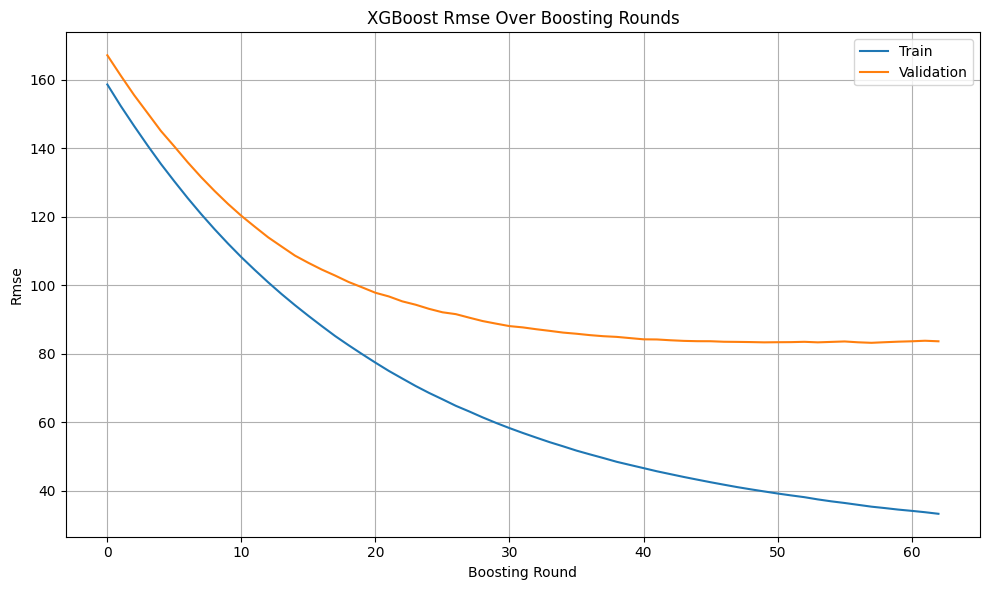

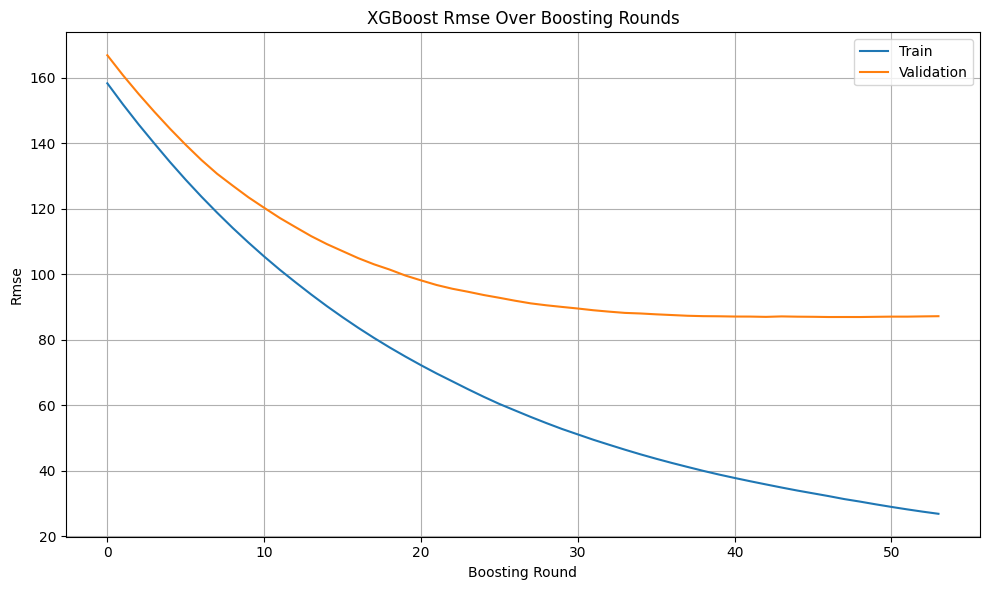

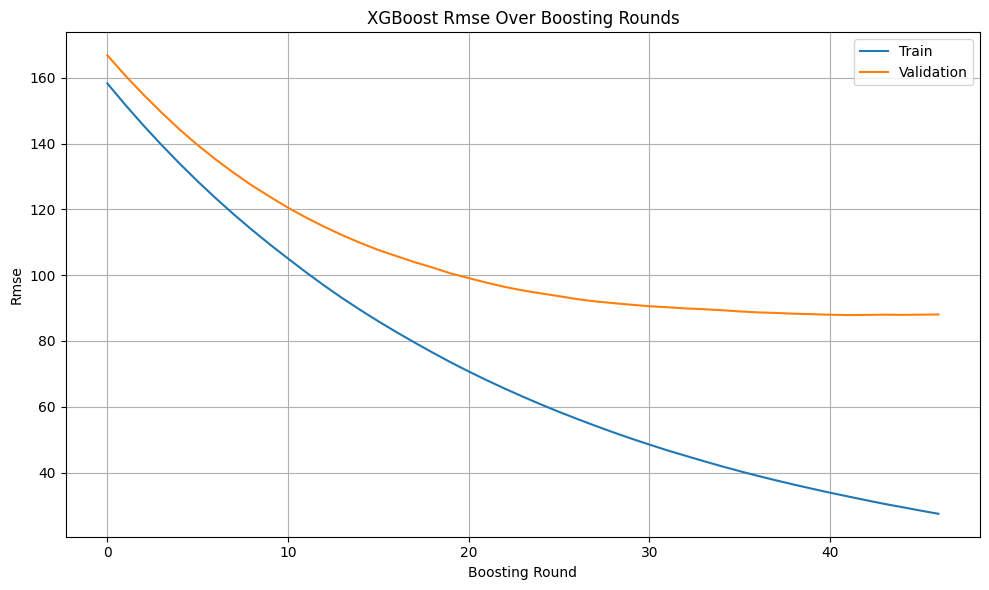

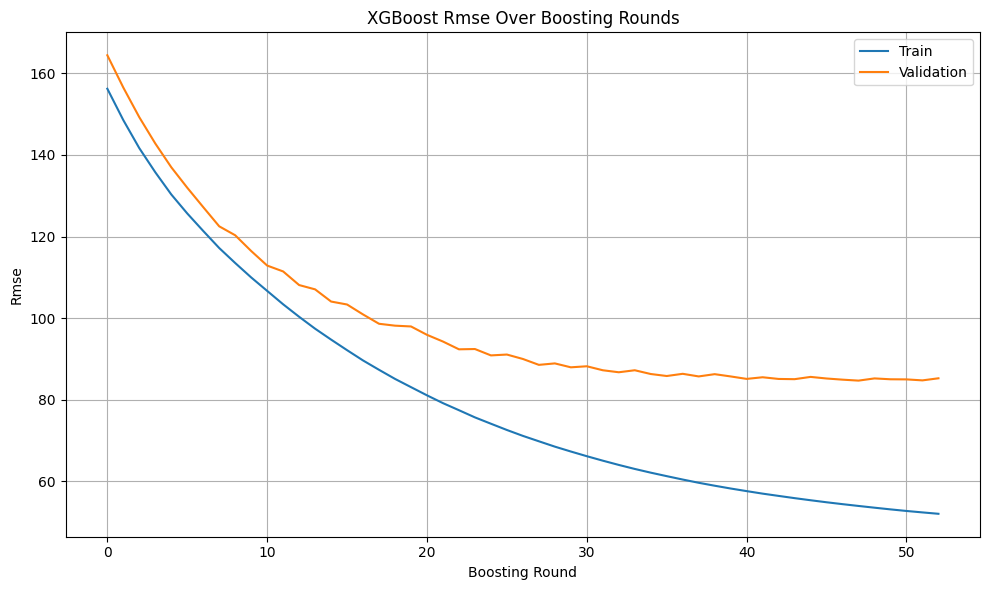

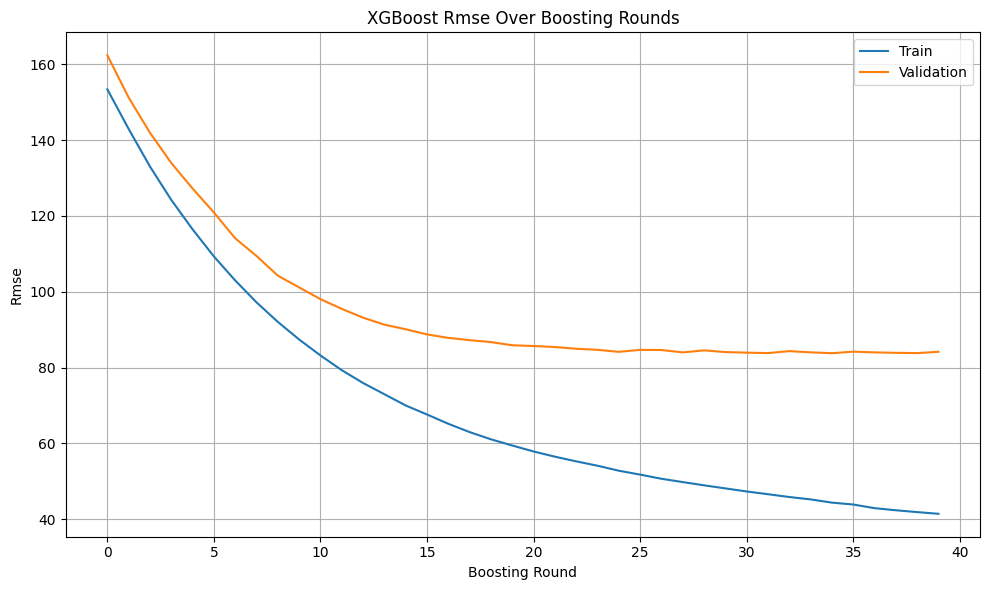

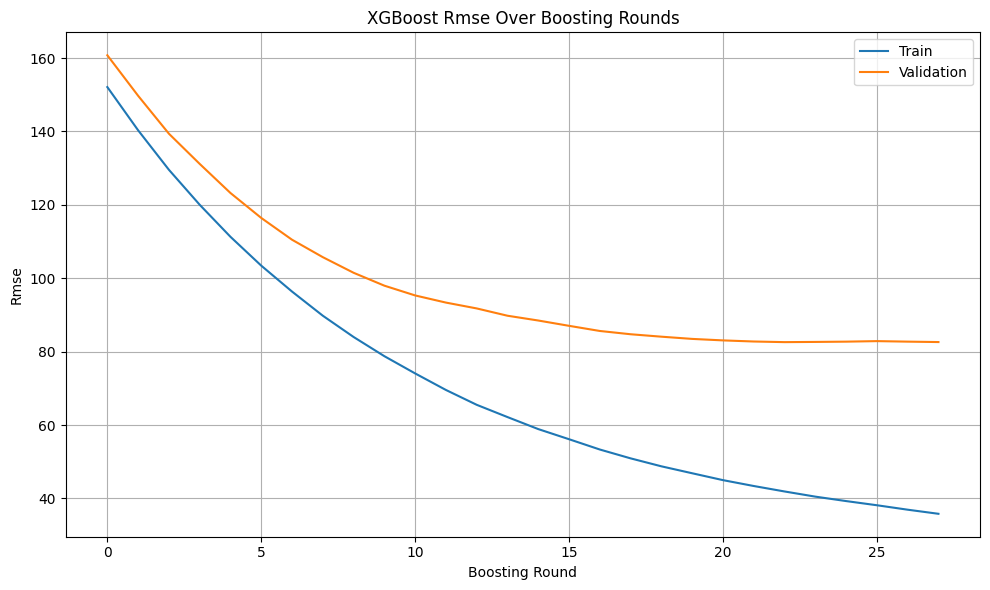

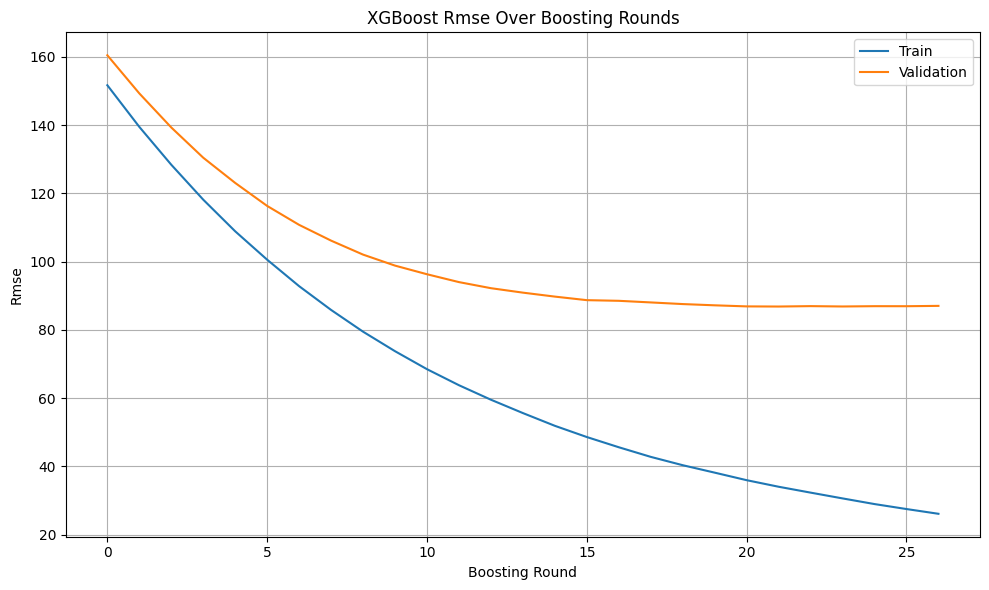

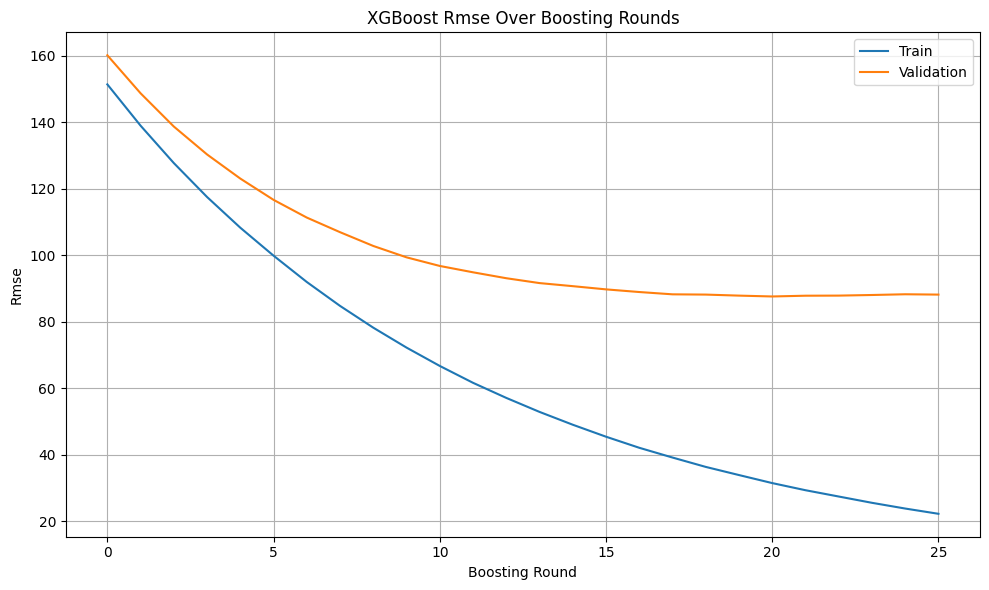

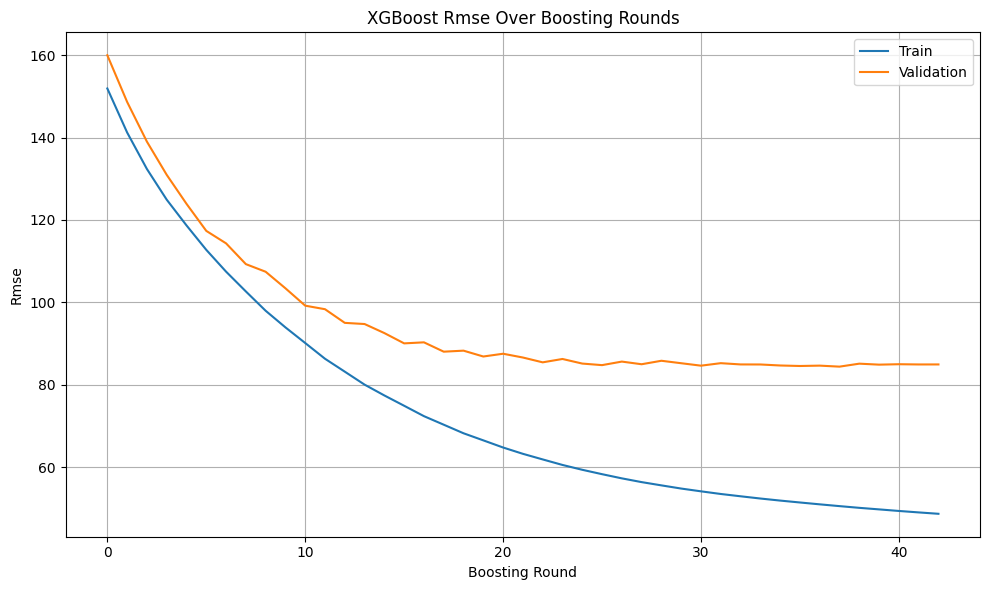

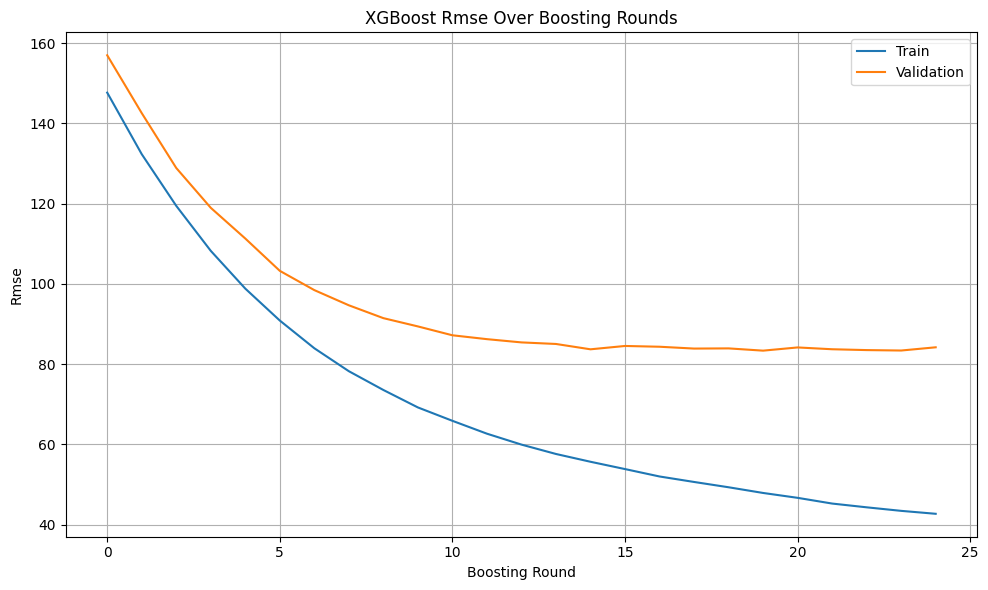

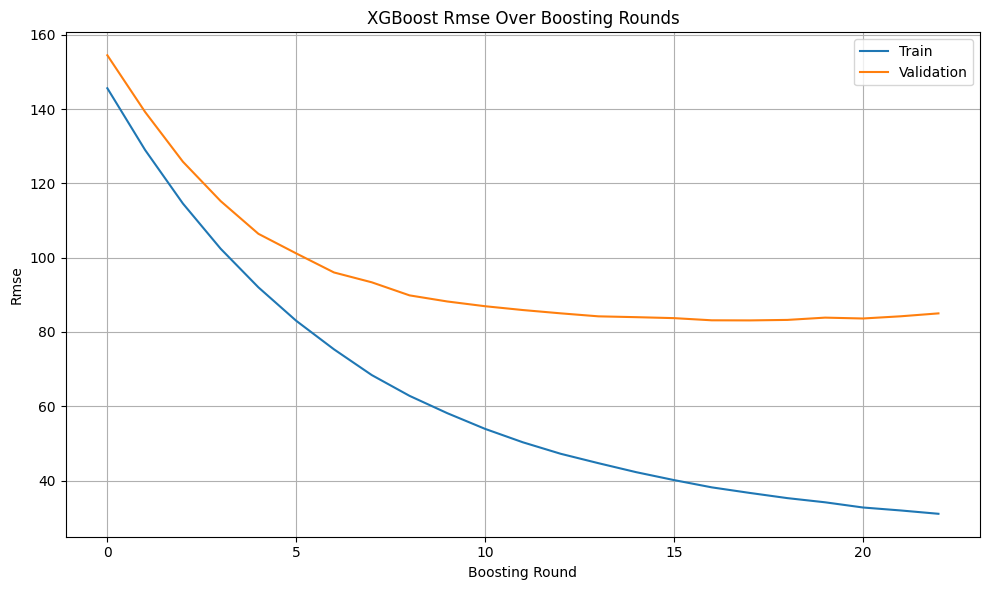

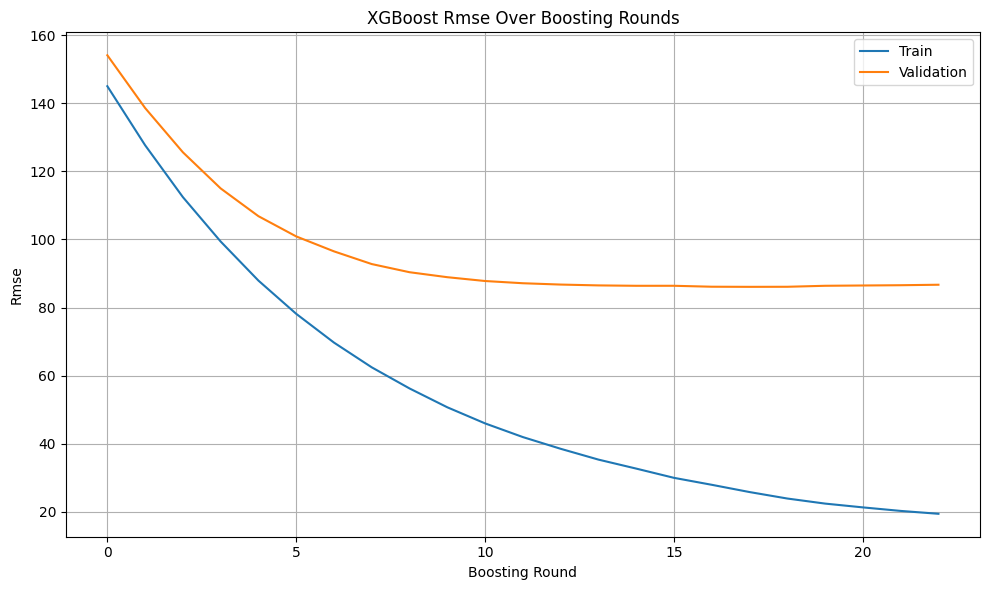

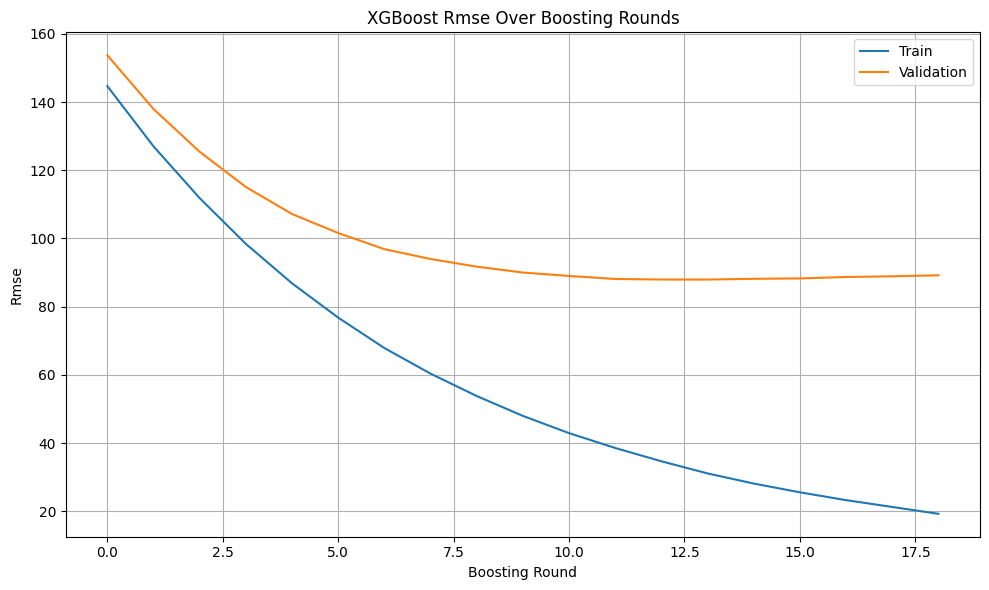

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\1052736820.py:22: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


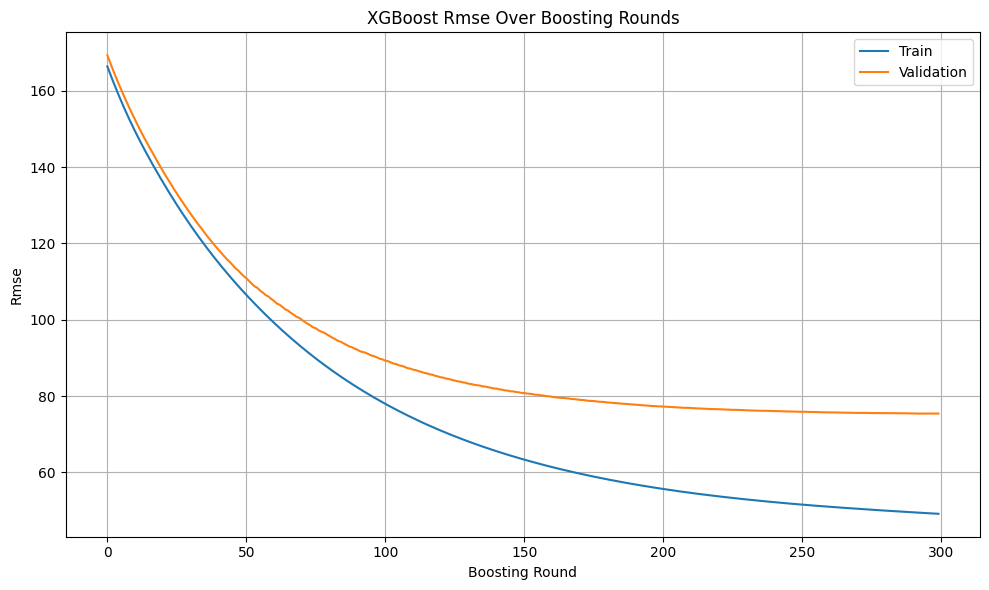

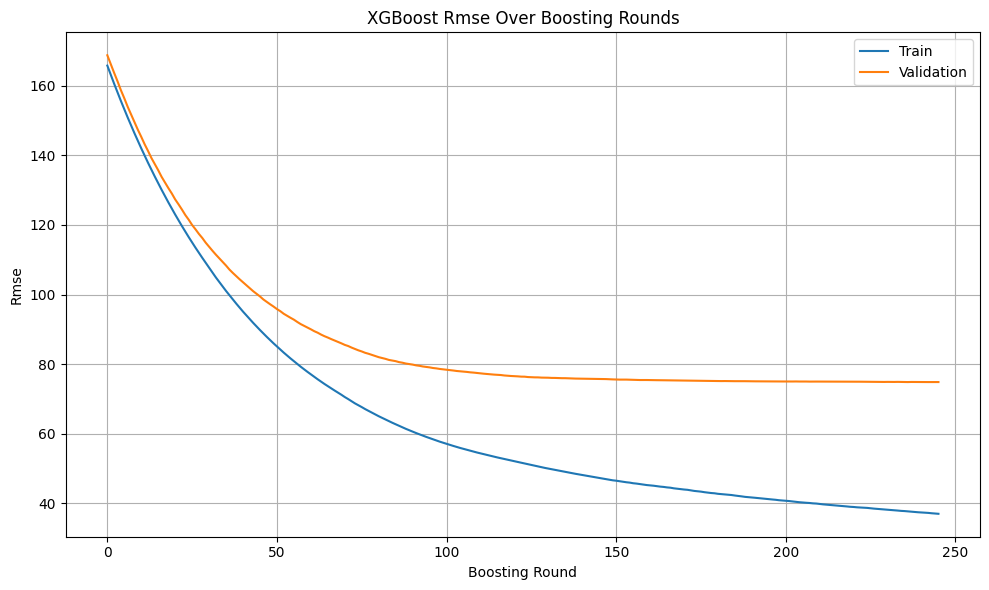

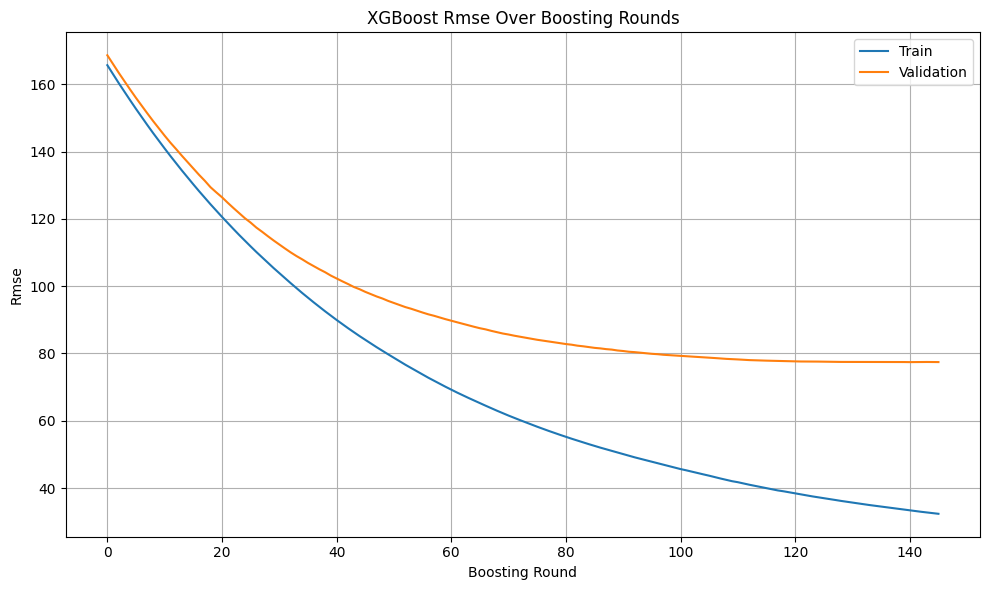

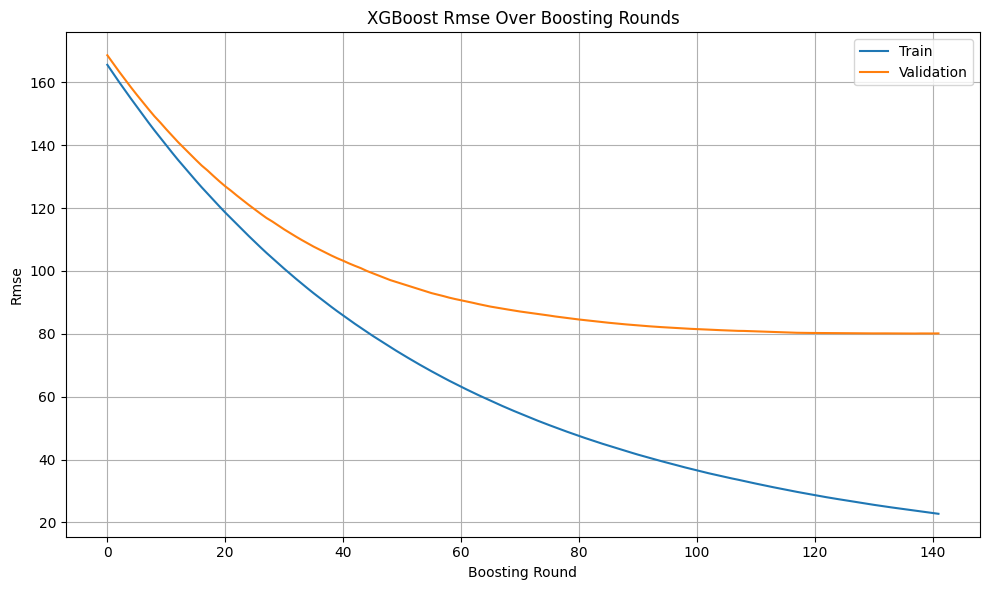

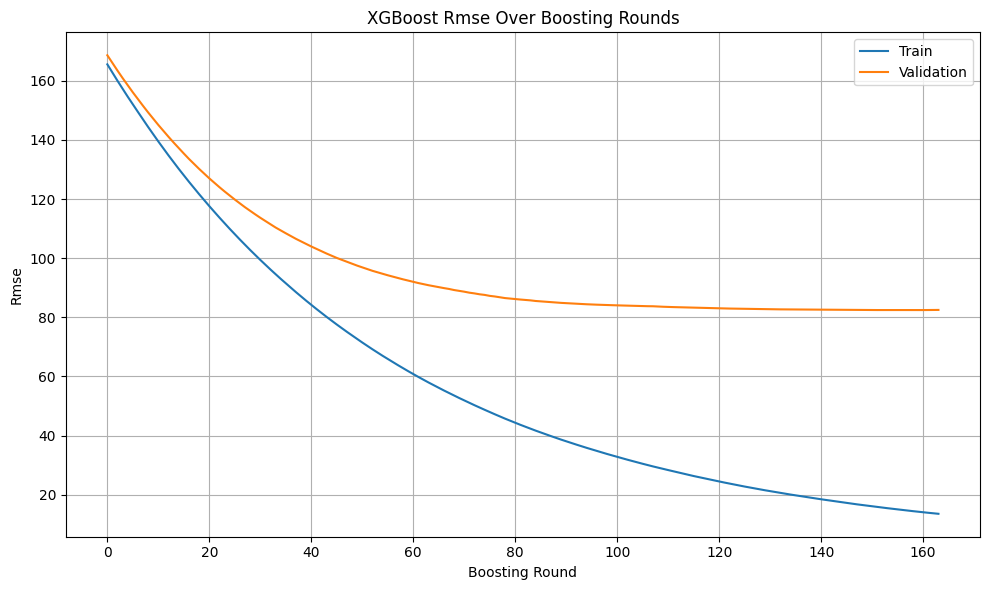

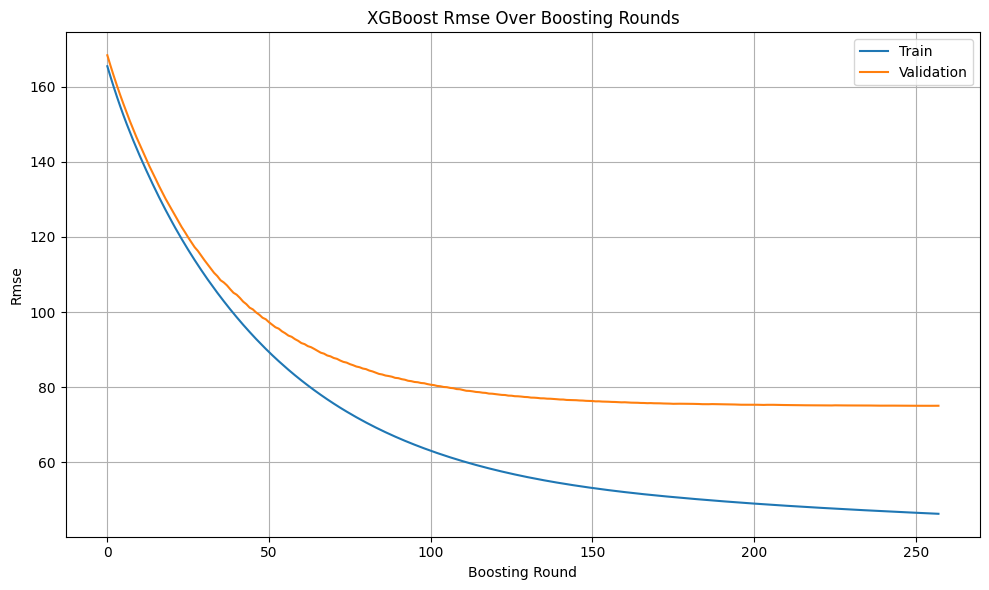

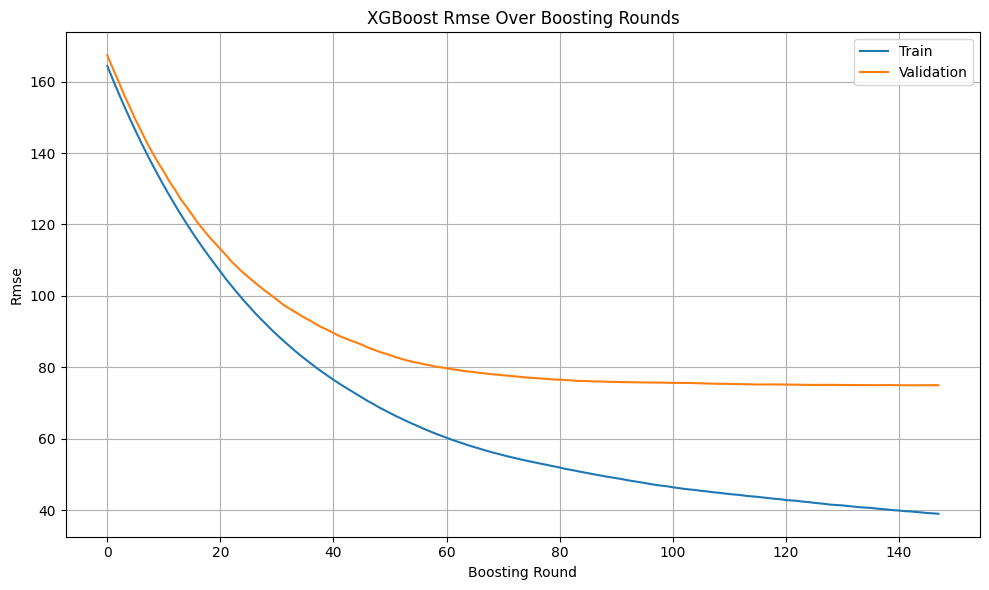

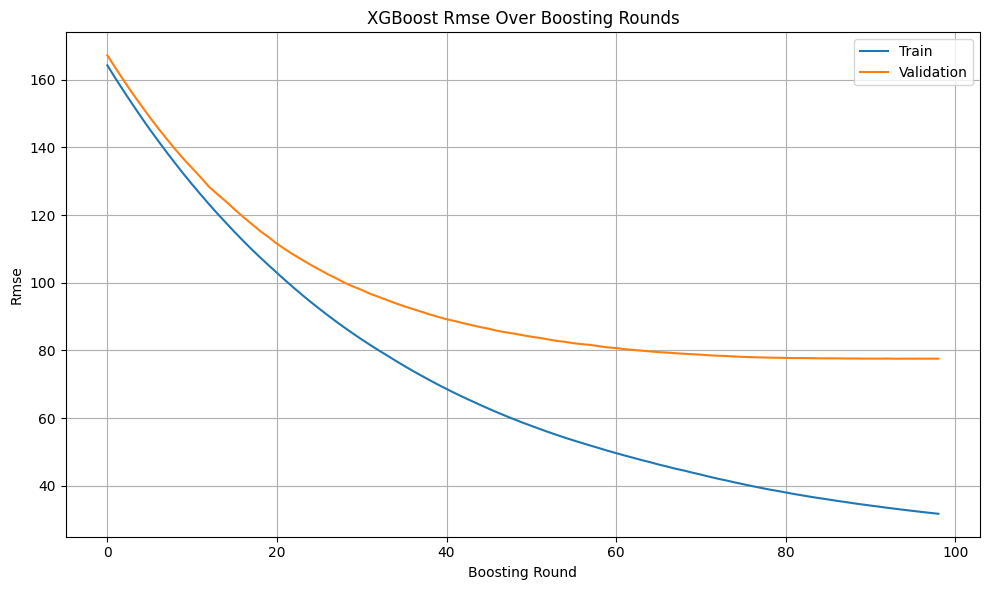

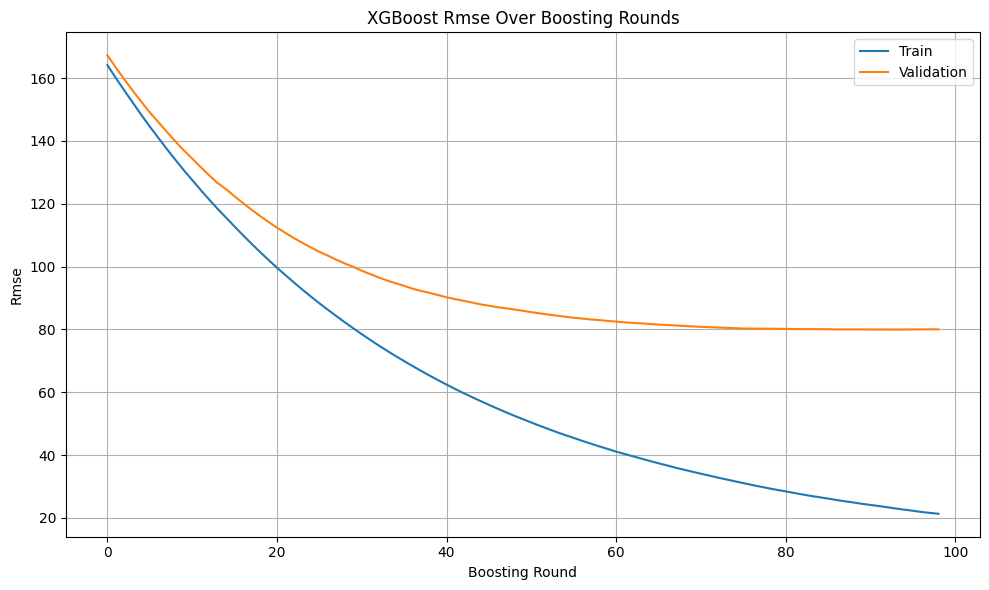

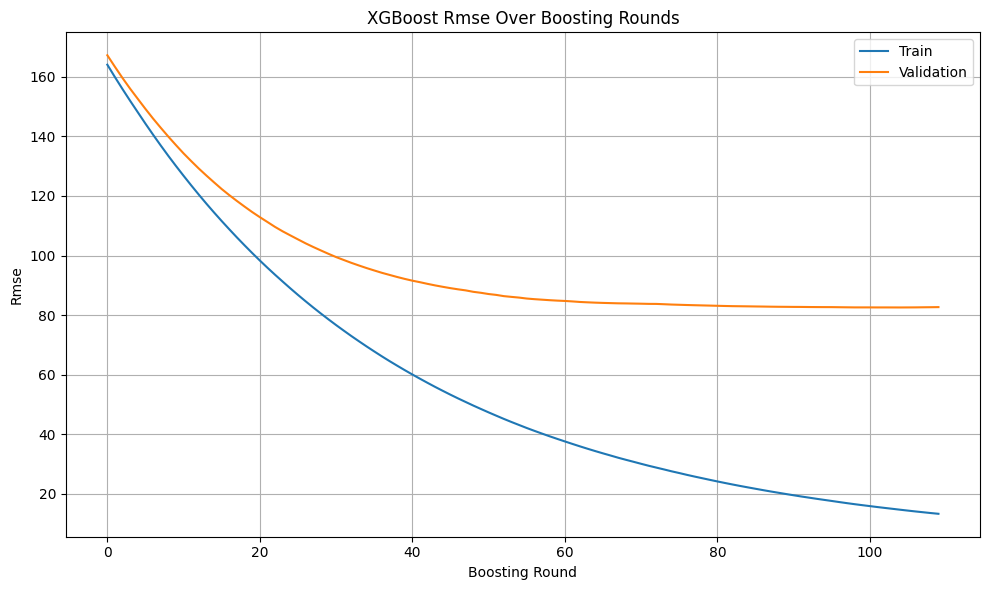

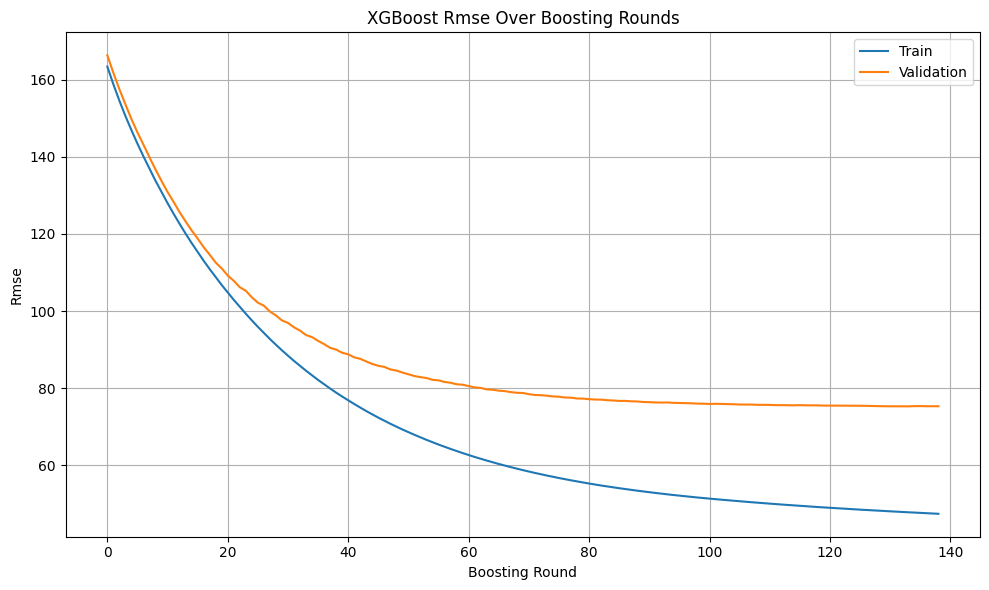

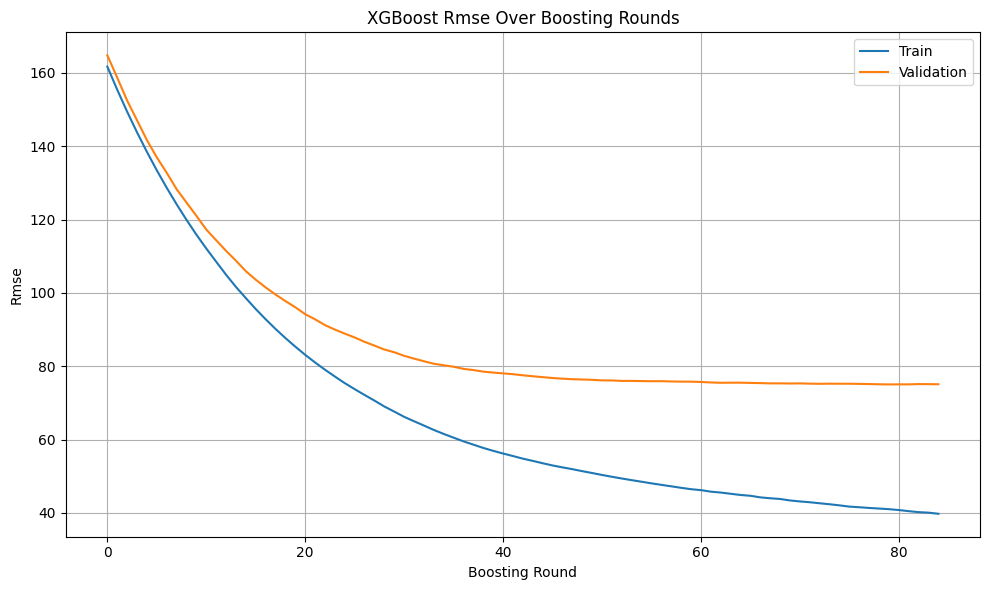

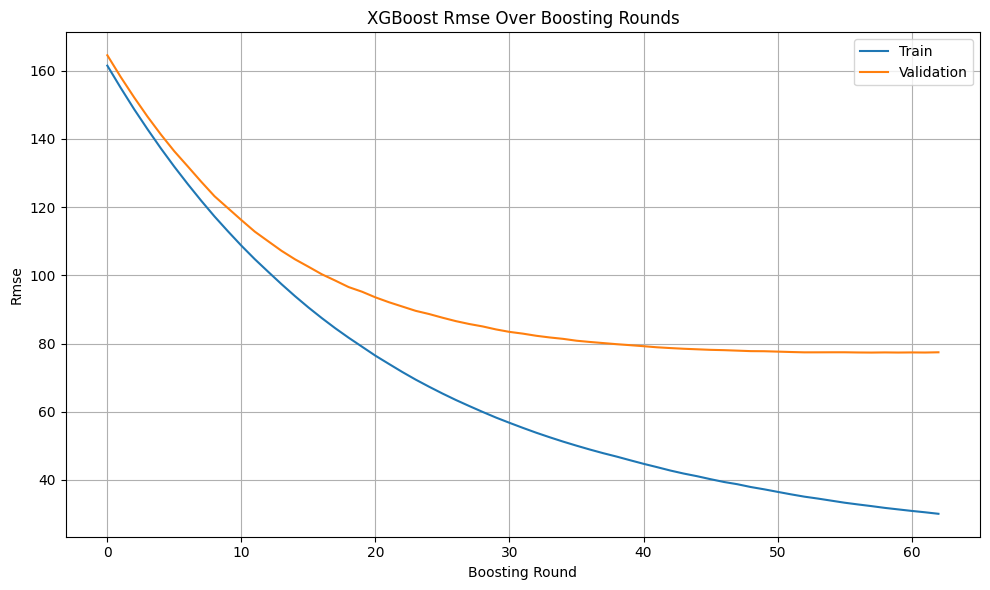

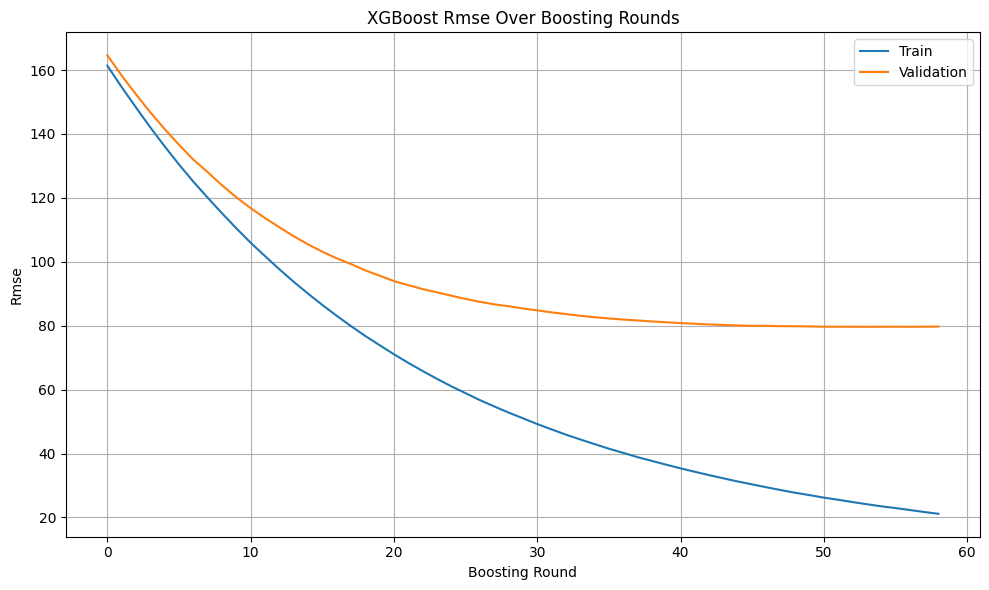

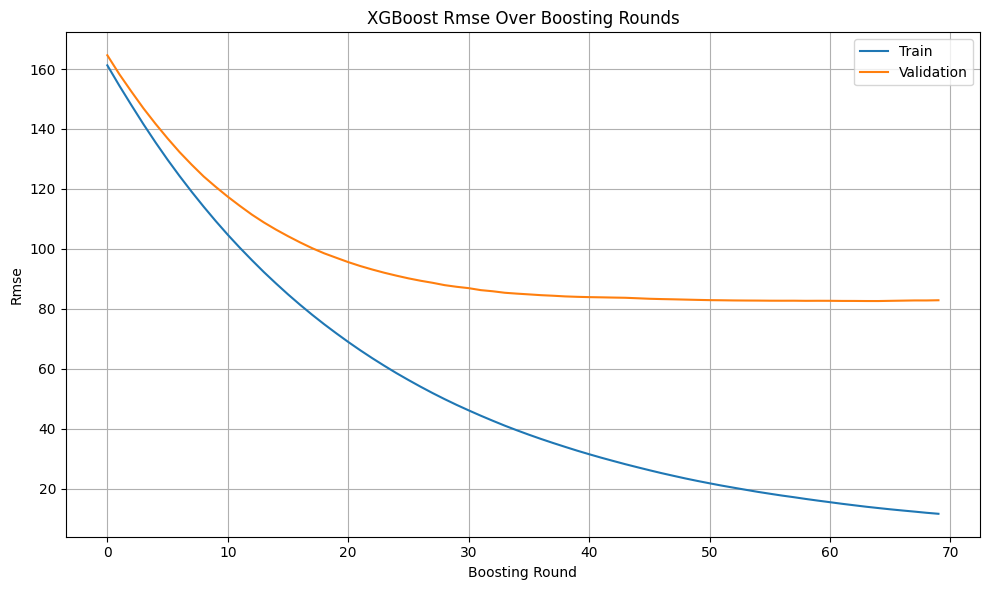

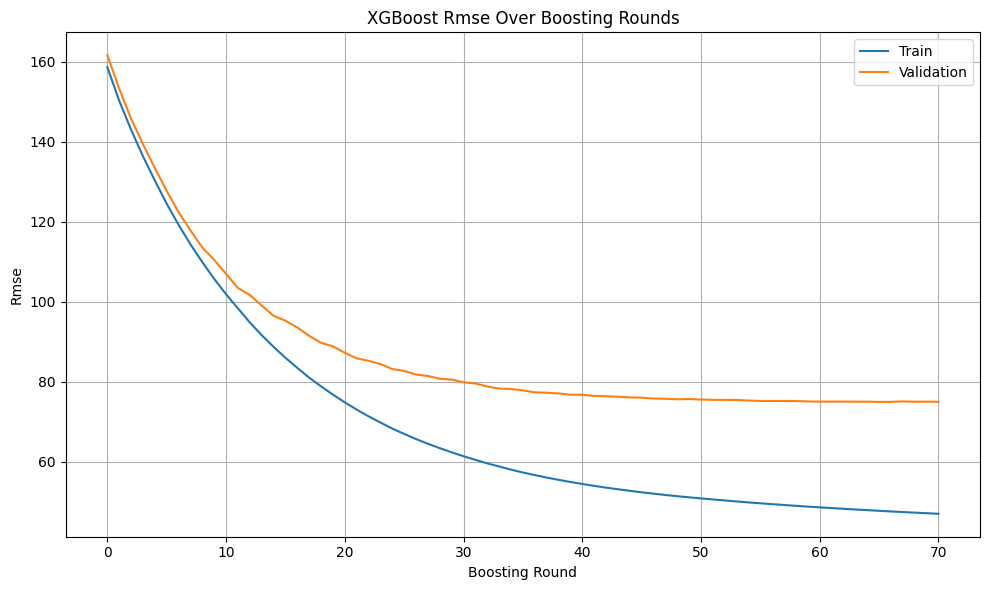

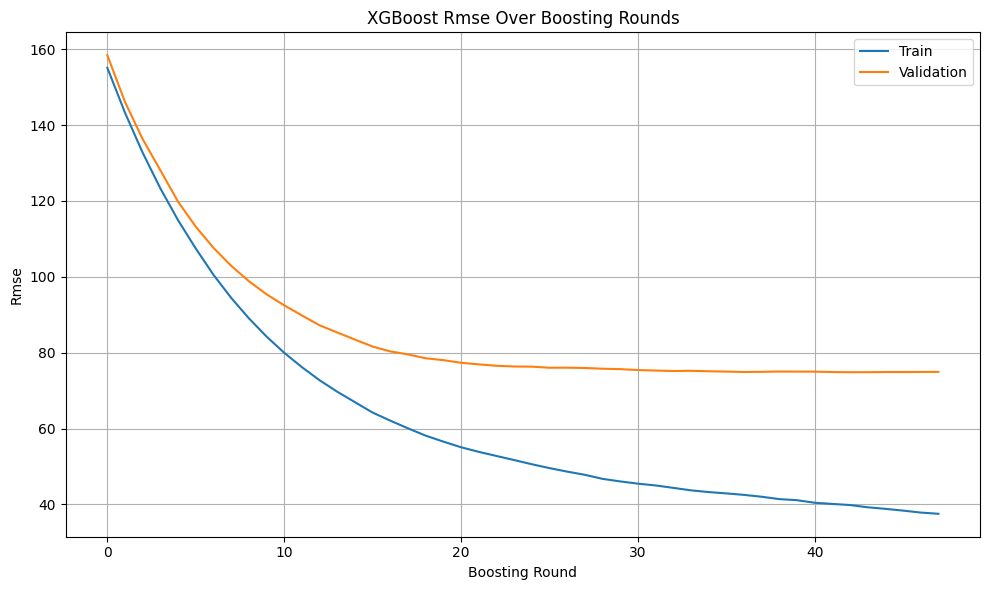

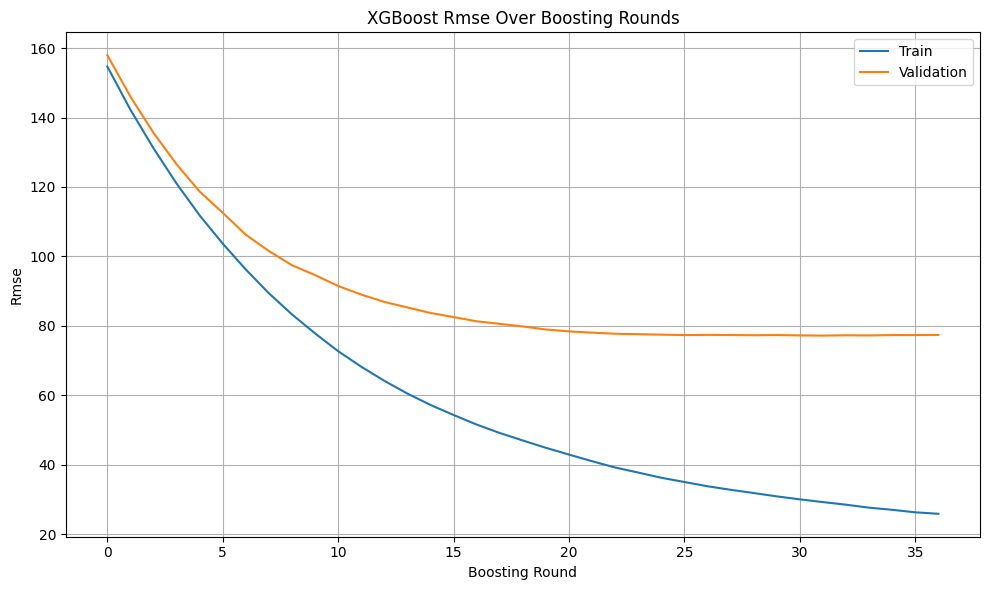

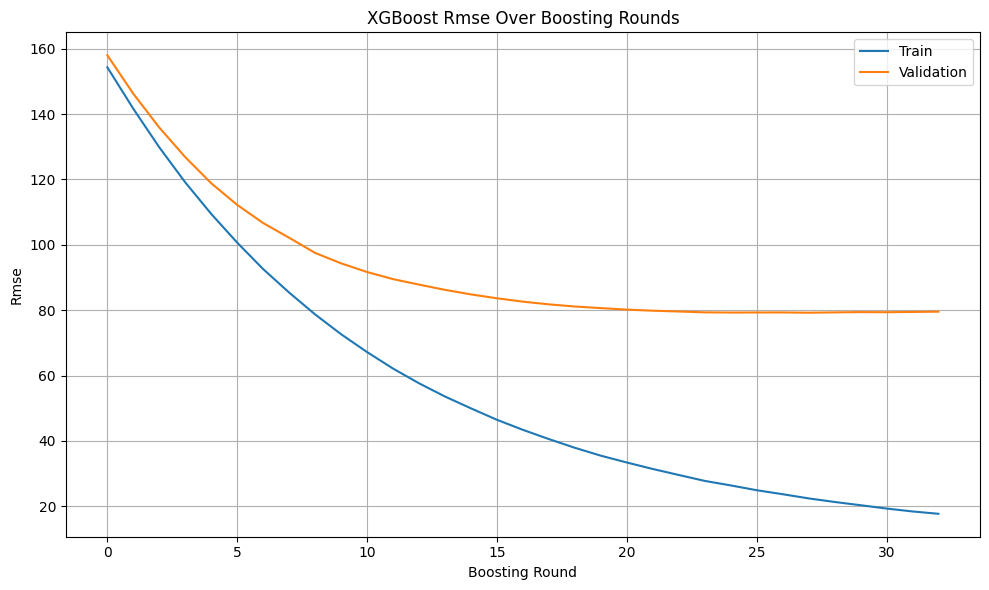

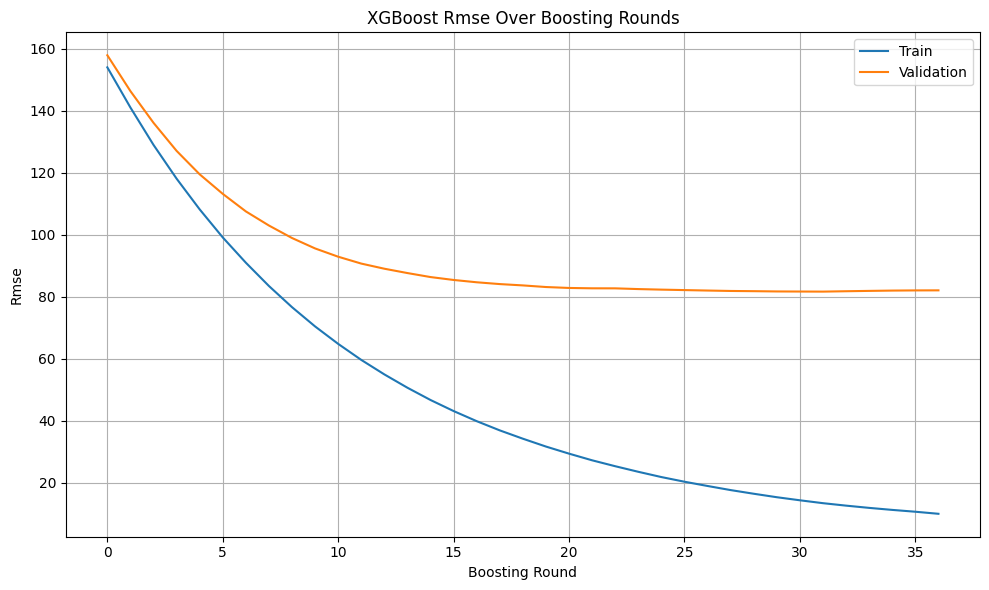

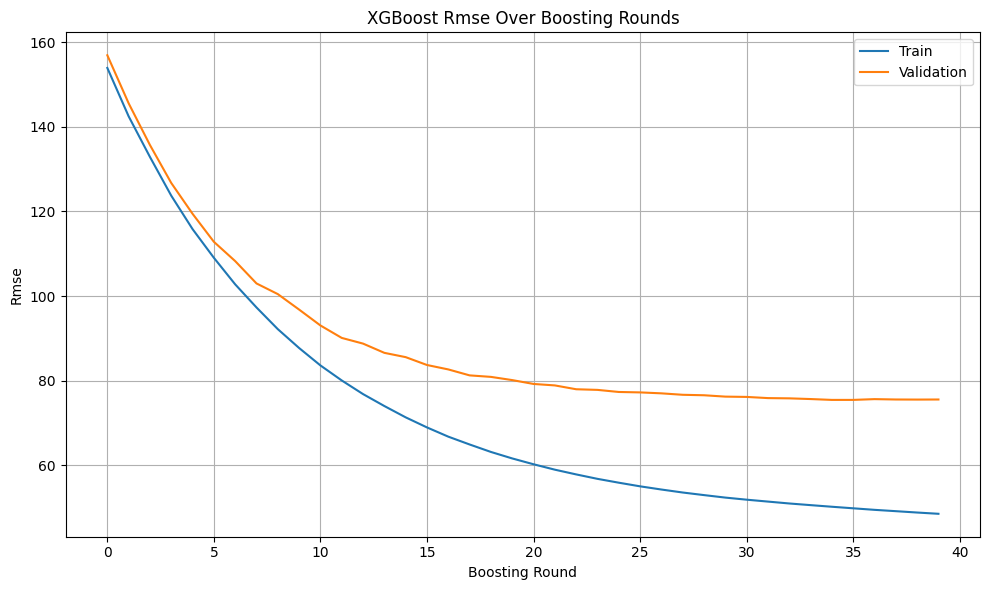

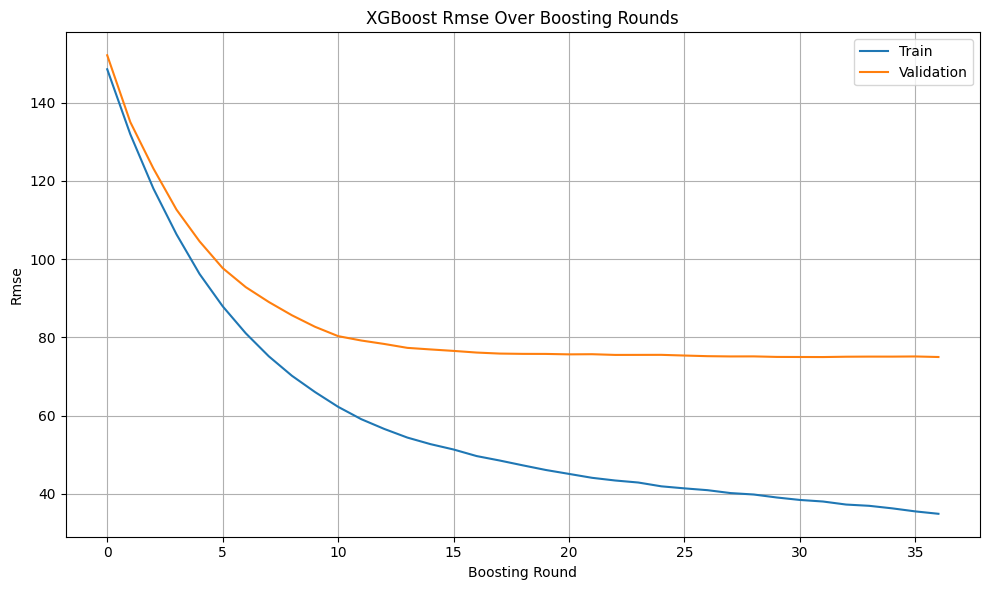

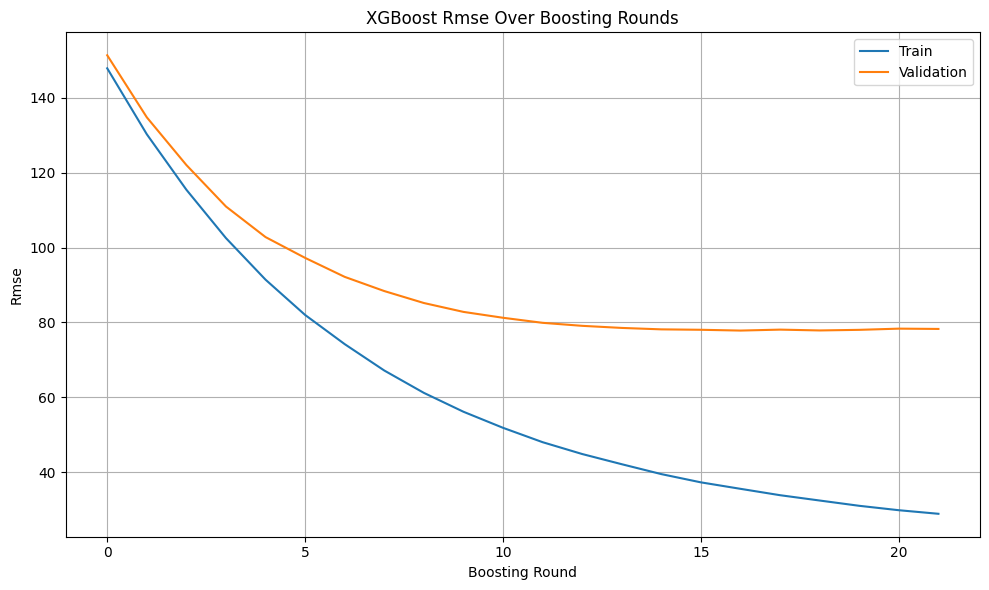

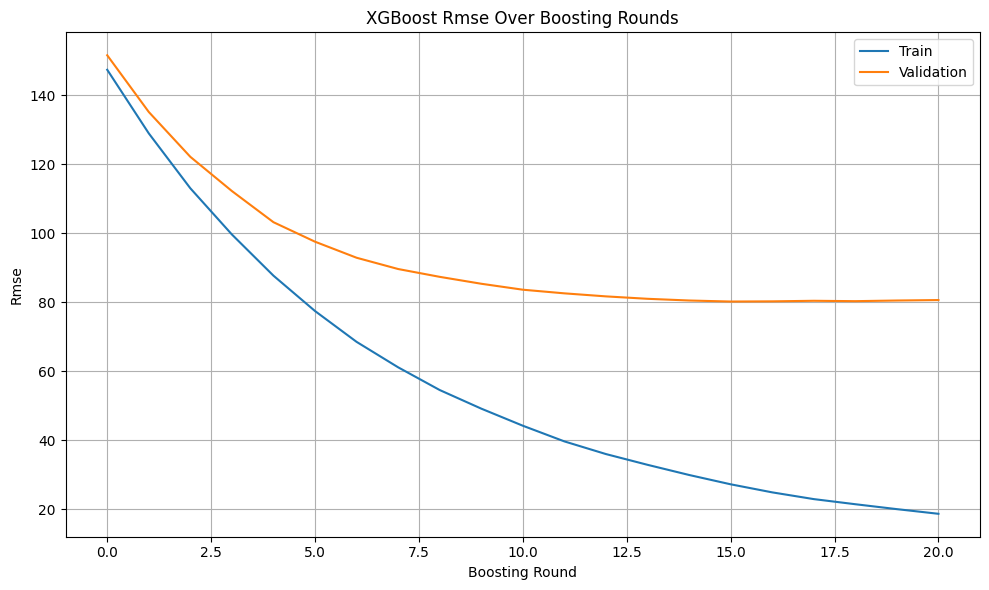

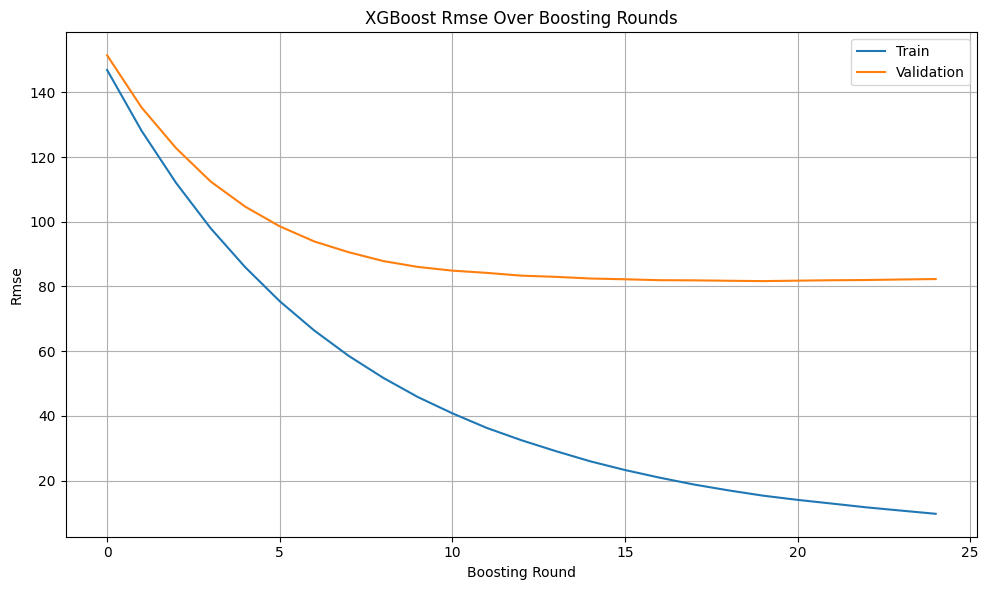

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\1052736820.py:22: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


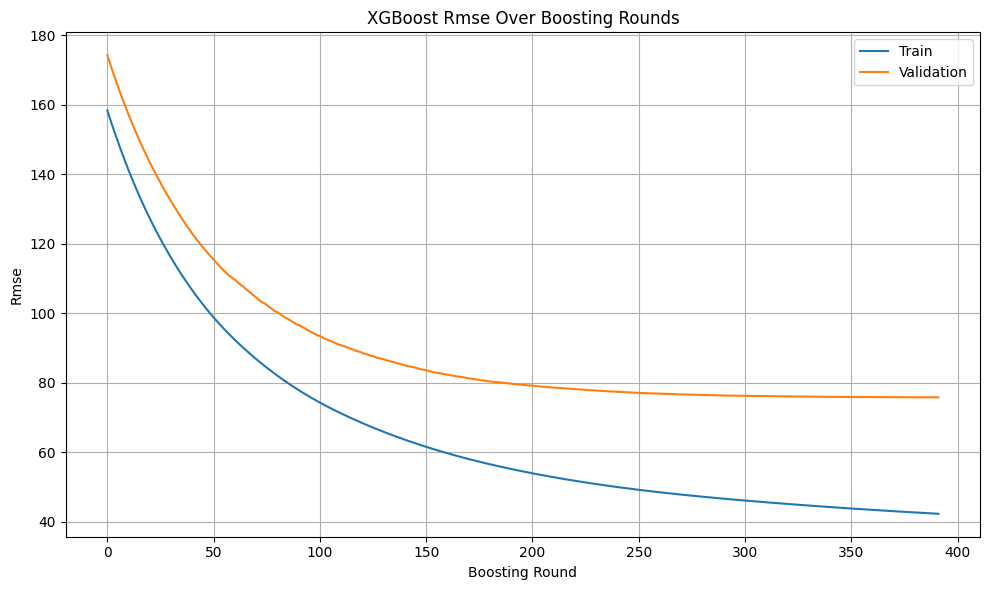

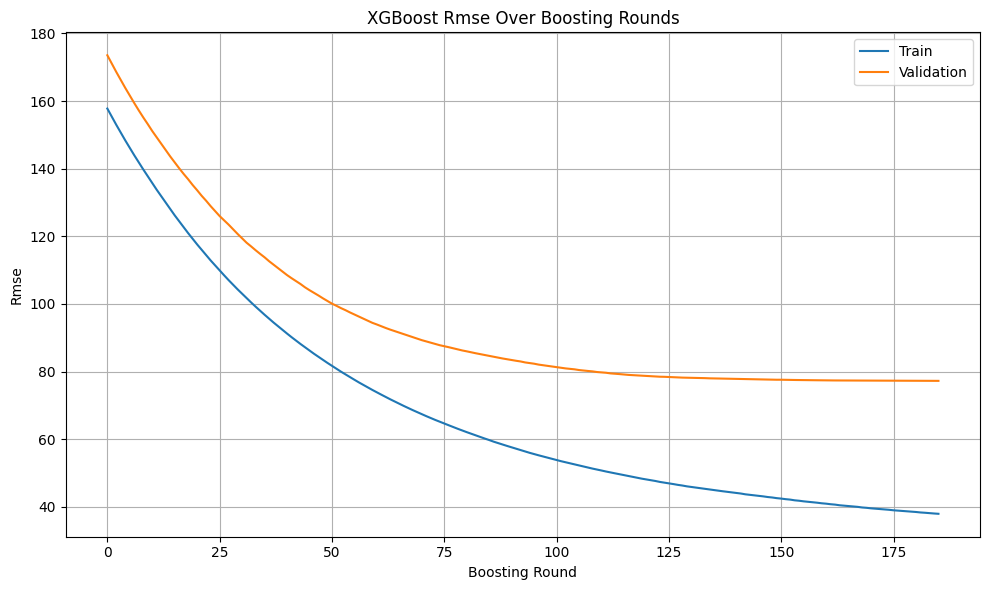

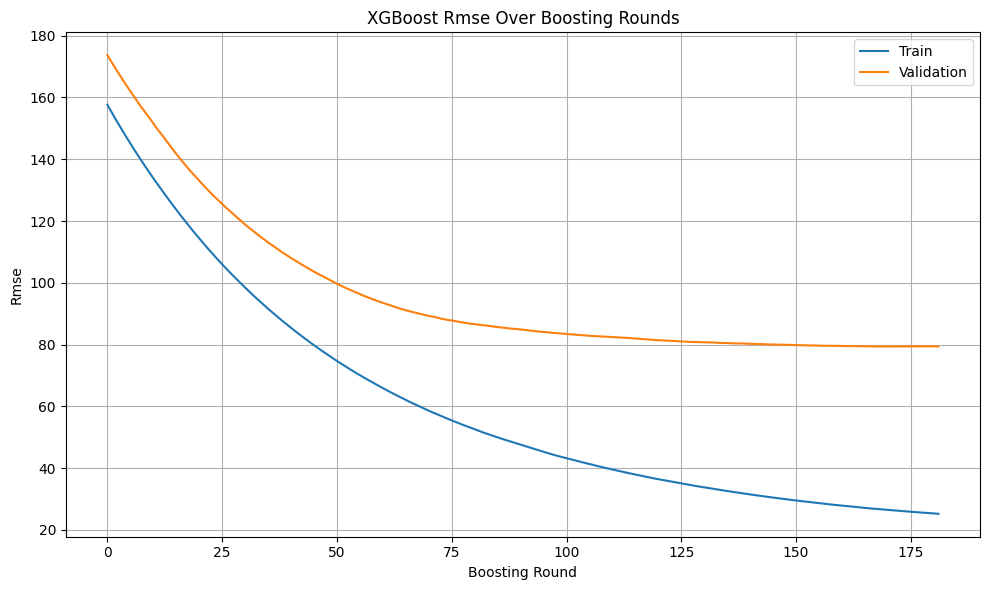

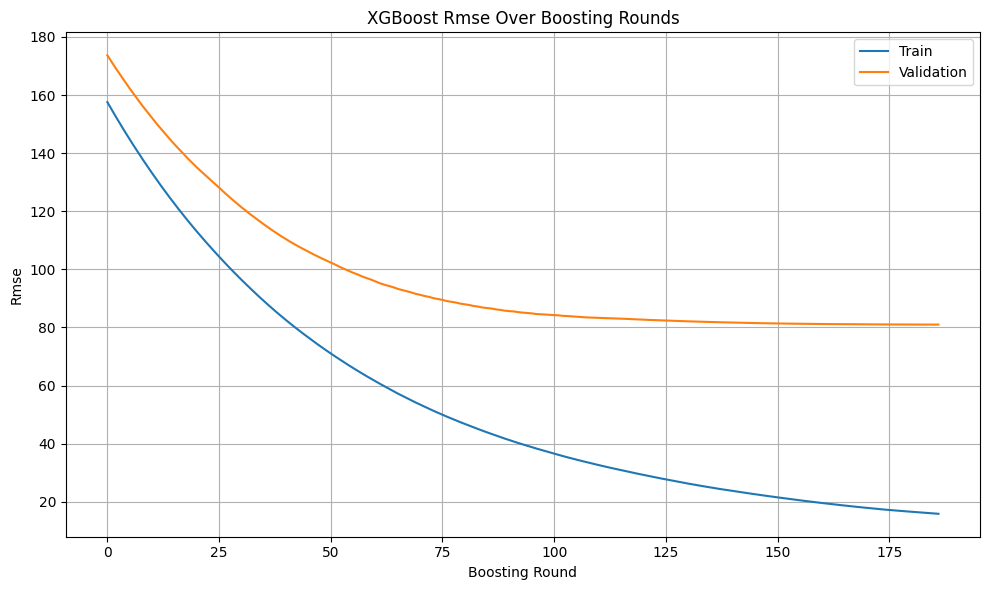

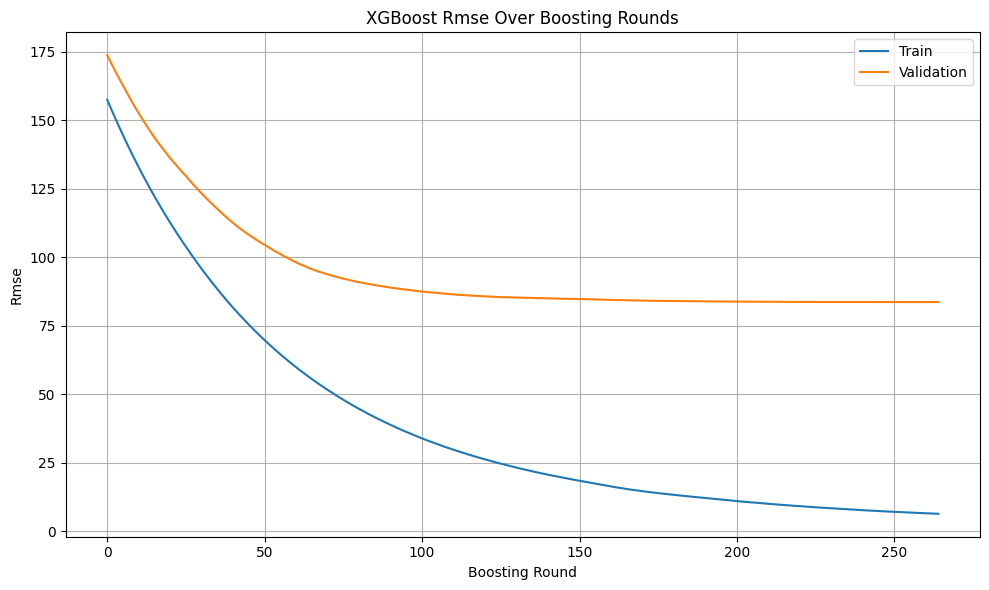

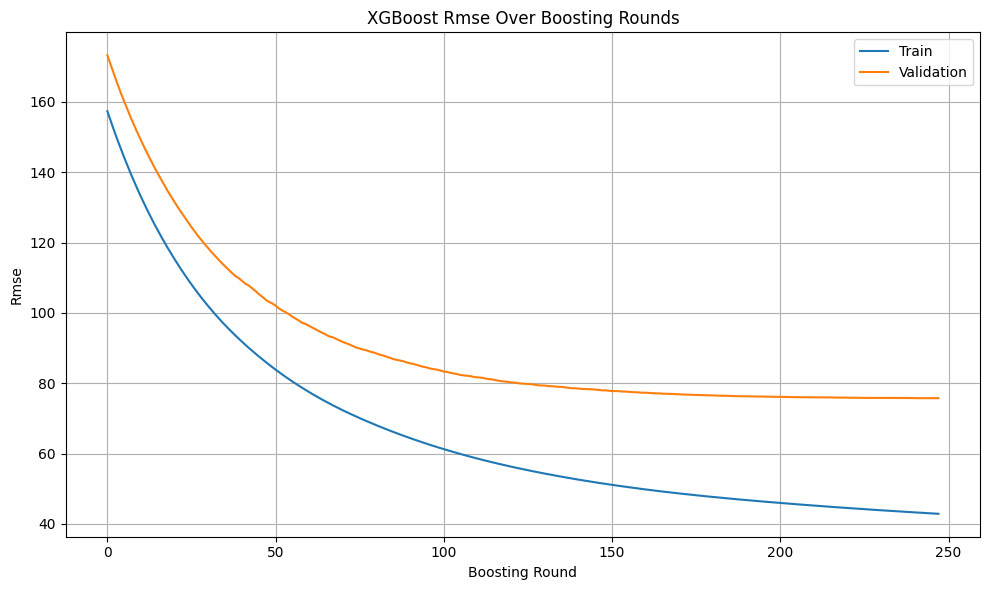

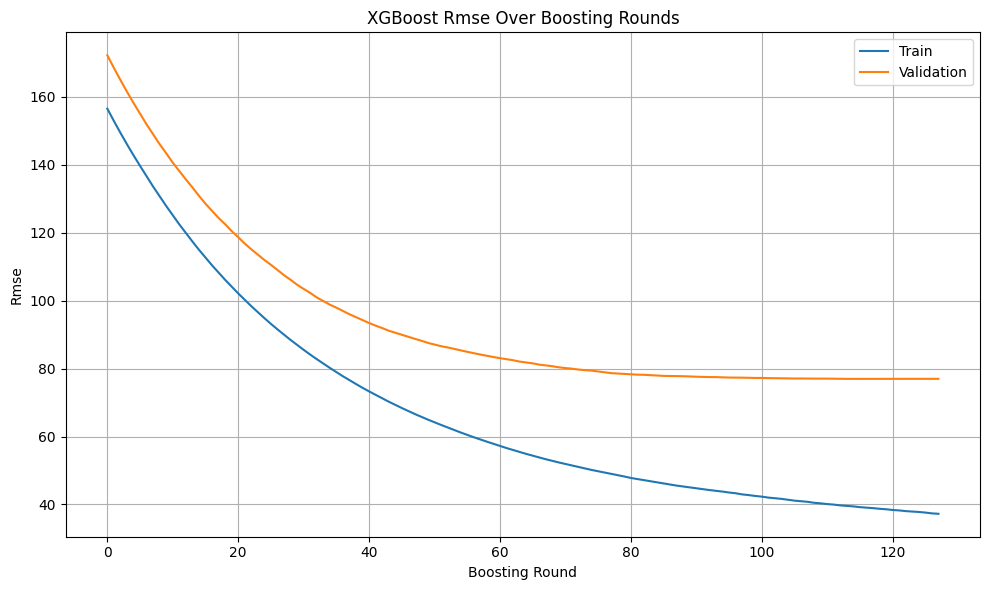

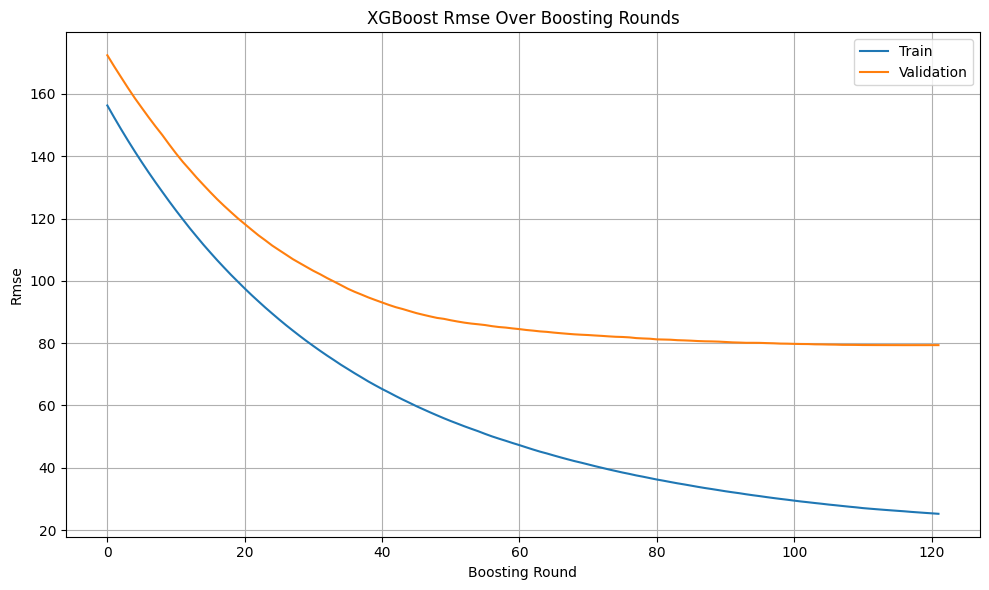

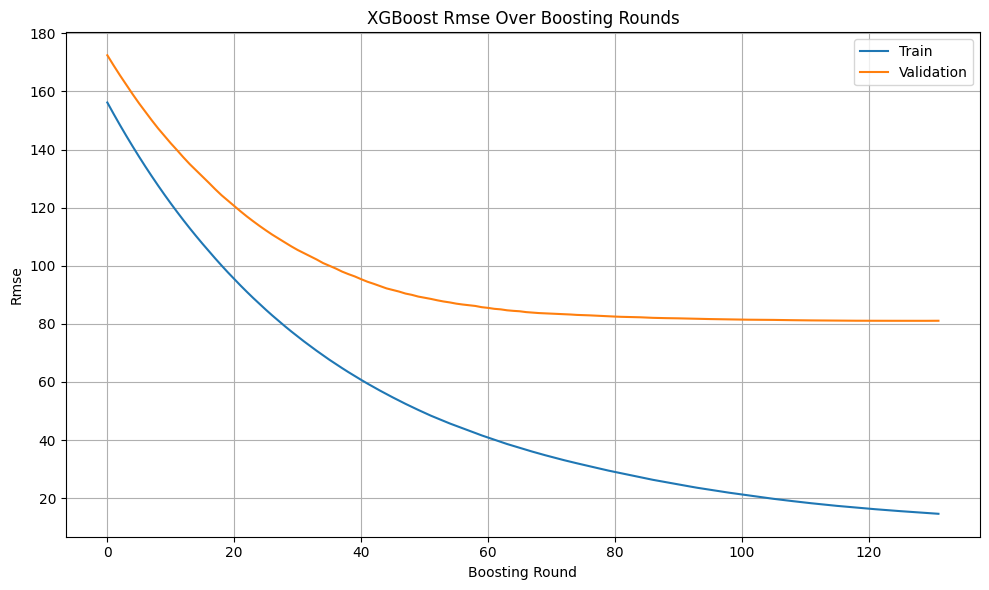

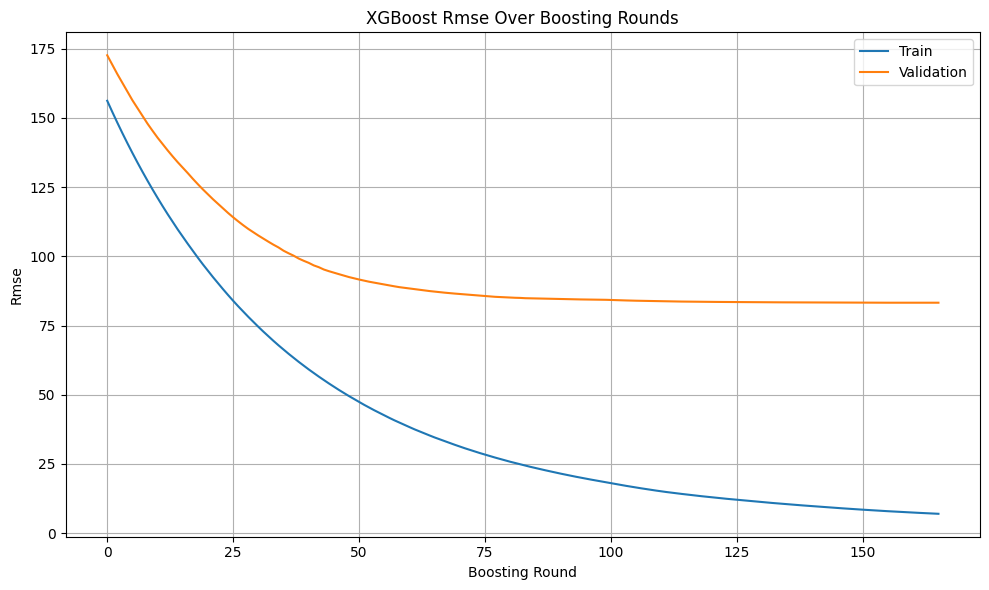

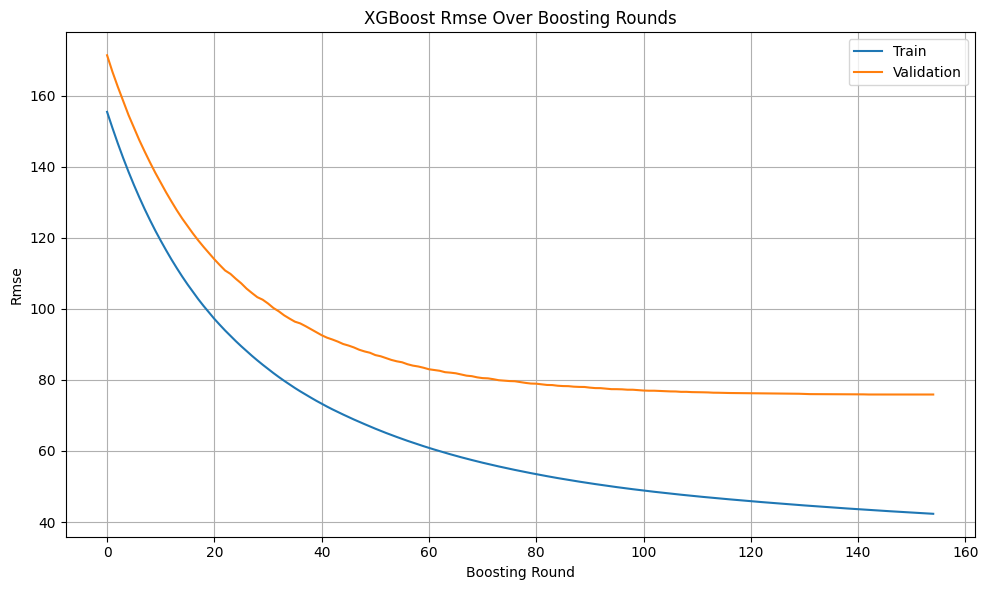

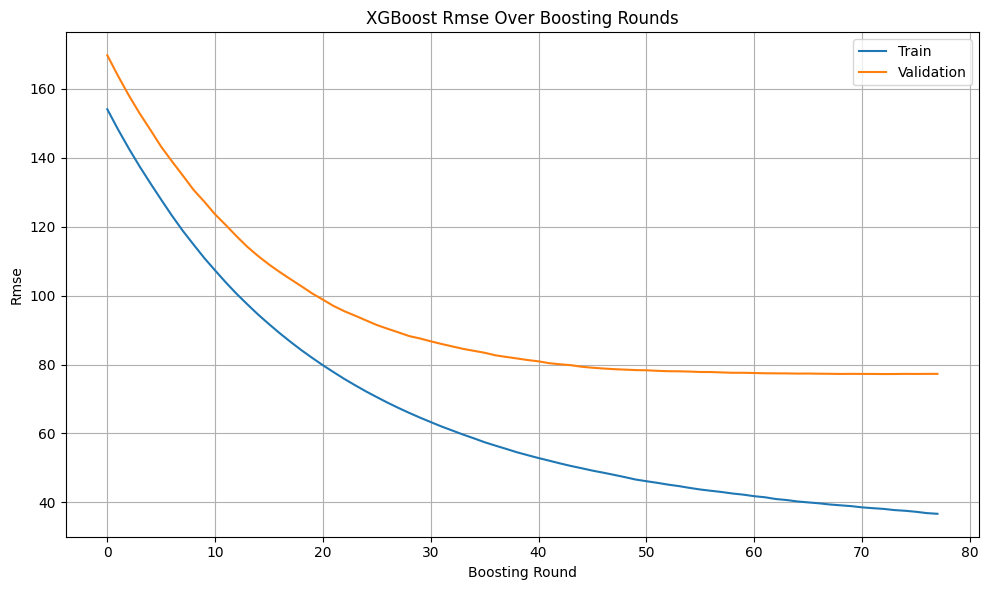

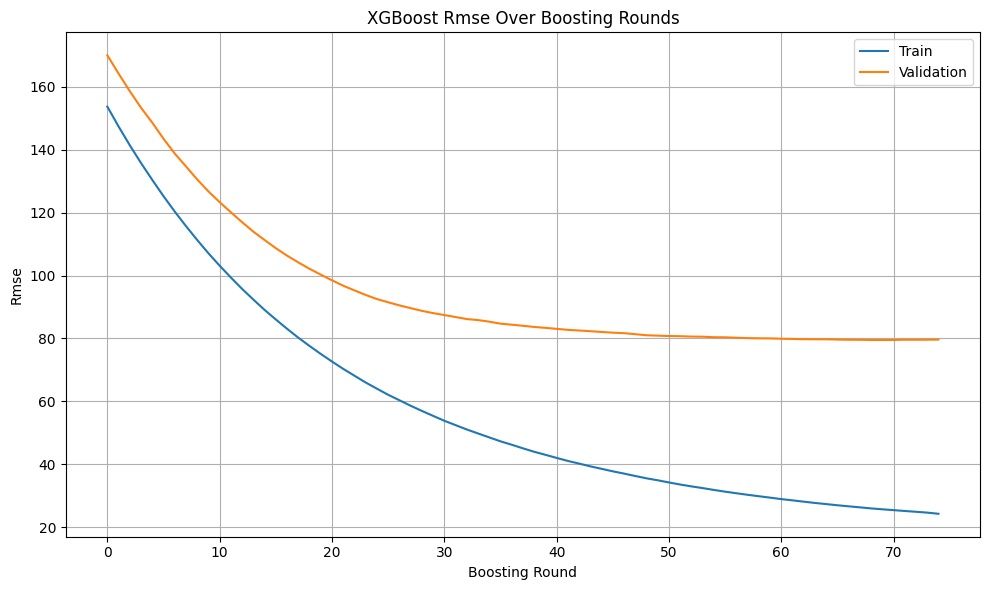

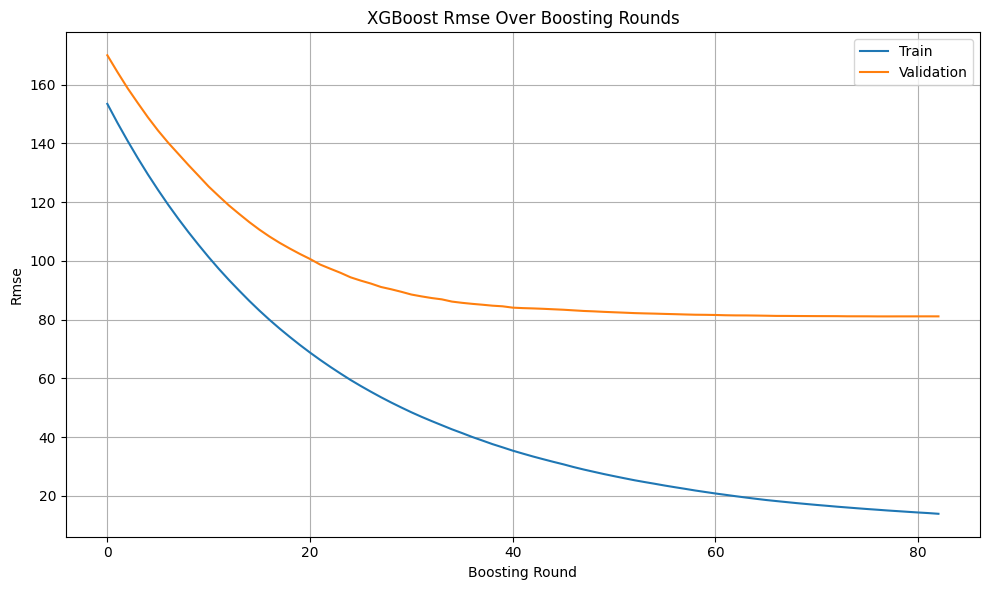

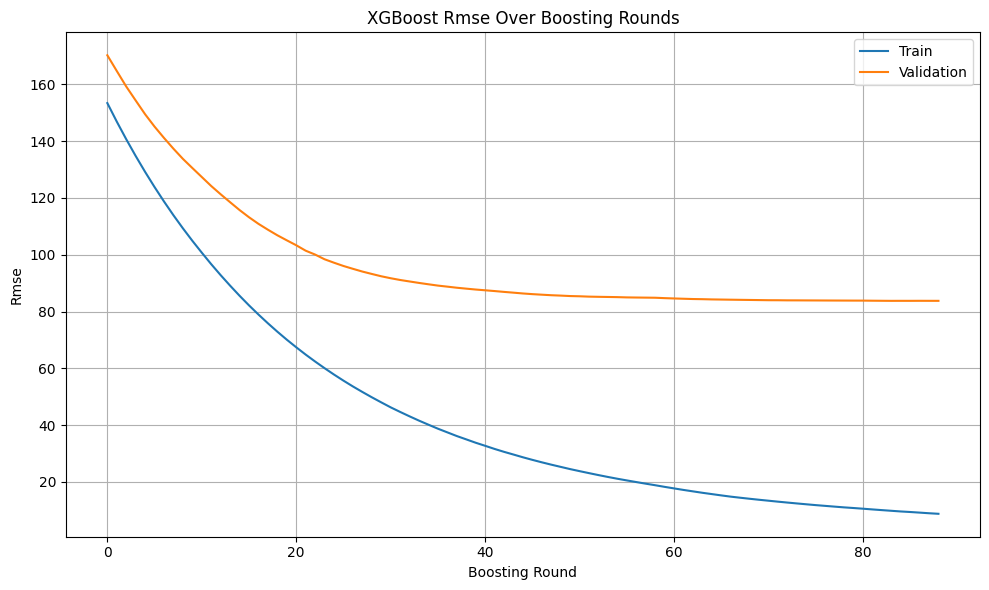

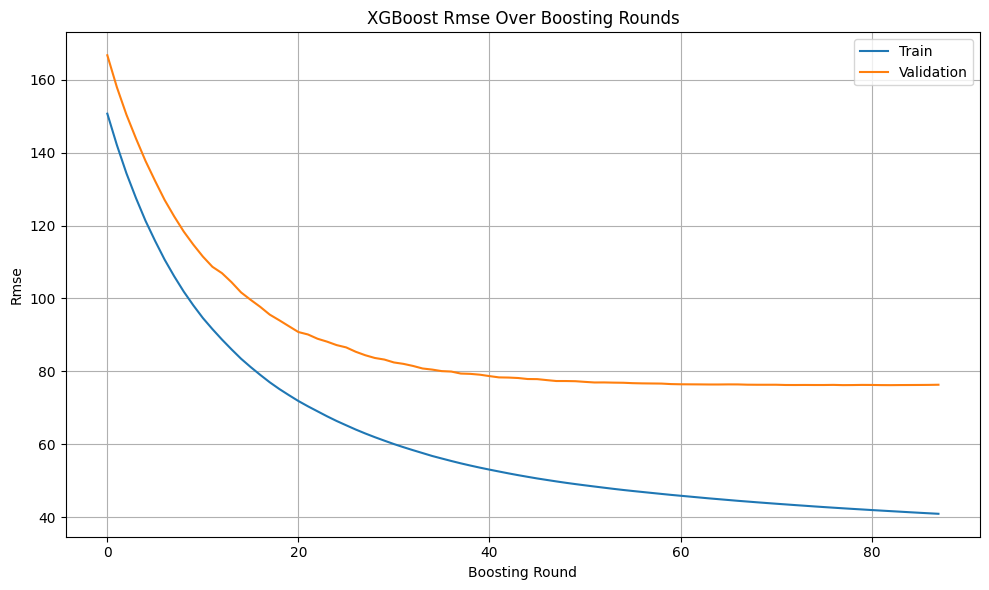

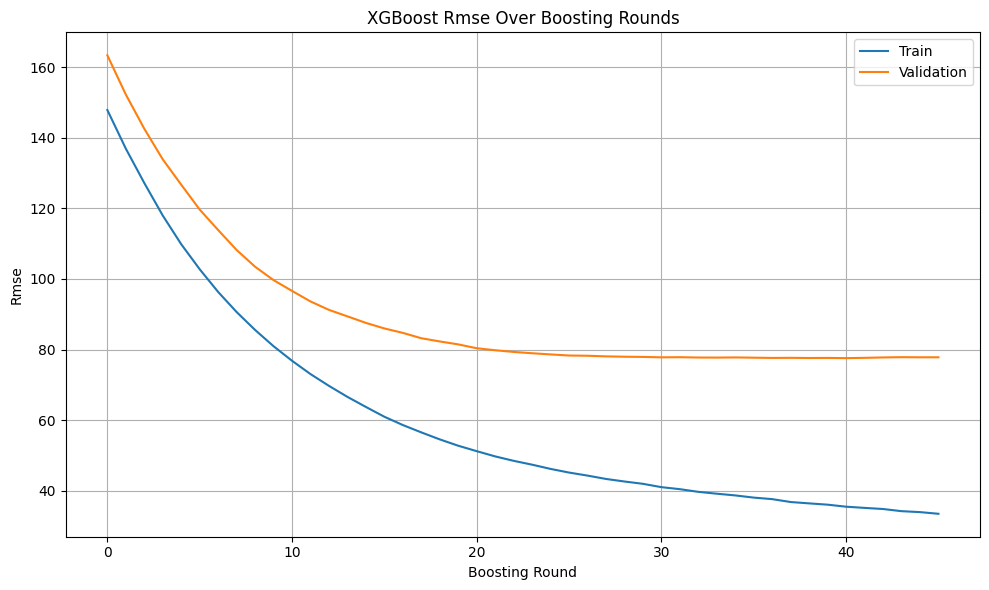

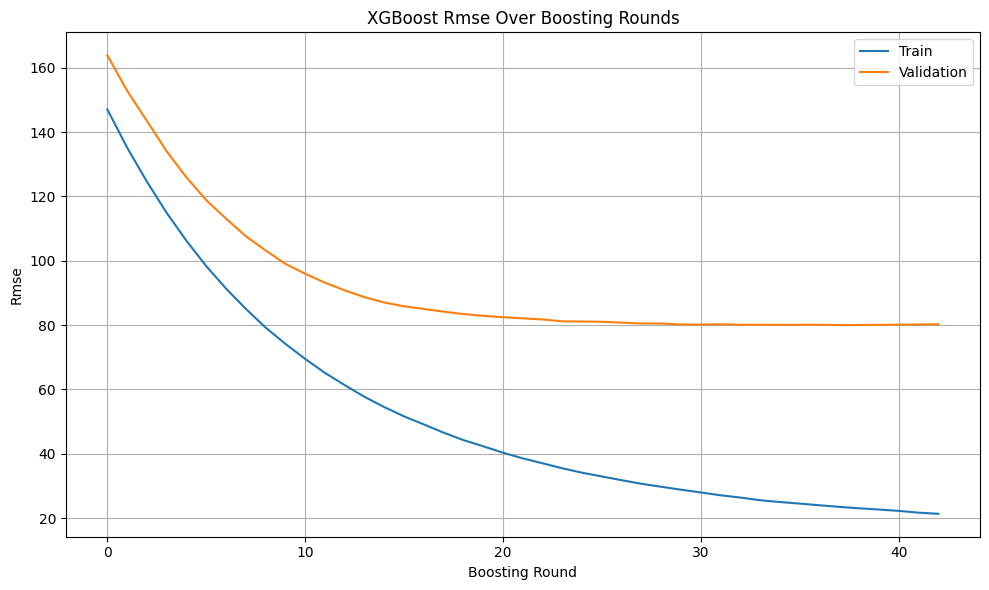

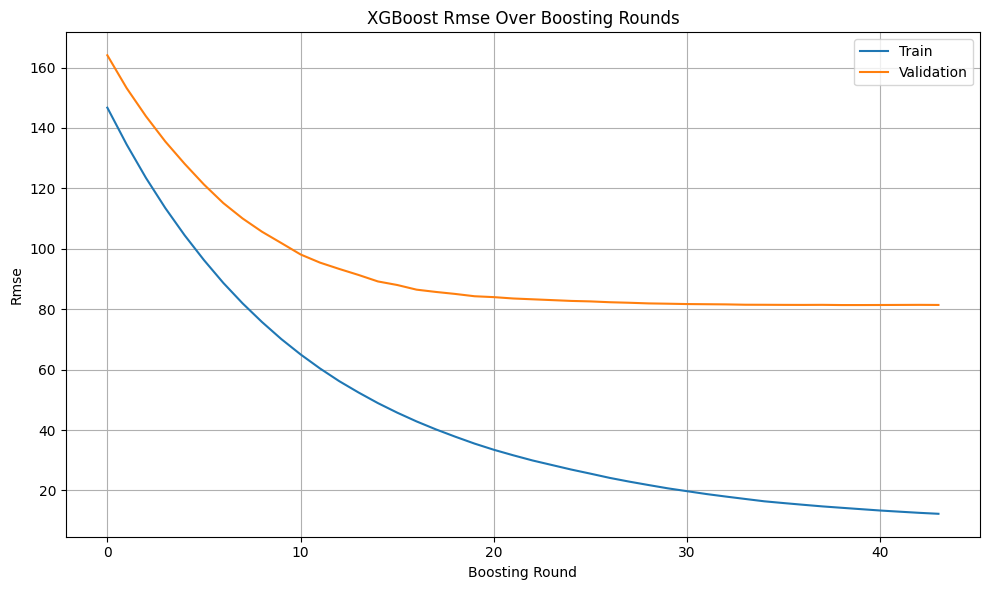

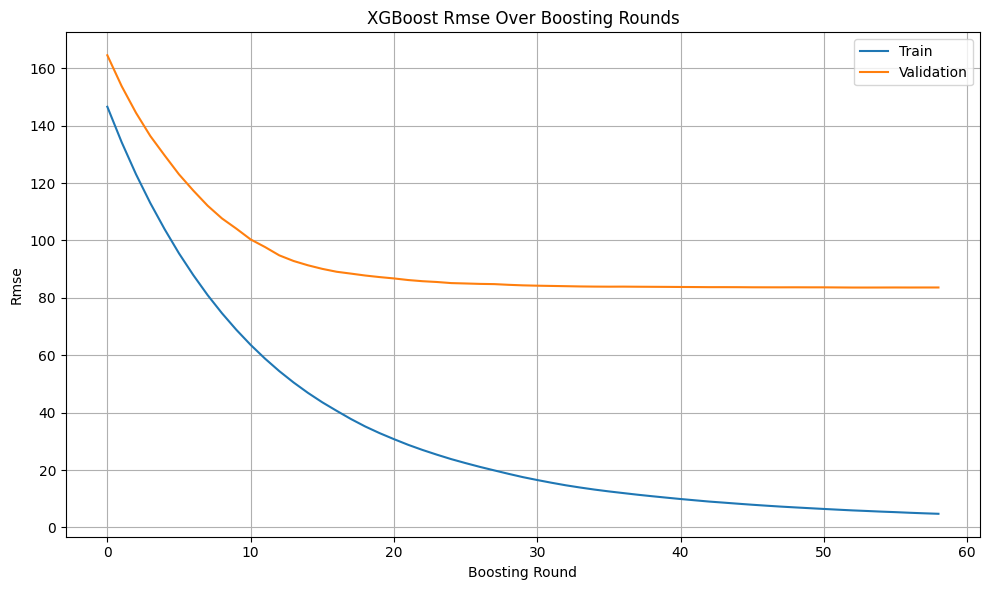

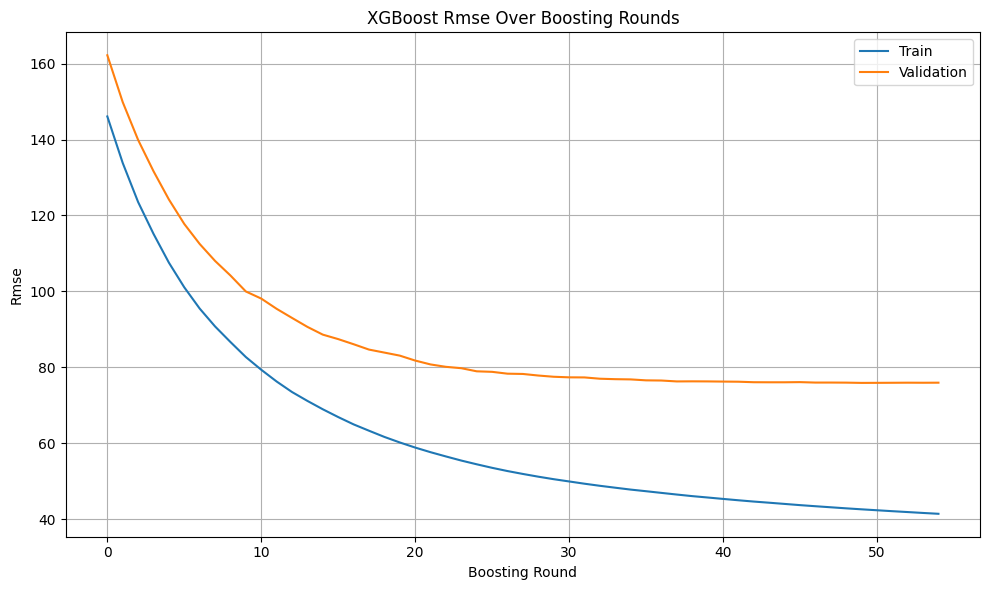

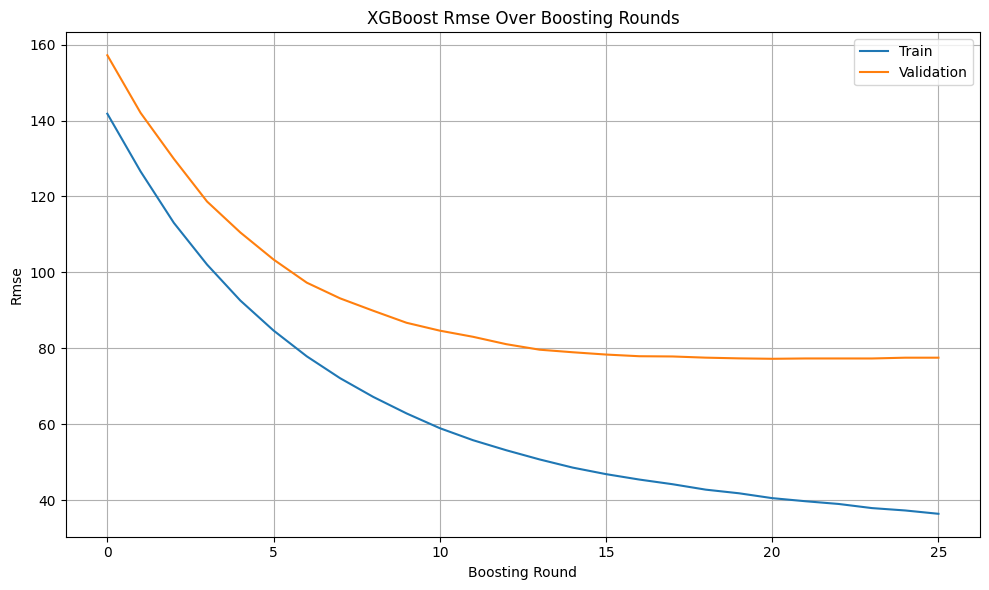

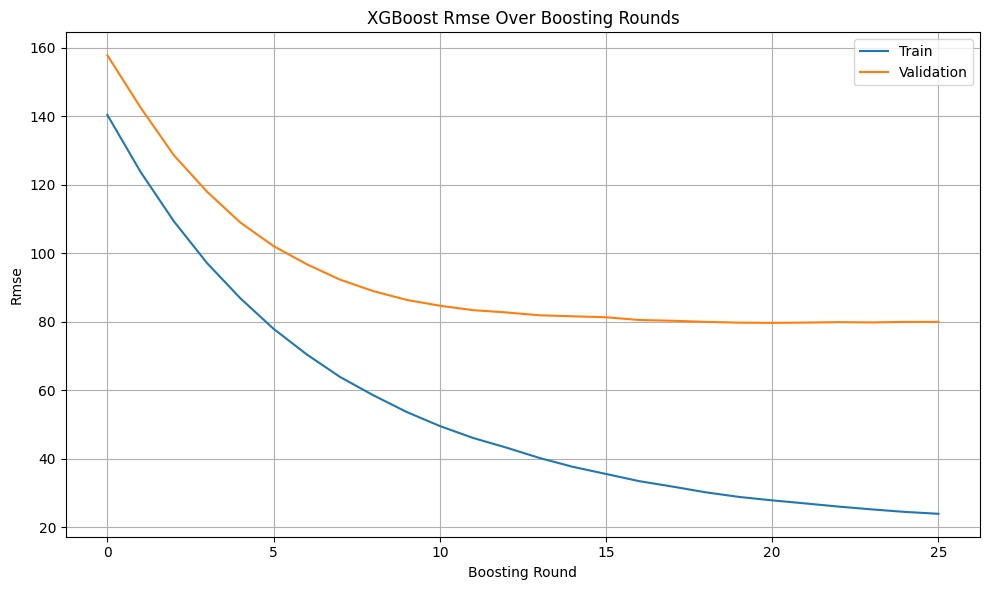

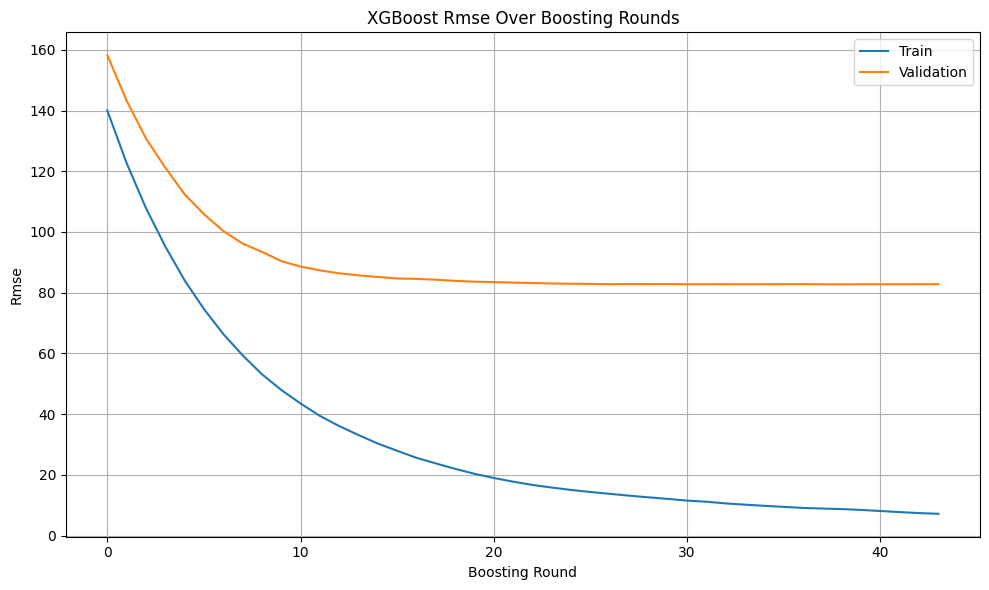

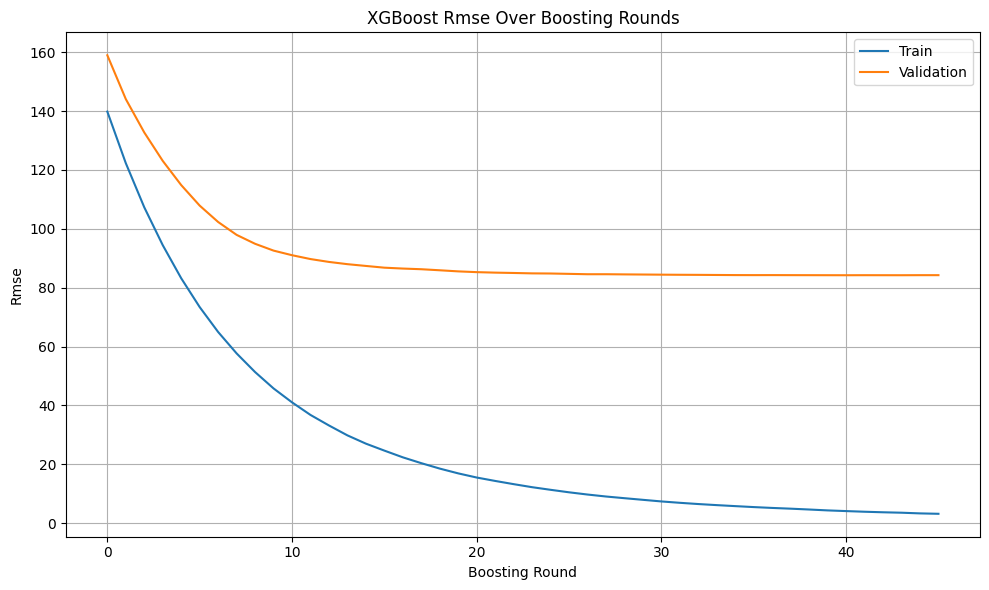

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_3784\1052736820.py:22: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',


131 890 890


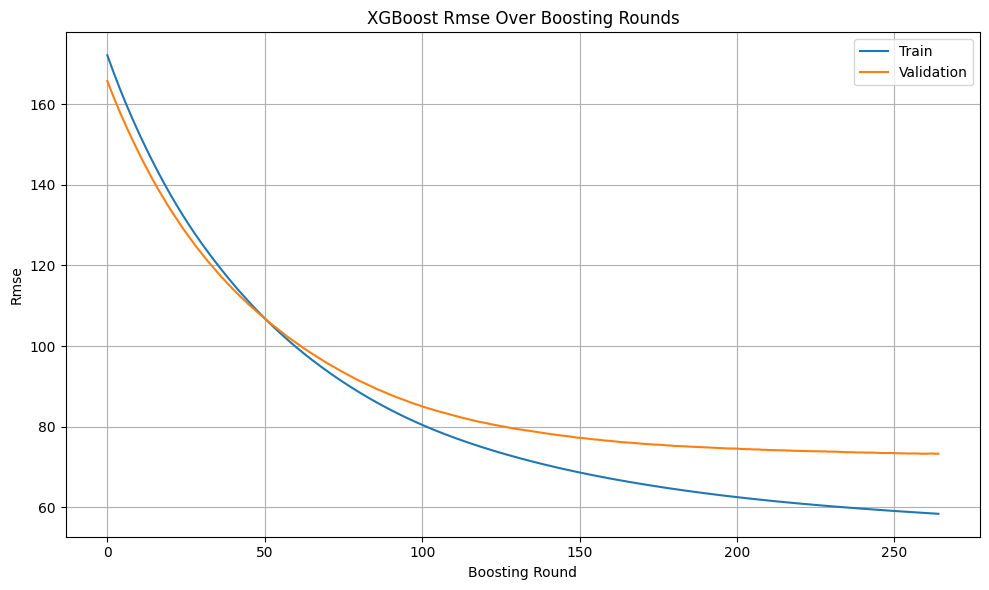

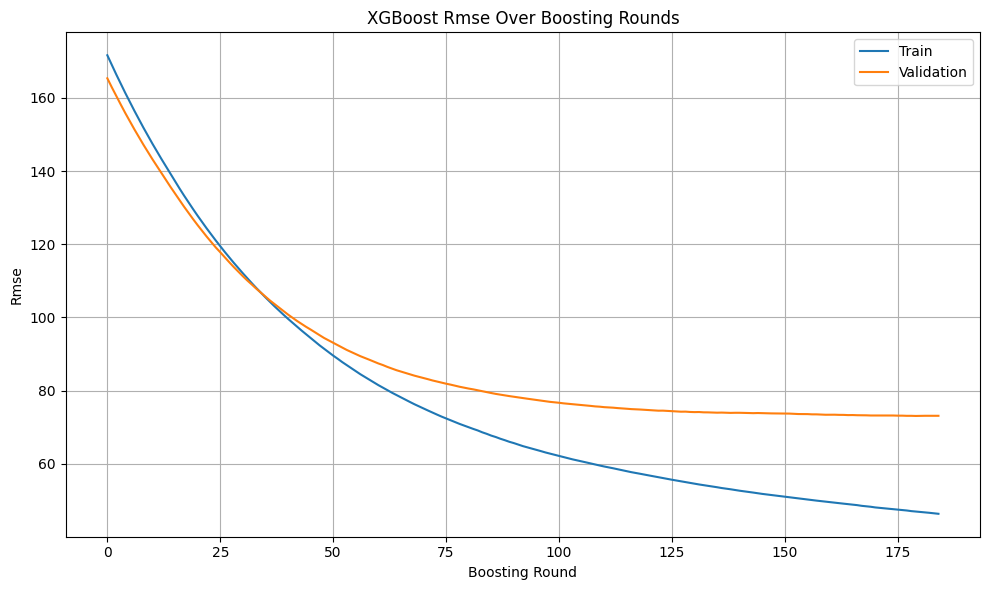

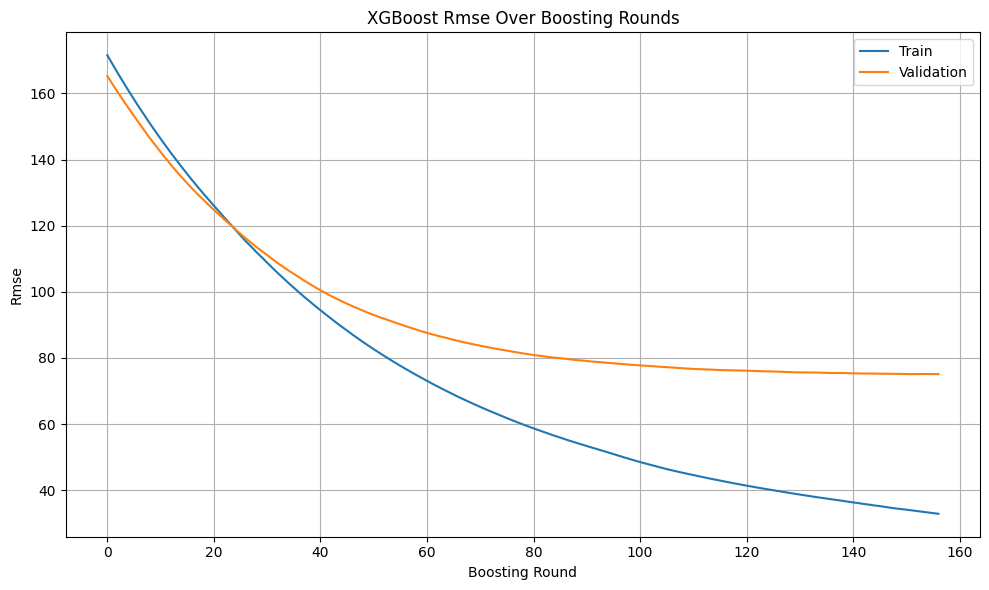

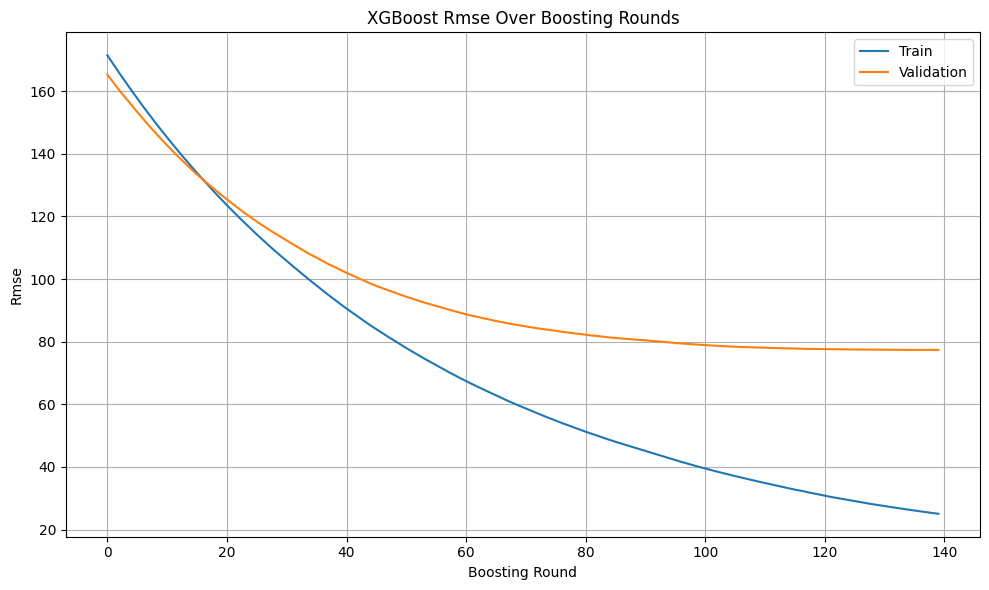

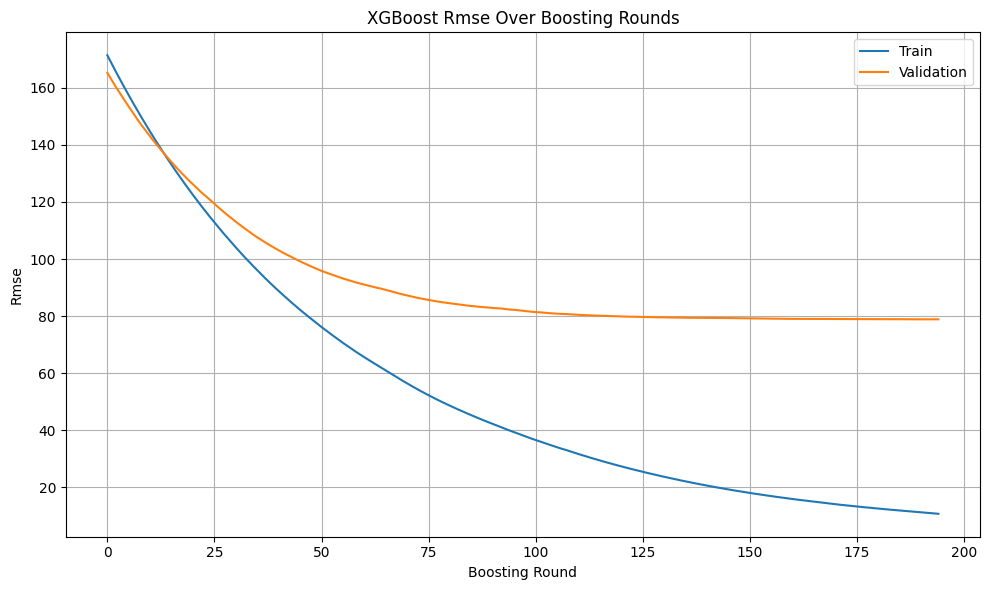

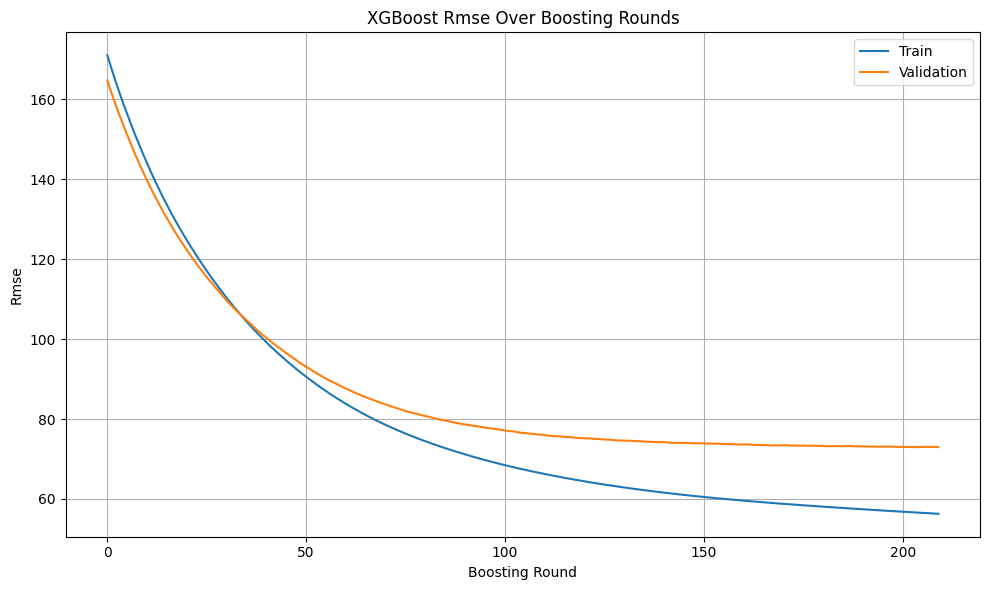

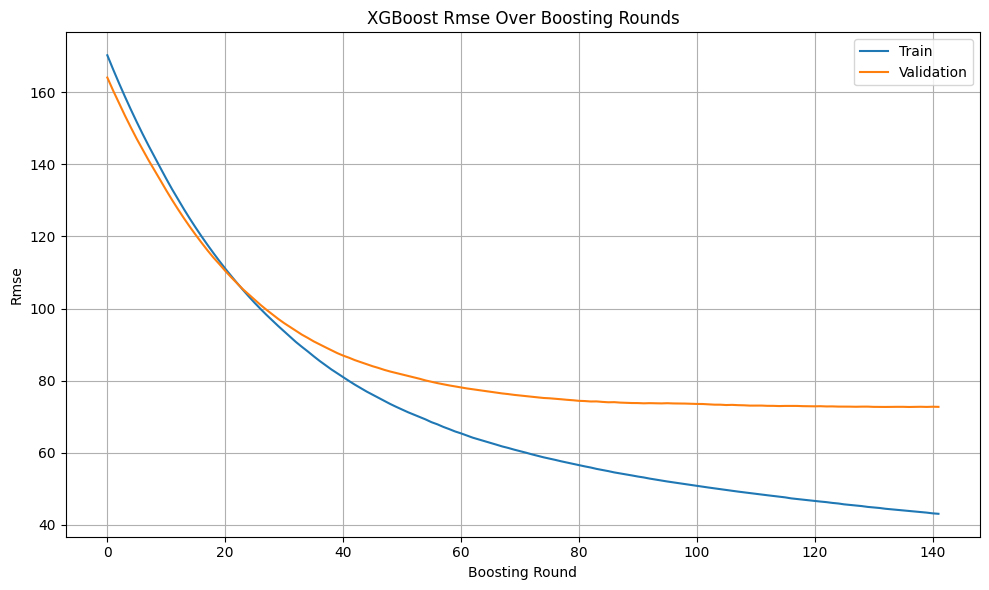

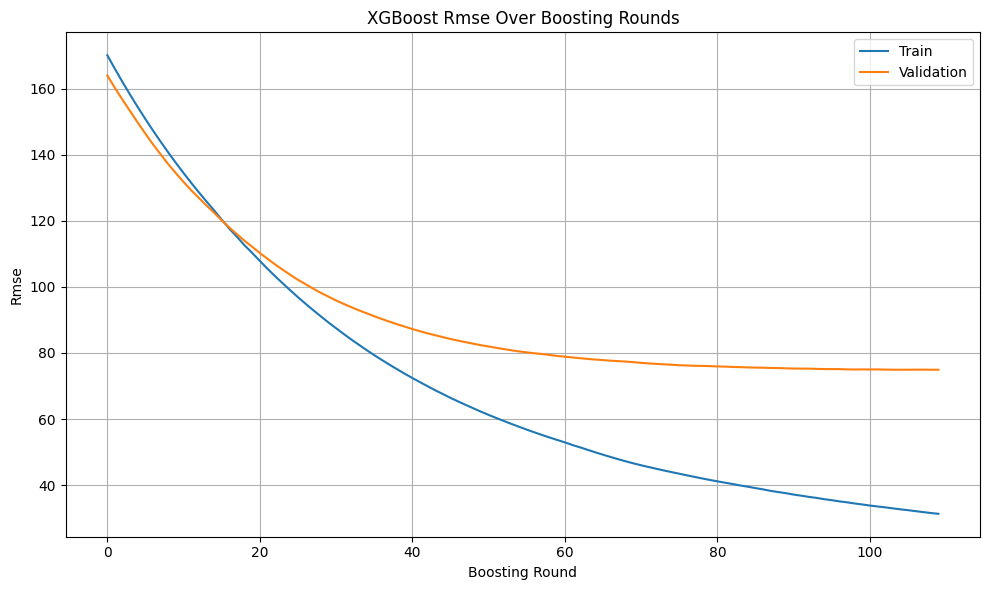

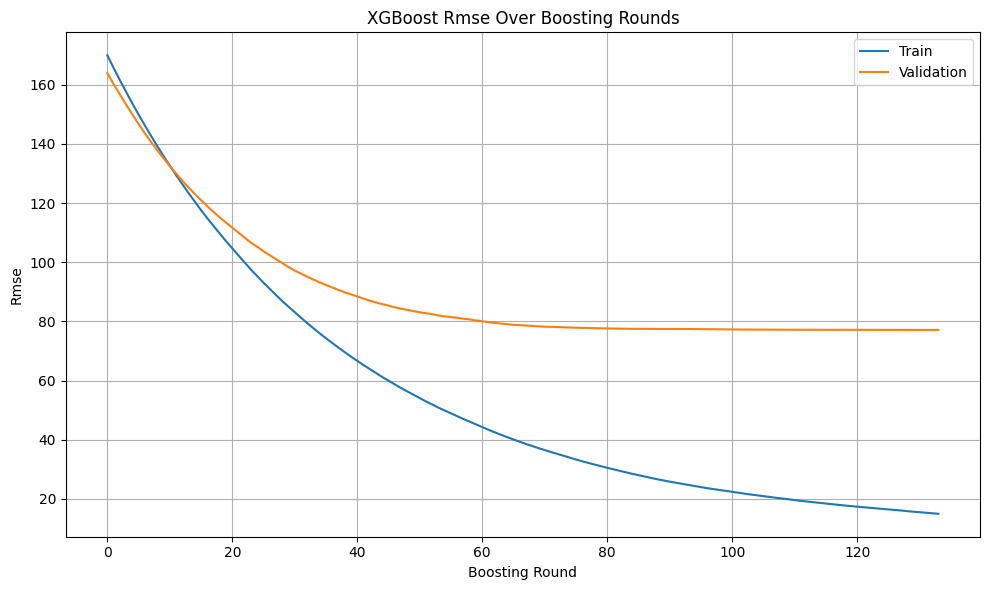

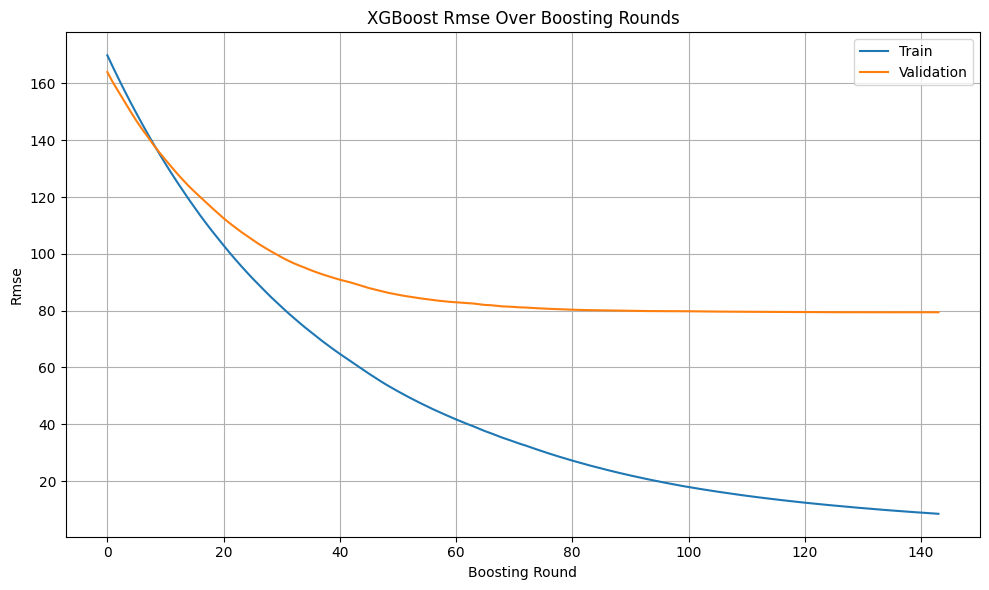

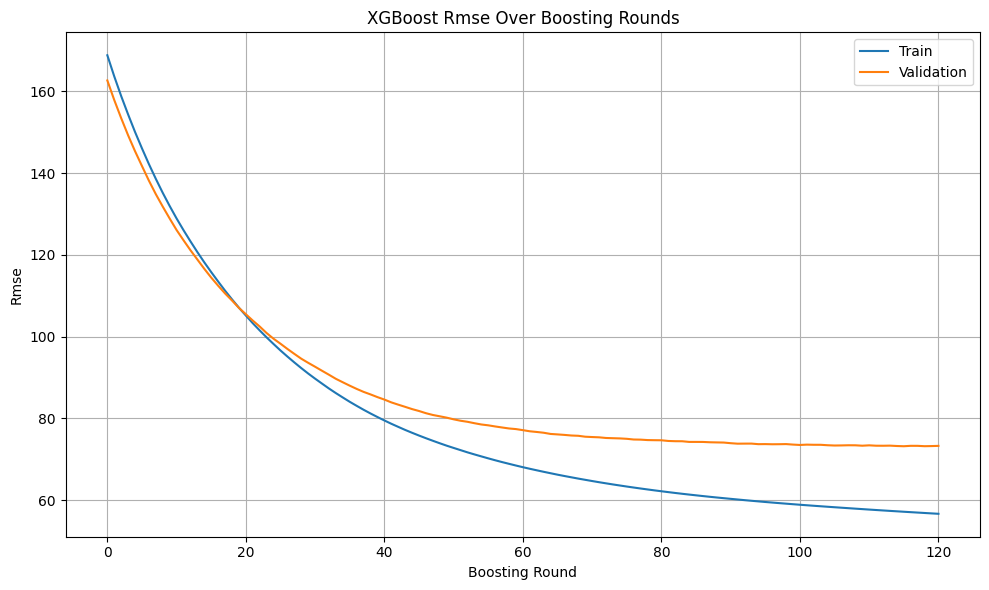

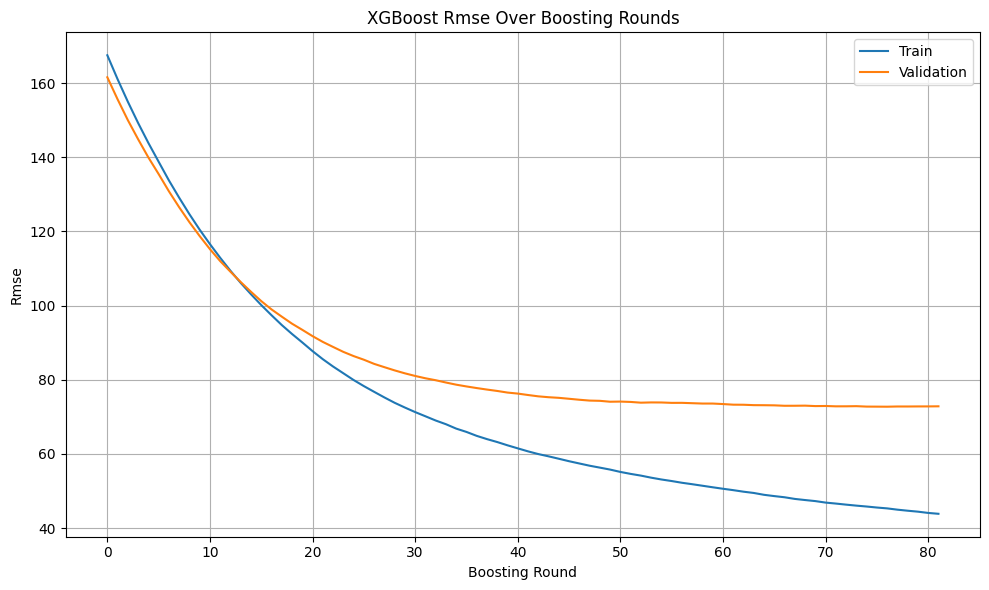

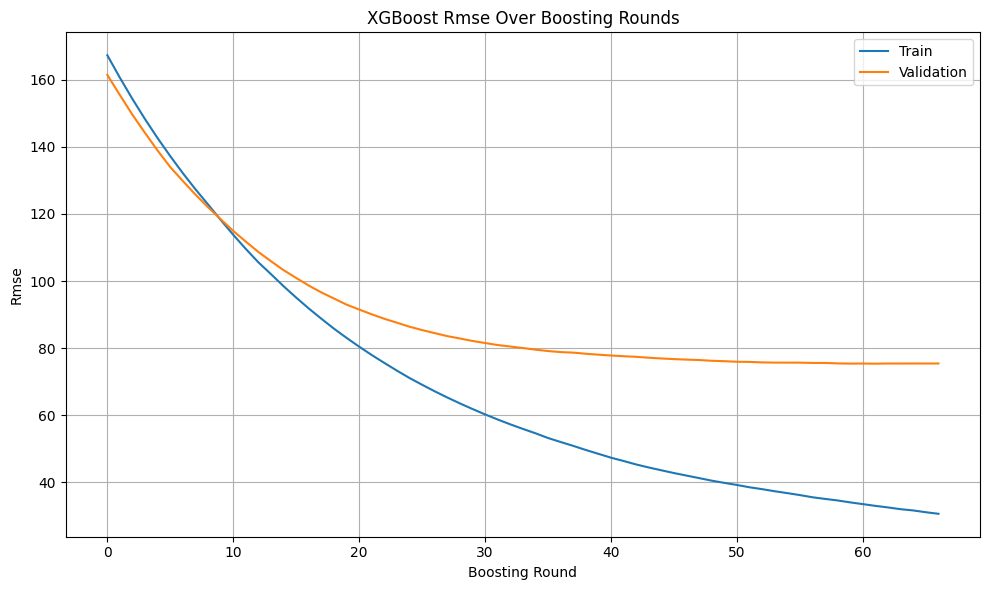

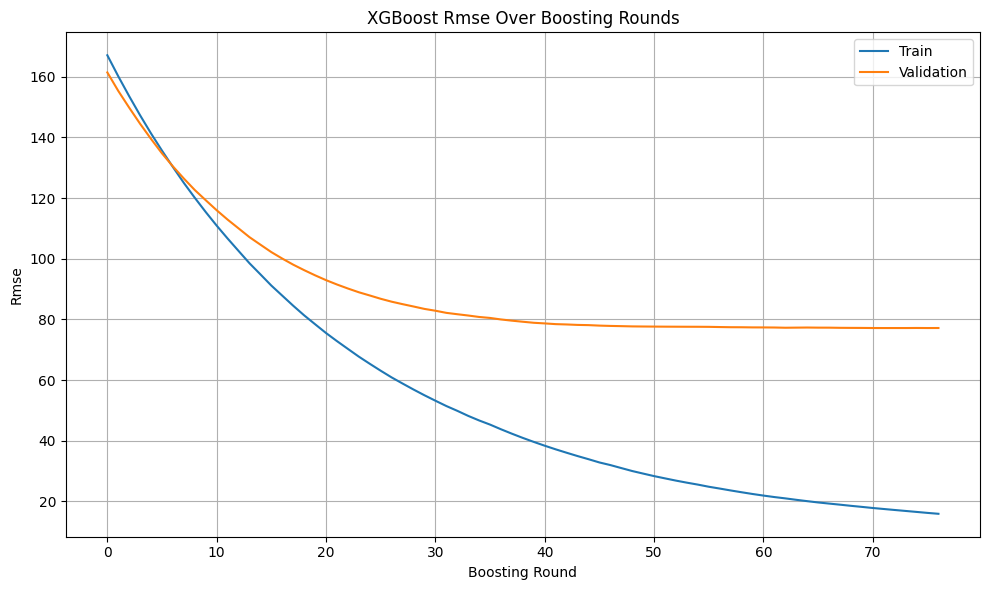

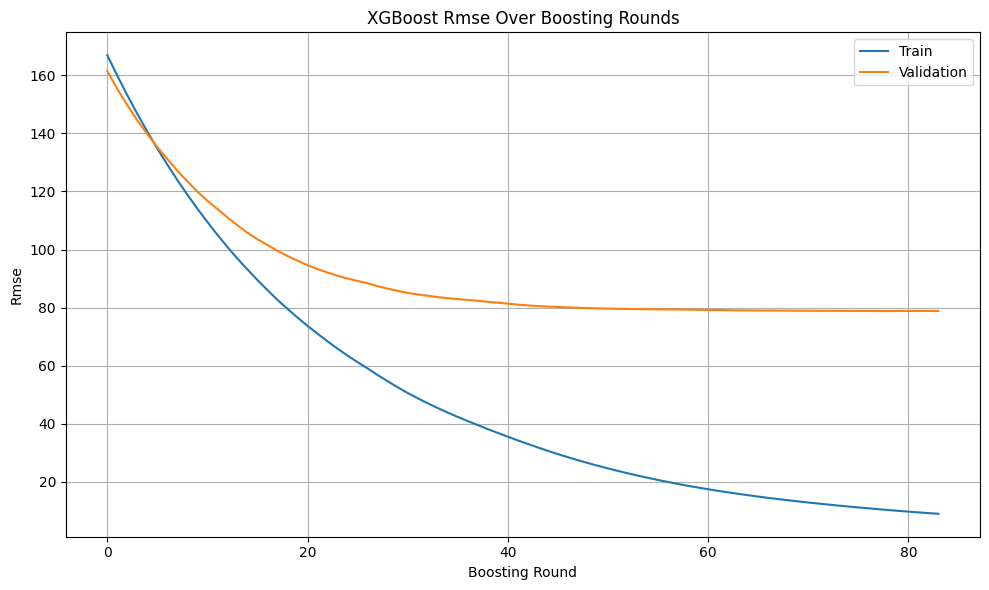

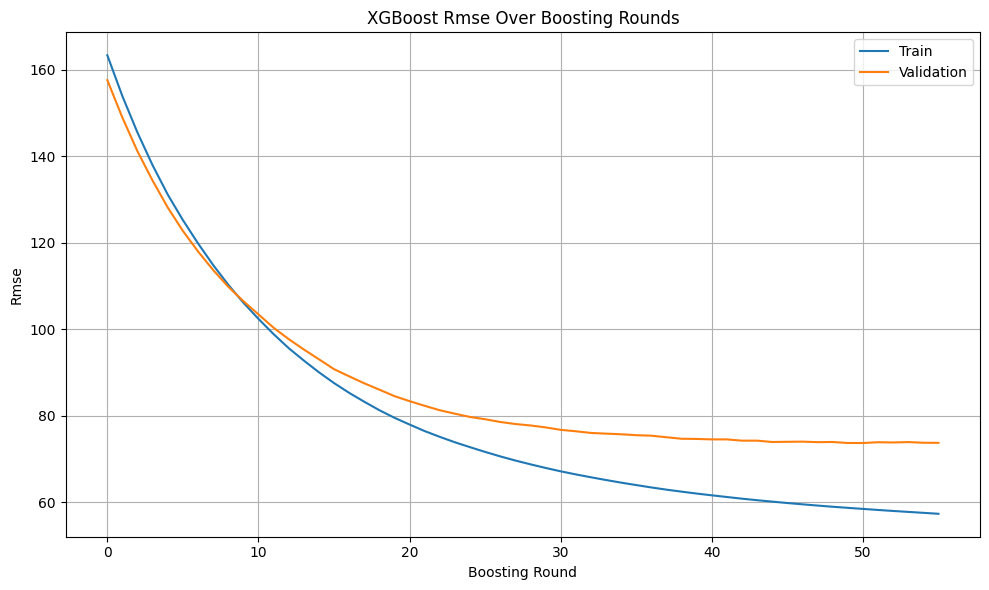

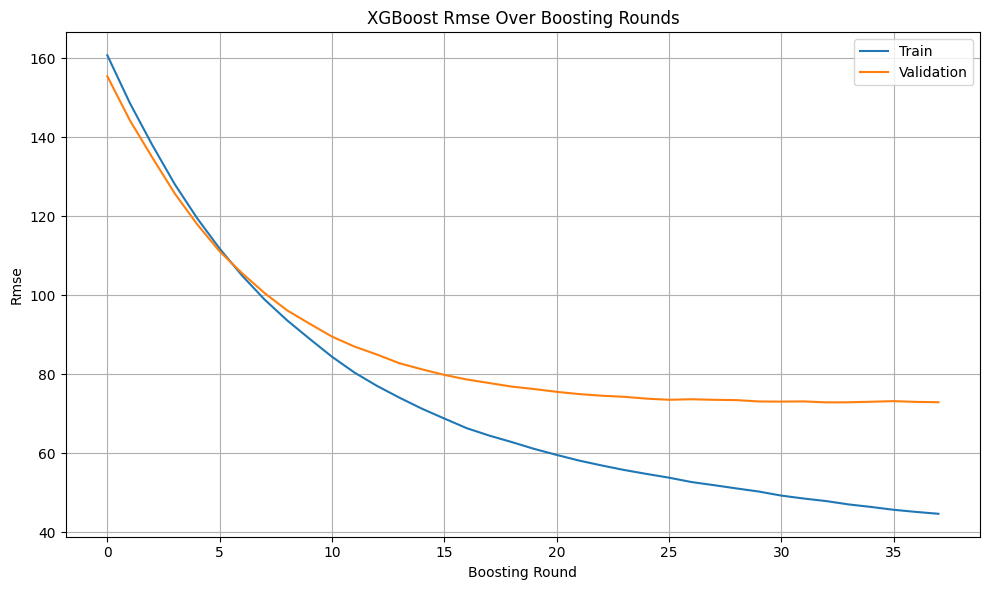

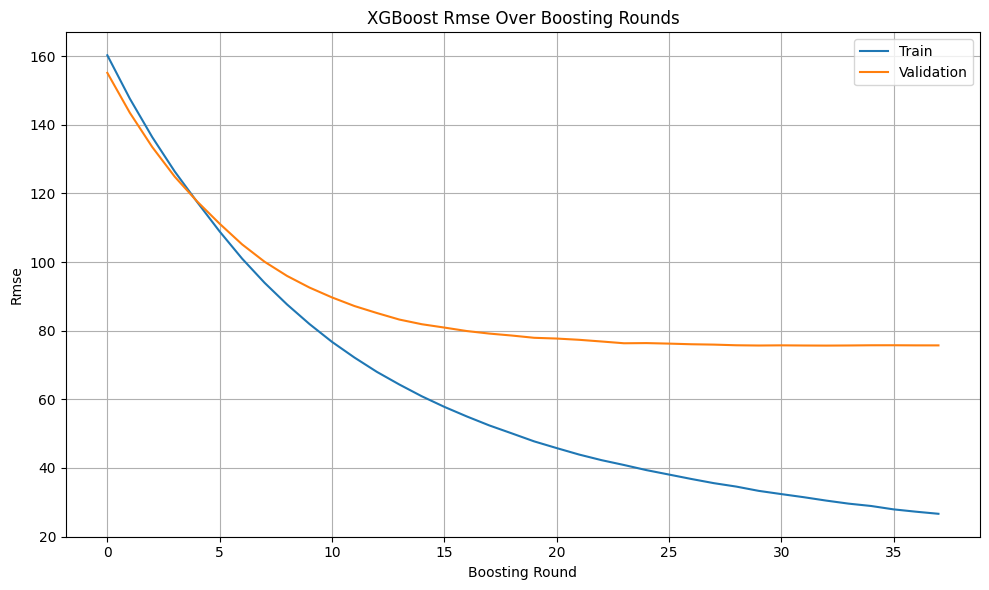

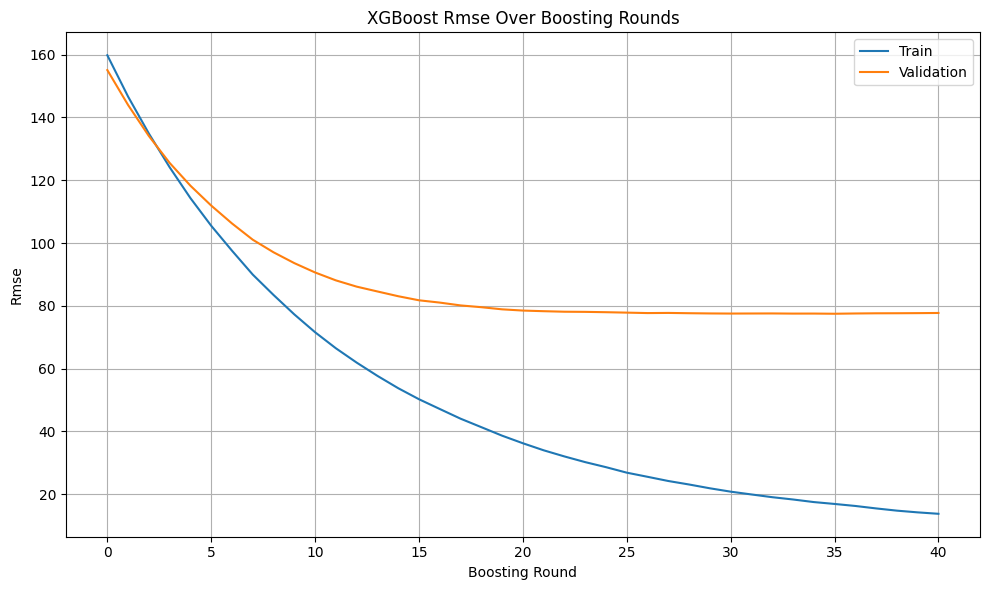

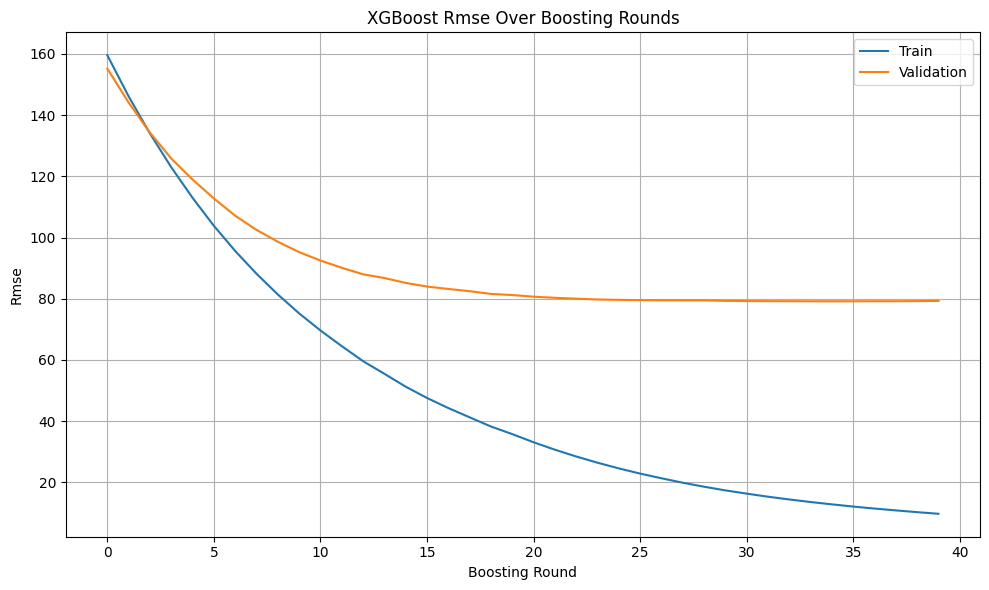

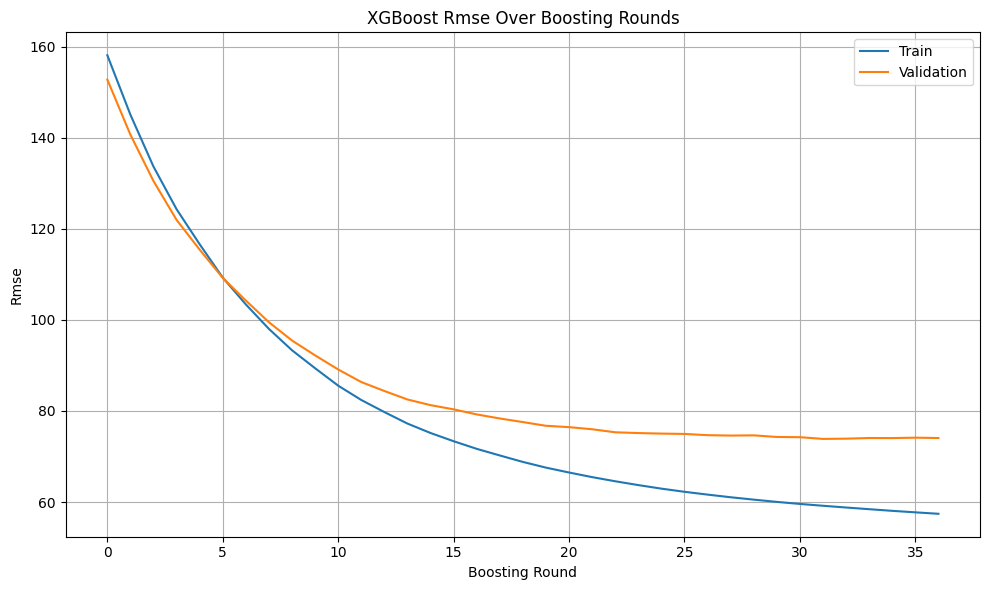

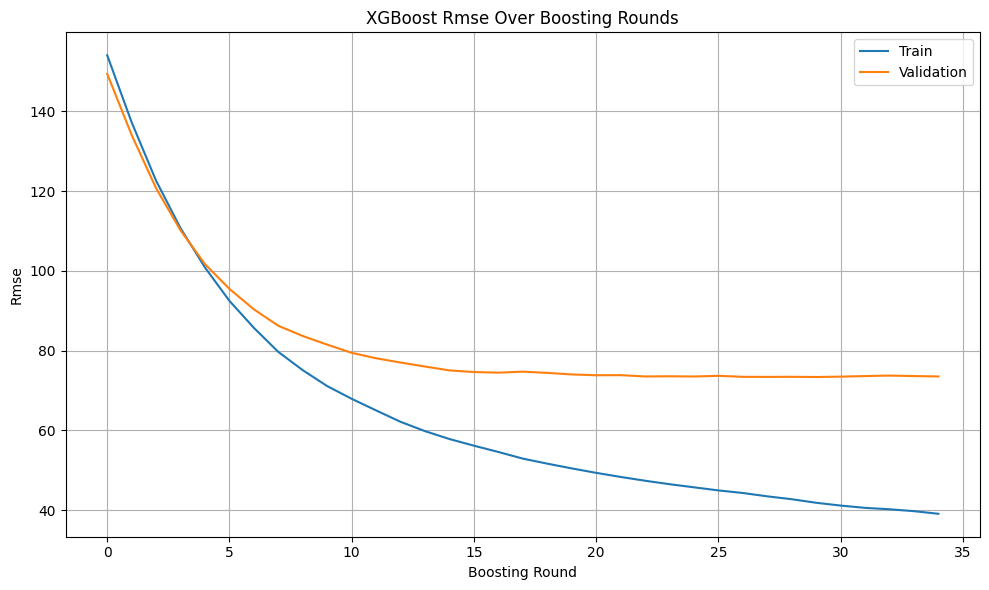

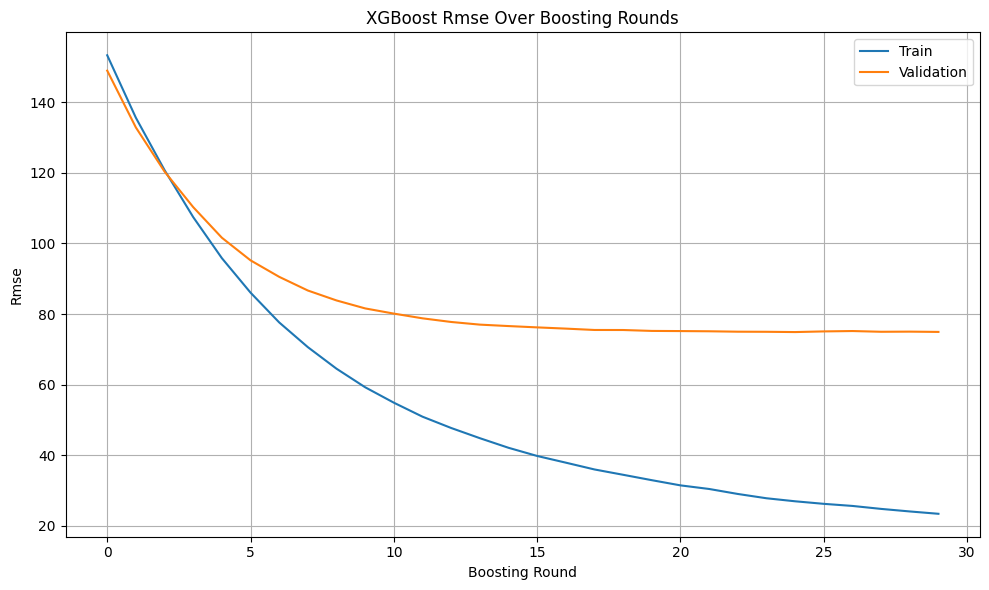

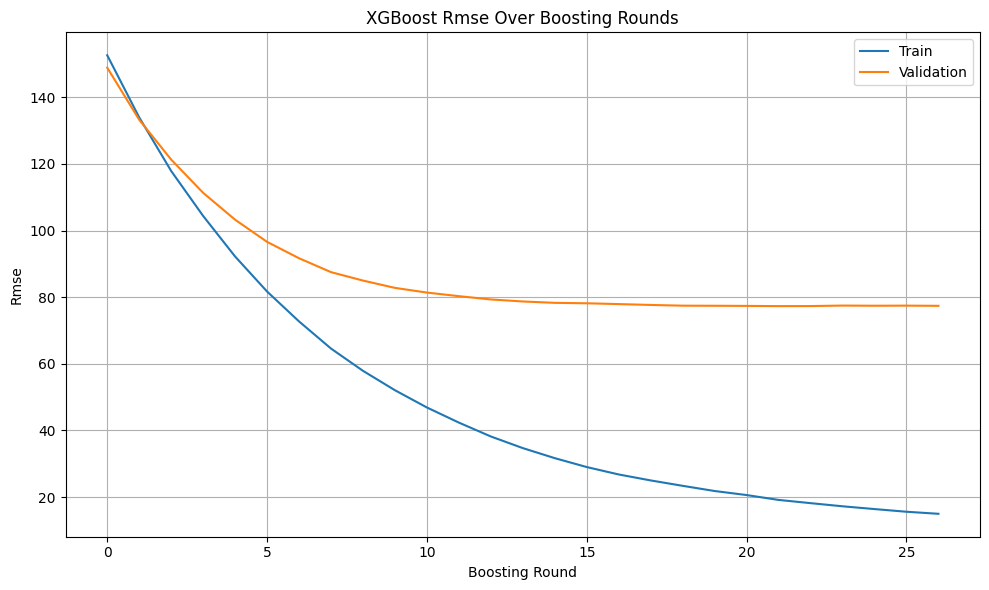

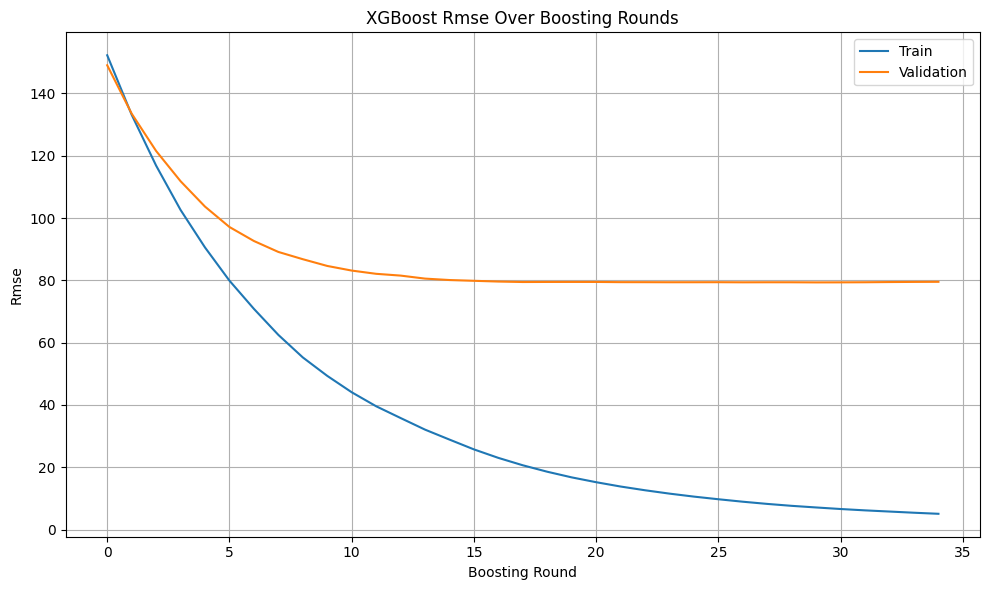

In [11]:
#ablation study for xgboost Gaussian errors, with gaussian source domain errors
ablation_transfer_real = pd.DataFrame(columns = ['seed', 'rmse',
                                   'mae', 'target_tree_size', 'v', 'epochs', 'method'])

seed_list = [1,2,3,4,5]
epoch_list = [1000]
v_list = [0.02, 0.03, 0.05, 0.1, 0.15]
target_tree_size_list = [1,2,3,4,5]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    epoch_list,
    v_list,
    target_tree_size_list))

# --- Step 3: Sample random combinations ---
#sampled_configs = random.sample(param_grid, n_samples)

for seed in seed_list:

    #data from Svedala
    data_sweden = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Image_data\merged_data_cleaned.csv',
                                index_col=[0])

    #rename 'Hgv' to 'H_AVERAGE'
    #data_sweden = data_sweden.rename(columns={RESPONSE: "D_AVERAGE"})

    #for training and testing on Sweden only
    data_train_sweden_1 = data_sweden[data_sweden['area_code'] == 4]
    data_train_sweden_2 = data_sweden[data_sweden['area_code'] == 2]
    data_train_sweden_3 = data_sweden[data_sweden['area_code'] == 3]
    data_train_sweden_4 = data_sweden[data_sweden['area_code'] == 1]

    #data_train_sweden_234 = data_train_sweden_4
    data_train_sweden_234 = pd.concat(
        [data_train_sweden_2, data_train_sweden_3])
    data_train_sweden_234 = pd.concat(
        [data_train_sweden_234, data_train_sweden_4])
    data_train_sweden, data_test_sweden_1 = train_test_split(
        data_train_sweden_1, test_size=test_size,
        random_state=seed)  #random_state is fixed

    data_train_sweden_1, data_test = train_test_split(
        data_train_sweden,
        test_size=1 - train_size,
        random_state=seed
    )



    if use_latvia == True:

        #evaluate and rain on latvia instead (keep naming for simplicity)
        data_latvia = pd.read_csv(r'C:\Users\Dag Bjornberg\AI\forestmap\Latvian_Image_data\merged_data_cleaned.csv')
        data_latvia = data_latvia.rename(columns = {'H_AVERAGE': 'Hgv', 'D_AVERAGE': 'Dgv', 'VOLUME': 'Volume'})
        data_train_sweden, data_test_sweden_1 = train_test_split(
            data_latvia, test_size=test_size,
            random_state=seed)  #random_state is fixed

        data_train_sweden_1, data_test = train_test_split(
            data_train_sweden,
            test_size=1 - train_size,
            random_state=seed
        )  #random state is not fixed, data_test unused

    #"General" base dataset (to use for transfer)
    X_source_train = np.array(data_train_sweden_234[predictor_columns])
    y_source_train = np.array(data_train_sweden_234[target_column])

    #Specific train and test set
    X_target_train = np.array(data_train_sweden_1[predictor_columns])
    y_target_train = np.array(data_train_sweden_1[target_column])

    X_target_test = np.array(data_test_sweden_1[predictor_columns])
    y_target_test = np.array(data_test_sweden_1[target_column])

    X_target_val, X_target_test = train_test_split(X_target_test, test_size = 0.5, random_state = seed)
    y_target_val, y_target_test = train_test_split(y_target_test, test_size = 0.5, random_state = seed)
    print(len(X_target_train), len(X_target_val), len(X_target_test))
    for config in param_grid:
        epochs, v, target_tree_size = config



        #We also append baseline results!!
        method = 'Baseline (XGBoost)'
        params = {
            'objective': 'reg:squarederror',  # Regression with squared error
            'max_depth': target_tree_size,                   # Maximum depth of a tree
            'eta': v,                       # Learning rate
            'eval_metric': 'rmse',           # RMSE as evaluation metric
            }
                
        bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=epochs, params=params)
        preds = test_xgboost(X_target_test, bst)
        rmse = compute_rmse(preds, y_target_test)
        mae = compute_mae(preds, y_target_test)
        ablation_transfer_real.loc[len(ablation_transfer_real)] = [seed, rmse,
                            mae, target_tree_size, v, epochs, method]
        
        ablation_transfer_real.to_csv(f'ablation_transfer_real_xgboost.csv')

In [ ]:
# Import Joblib
import joblib

# Save the model to a file
joblib.dump(fiter, 'model.joblib')

['model.joblib']

In [ ]:
fiter = joblib.load('model.joblib')
rmse = fiter.evaluate(x_test, y_test, metric = 'rmse')
print(rmse)

73.80578151458285


In [ ]:
fiter = LSTransferTreeBoost(epochs = 200, v = 0.03, source_tree_size=1, target_tree_size = 3, decay_factor = 0.05, alpha_0 = 1.0)
fiter.fit(a_train, b_train, ahat_train, bhat_train, show_curves=True, val_x = x_val, val_y = y_val, early_stopping_rounds=7)
rmse = fiter.evaluate(x_test, y_test, metric = 'rmse')
print(rmse)
                    

TypeError: LSTransferTreeBoost.__init__() got an unexpected keyword argument 'decay_factor'

In [ ]:
# Save the model to a file
joblib.dump(fiter, 'model.joblib')

['model.joblib']

In [ ]:
fiter = joblib.load('model.joblib')
rmse = fiter.evaluate(x_test, y_test, metric = 'rmse')
print(rmse)

2.655530643645401


In [ ]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
}

In [ ]:
def train_xgboost(data_train, labels_train, boosting_rounds):

    dtrain = xgb.DMatrix(data_train, label=labels_train)

    # Train with evaluation set and early stopping
    evallist = [(dtrain, 'train')]

    bst = xgb.train(params, dtrain, num_boost_round=boosting_rounds, evals=evallist)

    return bst

def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

In [ ]:
bst = train_xgboost(a_train, b_train, boosting_rounds=200)
preds = test_xgboost(x_test, bst)
rmse = compute_rmse(preds, y_test)
print(rmse)

[0]	train-rmse:8.43254
[1]	train-rmse:7.72221
[2]	train-rmse:7.09041
[3]	train-rmse:6.52496
[4]	train-rmse:6.01390
[5]	train-rmse:5.55542
[6]	train-rmse:5.14147
[7]	train-rmse:4.77317
[8]	train-rmse:4.43754
[9]	train-rmse:4.14210
[10]	train-rmse:3.87510
[11]	train-rmse:3.63637
[12]	train-rmse:3.42178
[13]	train-rmse:3.22943
[14]	train-rmse:3.05897
[15]	train-rmse:2.90995
[16]	train-rmse:2.77752
[17]	train-rmse:2.65497
[18]	train-rmse:2.55073
[19]	train-rmse:2.45362
[20]	train-rmse:2.36927
[21]	train-rmse:2.28992
[22]	train-rmse:2.21691
[23]	train-rmse:2.15271
[24]	train-rmse:2.09677
[25]	train-rmse:2.04106
[26]	train-rmse:1.99307
[27]	train-rmse:1.94969
[28]	train-rmse:1.91133
[29]	train-rmse:1.87102
[30]	train-rmse:1.83419
[31]	train-rmse:1.80010
[32]	train-rmse:1.77173
[33]	train-rmse:1.73602
[34]	train-rmse:1.70432
[35]	train-rmse:1.68054
[36]	train-rmse:1.65106
[37]	train-rmse:1.63074
[38]	train-rmse:1.60434
[39]	train-rmse:1.57559
[40]	train-rmse:1.55145
[41]	train-rmse:1.53082
[4